## **IMPORTS**

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
import os
from dotenv import load_dotenv

import src.experiments.config as cfg_module
import src.experiments.simulation as sim_module
import src.experiments.simulation_greedy as sim_greedy
from src.experiments.run import define_agents
from src.metrics.plots_metrics import *
from src.metrics.plots_metrics_comparison import *
from src.metrics.other_metrics import *

pygame 2.6.1 (SDL 2.28.4, Python 3.12.0)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
load_dotenv()

ROOT_PATH = os.getenv("ROOT_PATH")
OUTPUT_DIR = 'outputs'
OUTPUT_PATH = f'{ROOT_PATH}/{OUTPUT_DIR}'
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f'--> outputs logs in: {OUTPUT_PATH}')

--> outputs logs in: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs


## **UTILS**

### **CONFIG**

In [4]:
# --- CONFIG FUNCTION

def notebook_config(
    total_time=None,
    nb_car=None,
    nb_society=None,
    nb_station=None,
    base_car_behavior=None,
    station_strategy_noise=None,
    log_iter=None
):
    """
    Crée et configure un objet SimulationConfig
    pour les notebooks/tests.
    """

    config = cfg_module.SimulationConfig()

    # ------------------------------------------------ VISUALISATION
    config.set_VISUALIZE(False)

    # ------------------------------------------------ TEMPS
    if total_time is not None:
        config.set_TOTAL_TIME(total_time)

    if log_iter is not None:
        config.set_log_iter(log_iter)

    # ------------------------------------------------ AGENTS
    if nb_car is not None:

        if type(nb_car) is not int:
            raise TypeError(
                f"nb_car doit être un int, reçu : {type(nb_car).__name__}"
            )

        if nb_car <= 0:
            raise ValueError("nb_car doit être > 0")

        config.NB_CARS = nb_car

    if nb_society is not None:

        if type(nb_society) is not int:
            raise TypeError(
                f"nb_society doit être un int, reçu : {type(nb_society).__name__}"
            )

        if nb_society <= 0:
            raise ValueError("nb_society doit être > 0")

        config.NB_SOCIETIES = nb_society

    if nb_station is not None:

        if type(nb_station) is not int:
            raise TypeError(
                f"nb_station doit être un int, reçu : {type(nb_station).__name__}"
            )

        if nb_station <= 0:
            raise ValueError("nb_station doit être > 0")

        config.NB_STATIONS = nb_station

    # ------------------------------------------------ COMPORTEMENTS VOITURES
    if base_car_behavior is not None:

        required_keys = {
            'pres',
            'abs',
            'early',
            'late',
            'noise'
        }

        missing = required_keys - set(base_car_behavior.keys())

        if missing:
            raise ValueError(
                f"Clés manquantes dans base_car_behavior : {missing}"
            )

        total_prob = (
            base_car_behavior['pres']
            + base_car_behavior['abs']
            + base_car_behavior['early']
            + base_car_behavior['late']
        )

        if total_prob != 100:
            raise ValueError(
                f"La somme des probabilités doit valoir 100, reçu : {total_prob}"
            )

        config.BASE_CANCEL_PROB = base_car_behavior.copy()

    # ------------------------------------------------ BRUIT STRATÉGIE STATION
    if station_strategy_noise is not None:

        if not isinstance(station_strategy_noise, (int, float)):
            raise TypeError(
                "station_strategy_noise doit être numérique"
            )

        if station_strategy_noise < 0:
            raise ValueError(
                "station_strategy_noise doit être >= 0"
            )

        config.STRATEGY_NOISE = float(station_strategy_noise)

    return config

In [5]:
# --- EXAMPLE

total_time = 12 * 24 * 1  # une journée
log_iter = 12

nb_car = 50
nb_society = 4
nb_station = 40

strategy_noise = 0.5  # variation proportionnelle ±50%

base_car_behavior = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

c = notebook_config(total_time=total_time, nb_car=nb_car, nb_society=nb_society,
                nb_station=nb_station, base_car_behavior=base_car_behavior,
                station_strategy_noise=strategy_noise, log_iter=log_iter)

slot_h = c.SLOT_DURATION / 60
dist_slot = c.CAR_SPEED          # m/slot
autonomy_mean = c.CAR_AUTONOMY_PARAMS_KM['mean']
conso = c.ENERGY_CONSUMPTION['quantity_kW'] / c.ENERGY_CONSUMPTION['distance_unit_m']
delta_soc = dist_slot * conso / (c.ENERGY_CONSUMPTION['quantity_kW'] * autonomy_mean / 100)

print(f"Grille            : {c.C_GRID/1e3:.1f} km × {c.C_GRID/1e3:.1f} km")
print(f"Vitesse           : {c.CAR_SPEED} m/slot  ({c.CAR_SPEED/1000/slot_h:.0f} km/h)")
print(f"ΔSoC / slot       : {delta_soc:.5f}  ({1/delta_soc:.0f} slots pour vider)")
print(f"Autonomie moy.    : {autonomy_mean} km")
print(f"Distance max grille traversée avec soc=0.10 : {0.10*autonomy_mean:.0f} km >> {c.C_GRID/1e3:.1f} km ✓")


Grille            : 3.0 km × 3.0 km
Vitesse           : 4167.0 m/slot  (50 km/h)
ΔSoC / slot       : 0.01042  (96 slots pour vider)
Autonomie moy.    : 400 km
Distance max grille traversée avec soc=0.10 : 40 km >> 3.0 km ✓


### **CHARTS**

#### *Demand Satisfaction*

In [6]:
def plot_exact_needs_comparison(exact_values, needs_values, labels, colors,
                                scenario_name, nb_car):

    # Création des graphiques côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Graphique Exact --------
    bars1 = axes[0].bar(labels, exact_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Exact Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[0].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Graphique Needs --------
    bars2 = axes[1].bar(labels, needs_values, color=colors, alpha=0.7)
    

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Needs Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[1].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Travel & Waiting*

In [7]:
def plot_travel_waiting_comparison(travel_values, waiting_values, labels, colors,
                                scenario_name, nb_car):

    # Création des subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Travel Distance --------
    bars1 = axes[0].bar(labels, travel_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Travel Distance (km)', fontweight='bold')
    axes[0].set_ylabel('Distance (km)')
    axes[0].set_ylim(top = 1.15 * max(travel_values))

    # Valeurs sur les barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Waiting Time --------
    bars2 = axes[1].bar(labels, waiting_values, color=colors, alpha=0.7)

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Waiting Time (min)', fontweight='bold')
    axes[1].set_ylabel('Time (min)')
    if max(waiting_values) > 0.:
        axes[1].set_ylim(top = 1.15 * max(waiting_values))
    else:
        axes[1].set_ylim(bottom = 0. ,top = 5.)

    # Valeurs sur les barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Scalability*

In [8]:
def plot_mean_response_time_comparison(labels, colors, values, scenario_name, nb_car):

    fig, ax = plt.subplots(figsize=(6, 5))

    bars = ax.bar(labels, values, color=colors, alpha=0.8)

    scenario_tag = f"[{scenario_name[:3].upper()}@{nb_car}]"

    ax.set_title(
        f'{scenario_tag} Mean Response Time (ms)',
        fontweight='bold'
    )

    ax.set_ylabel('Response Time (ms)')

    if max(values) > 0:
        ax.set_ylim(0, 1.15 * max(values))

    # Affichage des valeurs
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01 * max(values),
            f'{height:.2f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

## **EXPERIMENTS**

### **GLOBAL CONFIG**

In [9]:
SCENARIO = 'optimistic'

BASE_CAR_BEHAVIOR = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

In [10]:
OUTPUT_FOLDER_PATH = f'{OUTPUT_PATH}/{SCENARIO}'
os.makedirs(OUTPUT_FOLDER_PATH, exist_ok=True)

print(f'Scenario outputs folders in folder: {OUTPUT_FOLDER_PATH}')

Scenario outputs folders in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic


In [11]:
TOTAL_TIME = 12 * 24 * 5  # 5 jours
LOG_ITER = 12             # 12 -> toutes les heures

NB_SOCIETY = 4
NB_STATION = 40

STRATEGY_NOISE = 0.5  # variation proportionnelle ±50%

In [12]:
nb_car_list = []

exact_satif_greedy_list, exact_satif_bramev_list = [], []
needs_satif_greedy_list, needs_satif_bramev_list = [], []
mean_travel_greedy_list, mean_travel_bramev_list = [], []
mean_waiting_greedy_list, mean_waiting_bramev_list = [], []
mean_response_greedy_list, mean_response_bramev_list = [], []

### **EVChargingManagement@50cars**

#### **CONFIG**

In [13]:
nb_car = 50
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [ ]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/50cars


##### *Initialisation*

In [15]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [16]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:22:25.747 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-13 23:22:25.785 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-13 23:22:25.880 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-13 23:22:25.944 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-13 23:22:26.018 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-13 23:22:26.073 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-13 23:22:26.131 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-13 23:22:26.216 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-13 23:22:26.331 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-13 23:22:26.395 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-13 23:22:26.435 | IN

##### *Metrics*

In [17]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 9.44 kWh
  Station 1: 1.50 kWh
  Station 2: 2.15 kWh
  Station 3: 2.88 kWh
  Station 4: 9.94 kWh
  Station 5: 63.42 kWh
  Station 6: 3.78 kWh
  Station 7: 17.57 kWh
  Station 8: 3.52 kWh
  Station 9: 11.81 kWh
  Station 10: 0.00 kWh
  Station 11: 99.25 kWh
  Station 12: 23.90 kWh
  Station 13: 0.00 kWh
  Station 14: 10.26 kWh
  Station 15: 6.42 kWh
  Station 16: 0.00 kWh
  Station 17: 0.00 kWh
  Station 18: 86.48 kWh
  Station 19: 0.00 kWh
  Station 20: 3.47 kWh
  Station 21: 16.72 kWh
  Station 22: 2.10 kWh
  Station 23: 22.52 kWh
  Station 24: 2.82 kWh
  Station 25: 4.80 kWh
  Station 26: 0.00 kWh
  Station 27: 5.37 kWh
  Station 28: 0.00 kWh
  Station 29: 1.95 kWh
  Station 30: 0.00 kWh
  Station 31: 0.00 kWh
  Station 32: 2.25 kWh
  Station 33: 7.23 kWh
  Station 34: 11.13 kWh
  Station 35: 1.46 kWh
  Station 36: 5.91 kWh
  Station 37: 1.52 kWh
  Station 38: 40.82 kWh
  Station 39: 76.33 kWh

--- User Reque

In [18]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

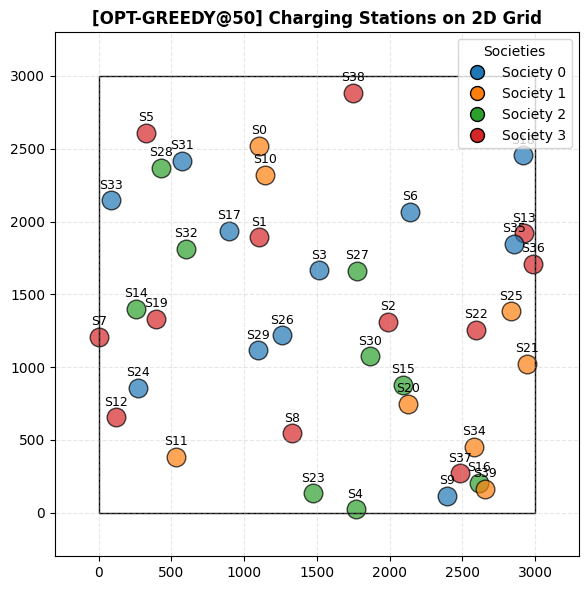

In [19]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=300)

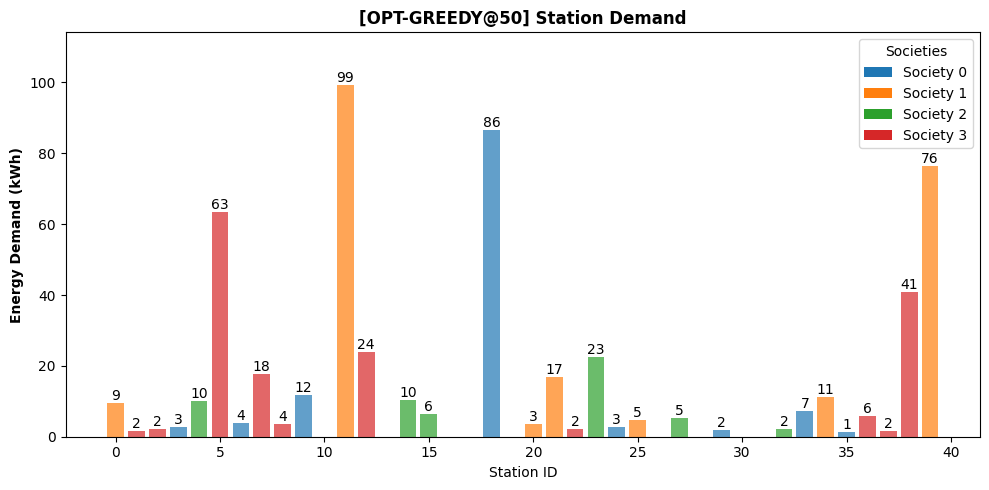

In [20]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

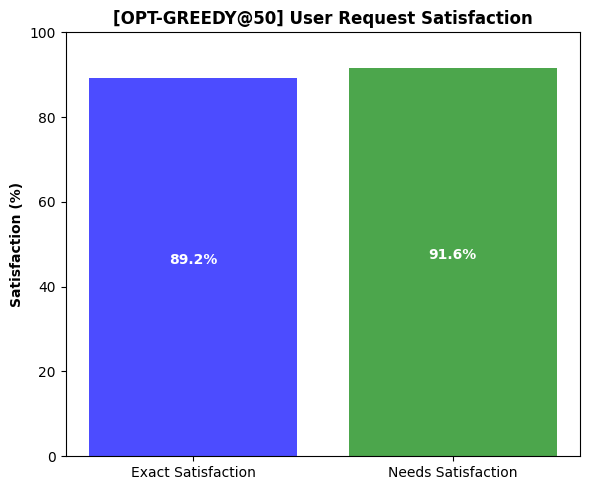

In [21]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

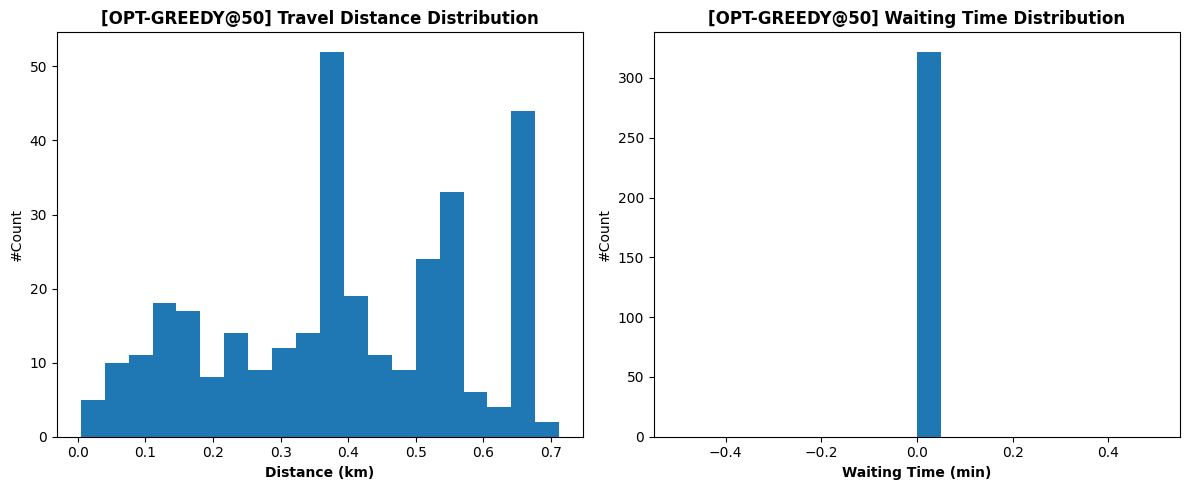

In [22]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

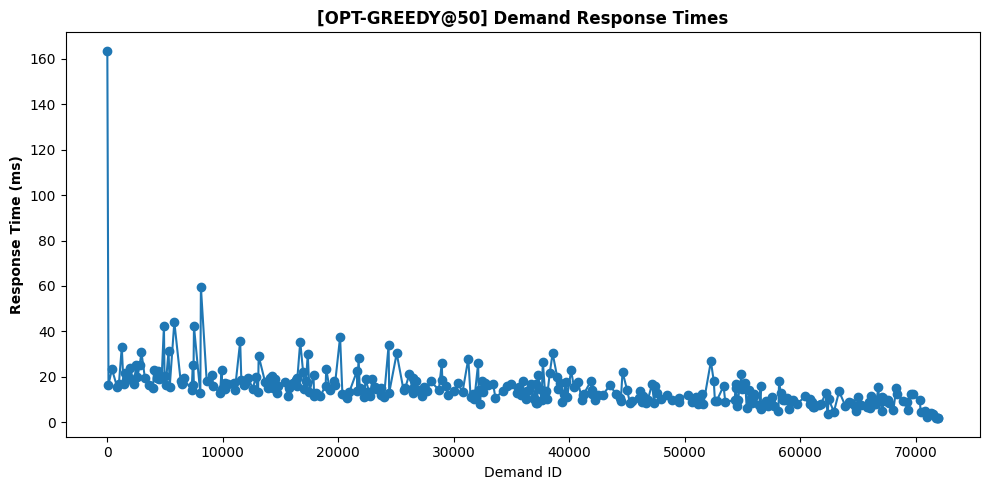

In [23]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

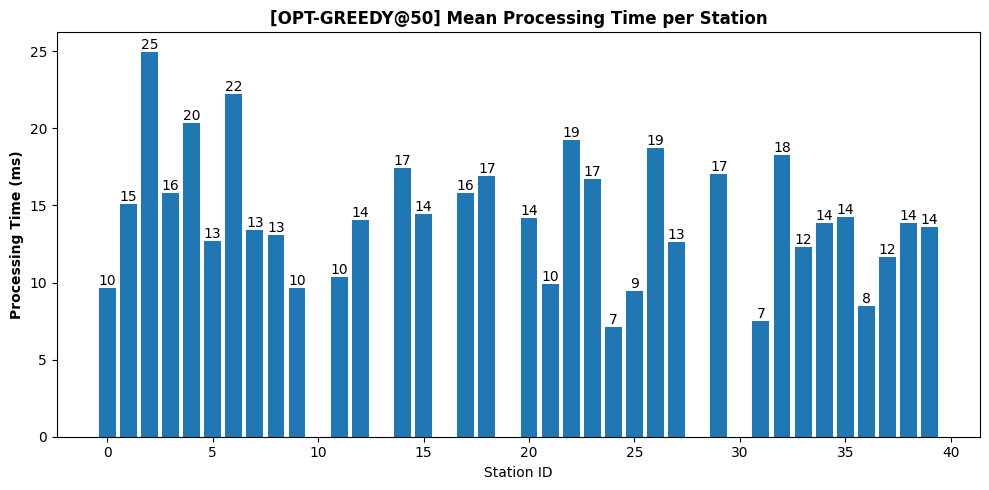

In [24]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [25]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           3  0.032639  0.000000  0.000000  0.000000  0.000000   
1            0           6  0.056944  0.000000  0.000000  0.000000  0.000000   
2            0           9  0.132639  0.018056  0.000000  0.000000       NaN   
3            0          17  0.000000  0.000000  0.000000  0.000000       NaN   
4            0          18  0.453472  0.425694  0.068056  0.040972  0.098611   
5            0          24  0.036806  0.000000  0.000000  0.000000       NaN   
6            0          26  0.000000  0.000000  0.000000  0.000000  0.000000   
7            0          29  0.027083  0.000000  0.000000  0.000000  0.000000   
8            0          31  0.000000  0.000000  0.000000  0.000000  0.000000   
9            0          33  0.061111  0.014583  0.000000  0.000000  0.000000   
10           0          35  0.017361  0.000000  0.000000  0.000000  0.000000   
11           1           0  0.121528  0.

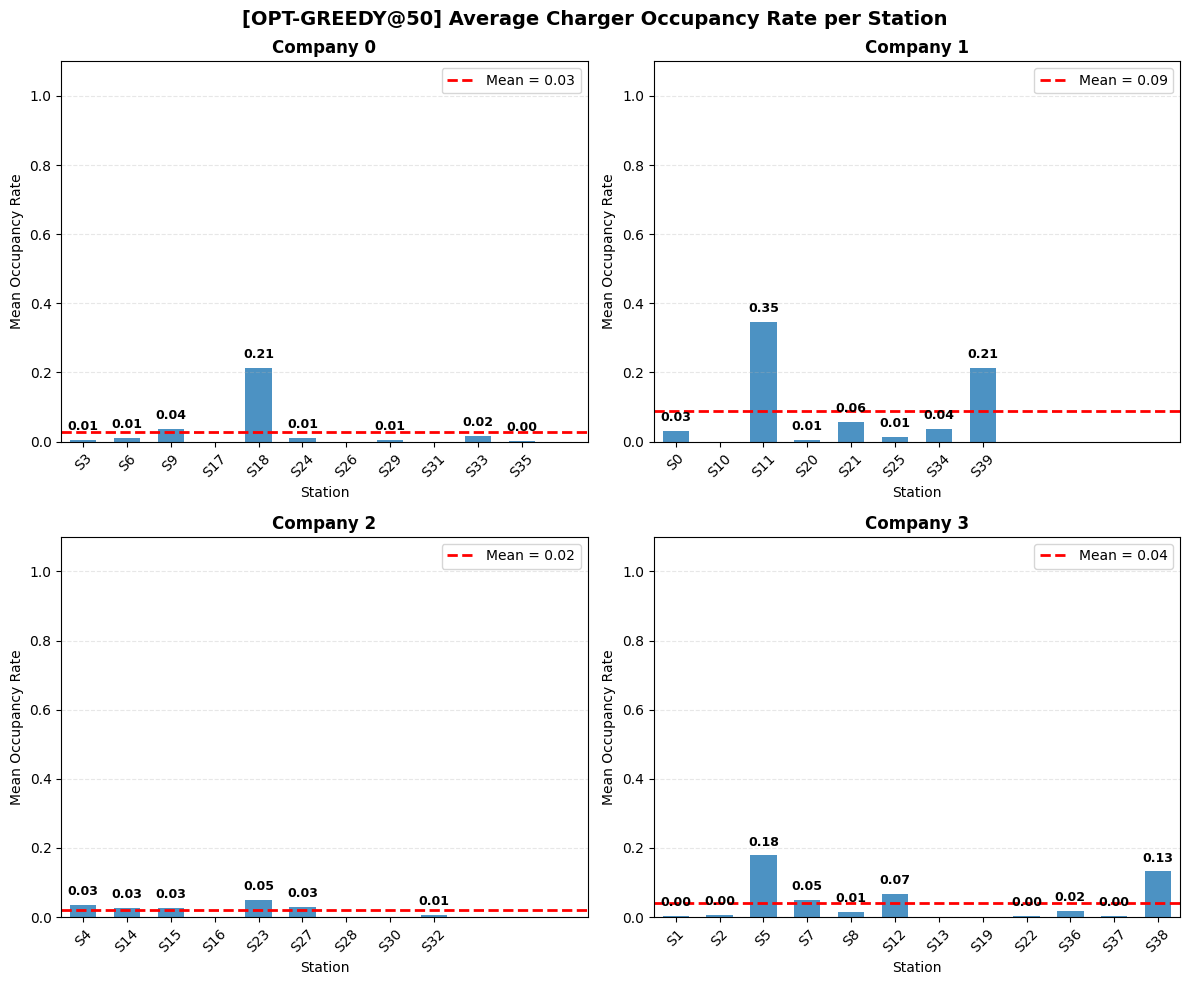

In [26]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

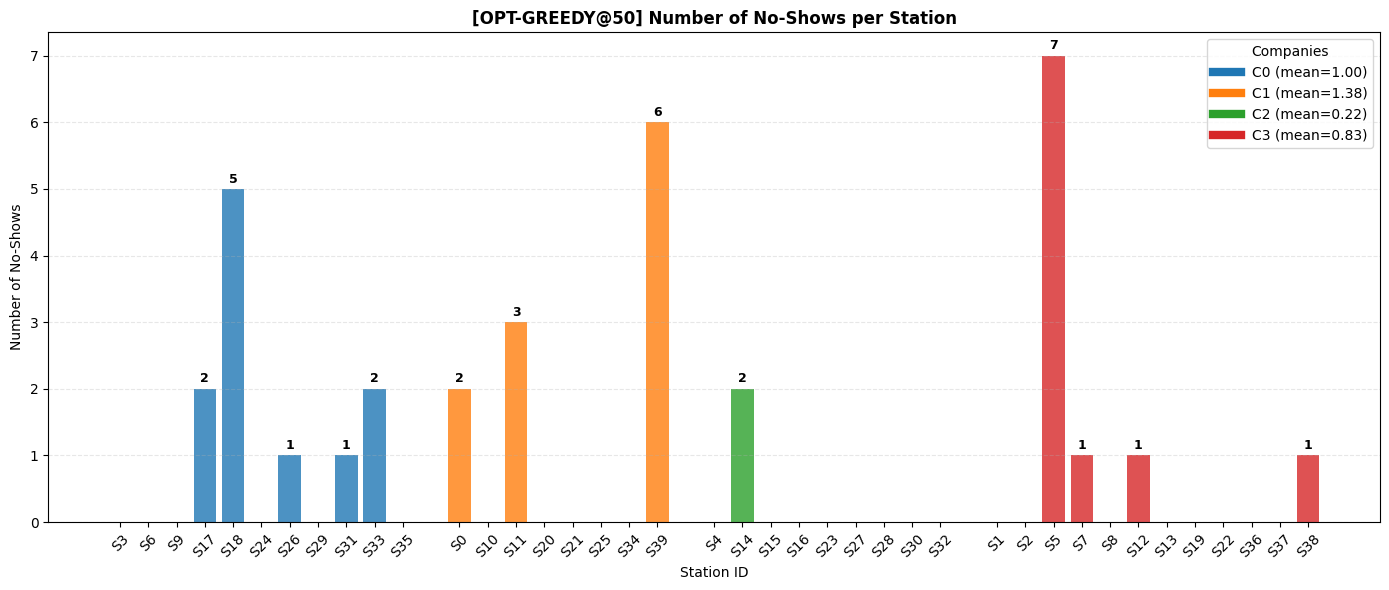

In [27]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [28]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,3,2,2,0,0,0,1.000000,0.000000,0.0,0.0
1,0,6,2,2,0,0,0,1.000000,0.000000,0.0,0.0
2,0,9,7,7,0,0,0,1.000000,0.000000,0.0,0.0
3,0,17,2,0,2,0,0,0.000000,1.000000,0.0,0.0
4,0,18,52,47,5,0,0,0.903846,0.096154,0.0,0.0
5,0,24,2,2,0,0,0,1.000000,0.000000,0.0,0.0
6,0,26,1,0,1,0,0,0.000000,1.000000,0.0,0.0
7,0,29,1,1,0,0,0,1.000000,0.000000,0.0,0.0
8,0,31,1,0,1,0,0,0.000000,1.000000,0.0,0.0
9,0,33,7,4,2,0,0,0.571429,0.285714,0.0,0.0


#### **BRAM-EV**

##### *Params*

In [29]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [30]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [31]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:22:32.368 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 23:22:33.316 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 23:22:33.375 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 23:22:33.438 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 23:22:33.644 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 23:22:34.364 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 23:22:34.416 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 23:22:34.788 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 23:22:34.943 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 23:22:35.332 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 23:22:35.417 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [32]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 15.74 kWh
  Station 1: 0.00 kWh
  Station 2: 1.45 kWh
  Station 3: 75.56 kWh
  Station 4: 5.87 kWh
  Station 5: 0.00 kWh
  Station 6: 0.00 kWh
  Station 7: 2.33 kWh
  Station 8: 2.40 kWh
  Station 9: 2.25 kWh
  Station 10: 0.00 kWh
  Station 11: 0.00 kWh
  Station 12: 115.74 kWh
  Station 13: 67.19 kWh
  Station 14: 1.69 kWh
  Station 15: 2.07 kWh
  Station 16: 33.52 kWh
  Station 17: 1.93 kWh
  Station 18: 0.00 kWh
  Station 19: 0.00 kWh
  Station 20: 23.44 kWh
  Station 21: 0.00 kWh
  Station 22: 37.16 kWh
  Station 23: 8.49 kWh
  Station 24: 4.58 kWh
  Station 25: 13.92 kWh
  Station 26: 1.81 kWh
  Station 27: 0.00 kWh
  Station 28: 5.05 kWh
  Station 29: 0.00 kWh
  Station 30: 1.42 kWh
  Station 31: 1.71 kWh
  Station 32: 3.38 kWh
  Station 33: 15.68 kWh
  Station 34: 3.32 kWh
  Station 35: 16.89 kWh
  Station 36: 78.11 kWh
  Station 37: 2.17 kWh
  Station 38: 1.25 kWh
  Station 39: 11.69 kWh

--- User Requ

In [33]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

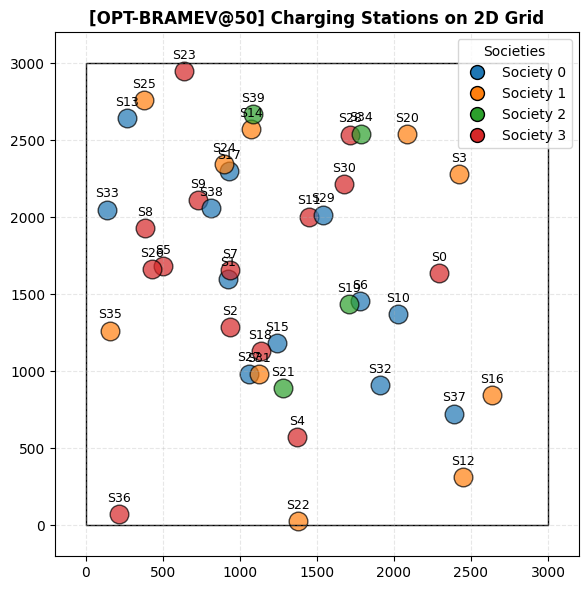

In [34]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

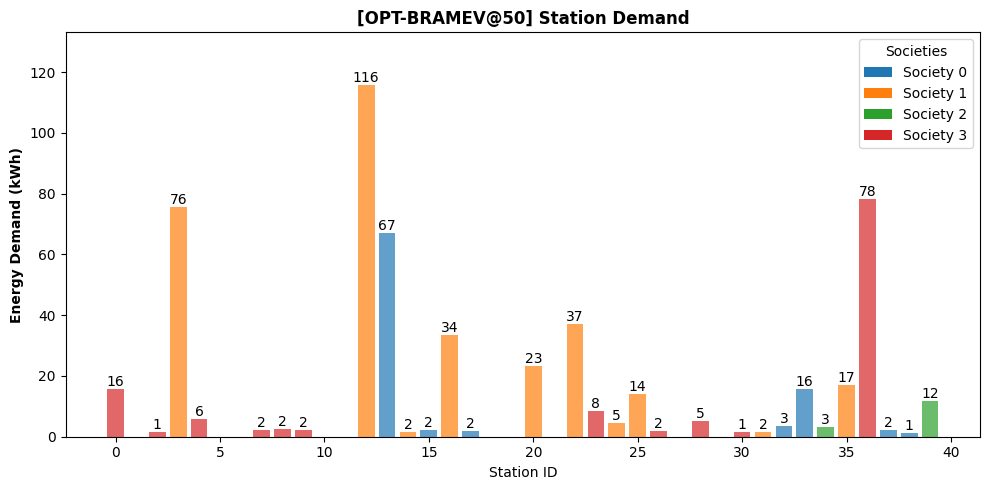

In [35]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

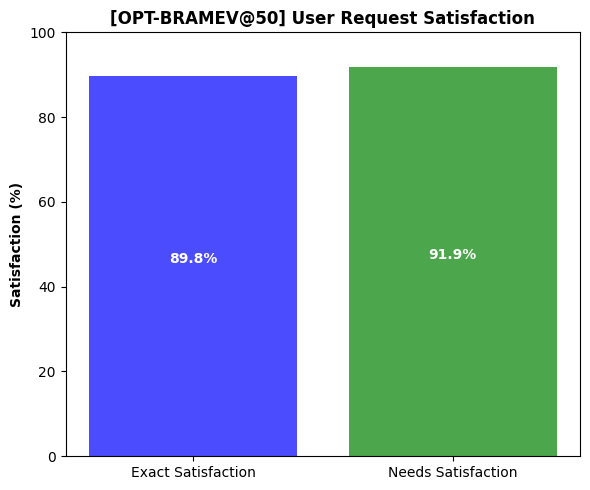

In [36]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

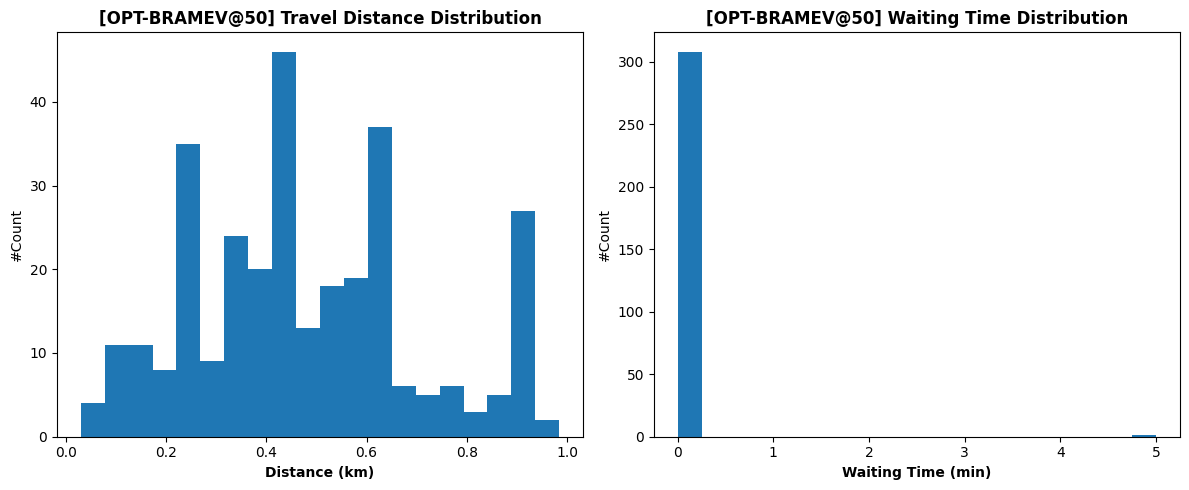

In [37]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

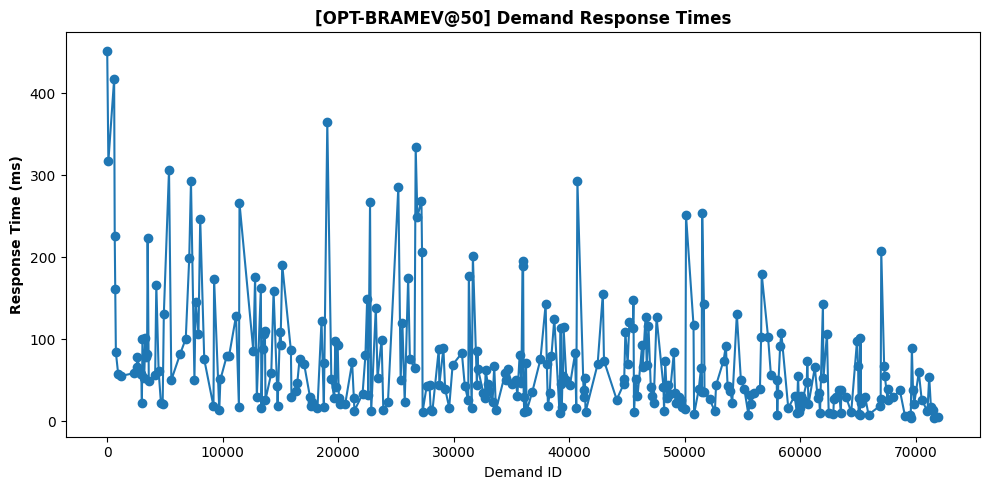

In [38]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

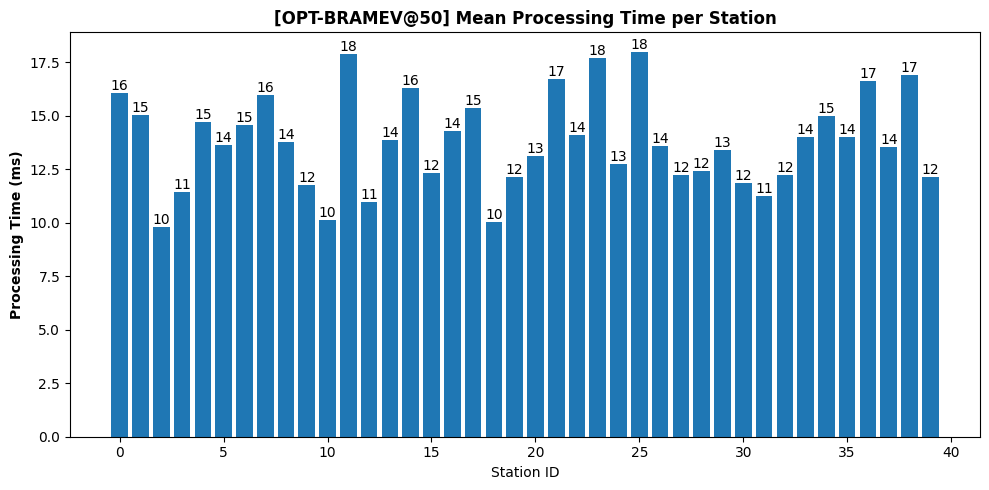

In [39]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

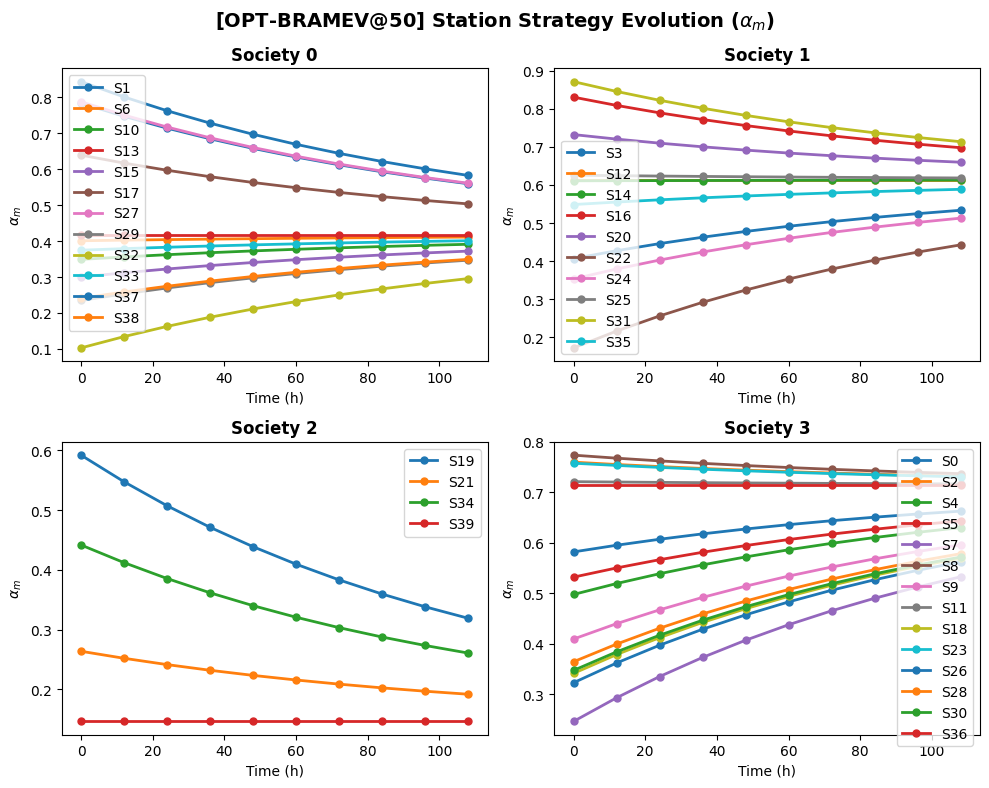

In [40]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [41]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.000000  0.000000  0.000000  0.000000  0.000000   
1            0           6  0.000000  0.000000  0.000000  0.000000  0.000000   
2            0          10  0.000000  0.000000  0.000000  0.000000       NaN   
3            0          13  0.500000  0.262500  0.127083  0.043750  0.068056   
4            0          15  0.021528  0.000000  0.000000  0.000000  0.000000   
5            0          17  0.022917  0.000000  0.000000  0.000000  0.000000   
6            0          27  0.000000  0.000000  0.000000  0.000000  0.000000   
7            0          29  0.000000  0.000000  0.000000  0.000000  0.000000   
8            0          32  0.052778  0.000000  0.000000  0.000000  0.000000   
9            0          33  0.199306  0.031944  0.000000  0.000000  0.000000   
10           0          37  0.036111  0.000000  0.000000  0.000000  0.000000   
11           0          38  0.020833  0.

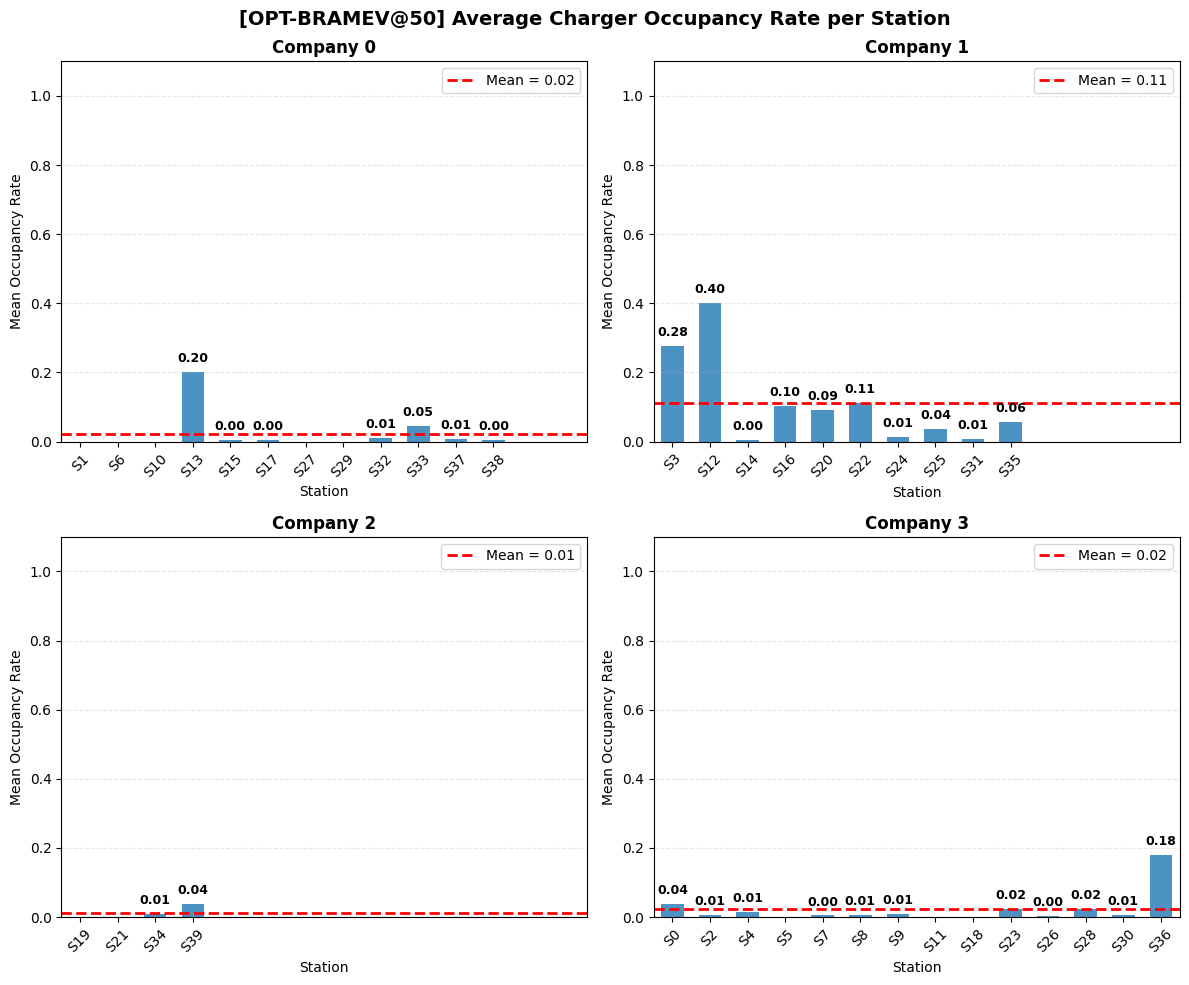

In [42]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

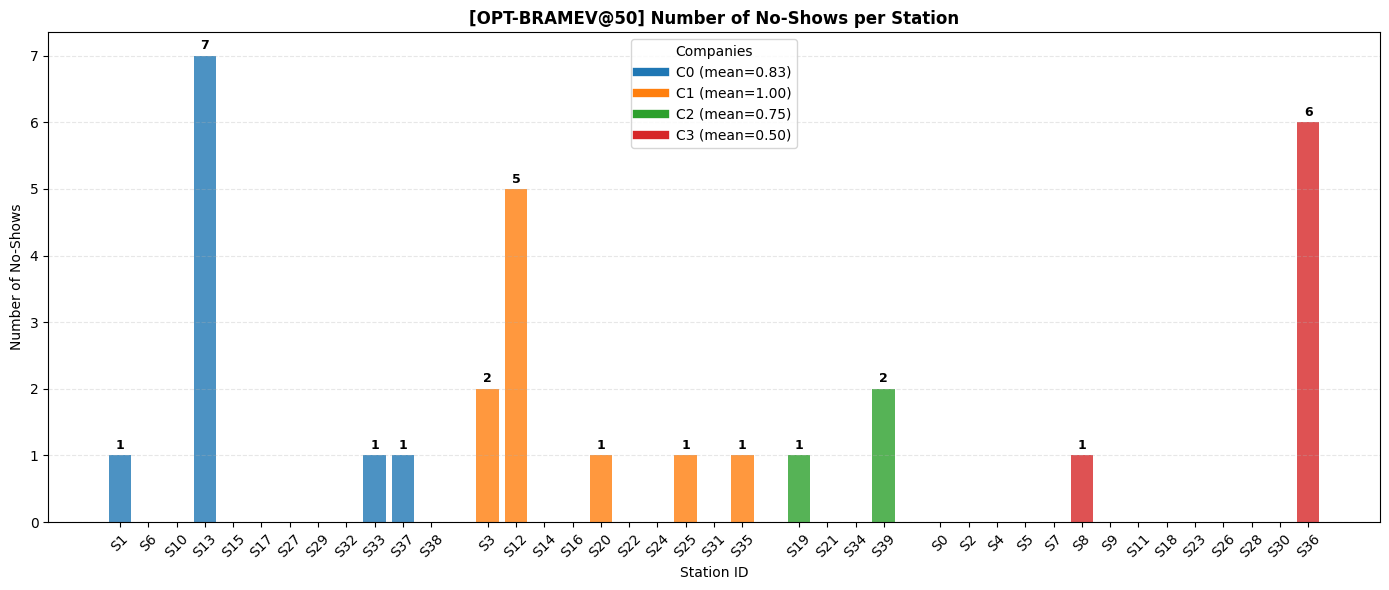

In [43]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [44]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,1,0,1,0,0,0.000000,1.000000,0.0,0.0
1,0,6,0,0,0,0,0,NaN,NaN,NaN,NaN
2,0,10,0,0,0,0,0,NaN,NaN,NaN,NaN
3,0,13,42,35,7,0,0,0.833333,0.166667,0.0,0.0
4,0,15,1,1,0,0,0,1.000000,0.000000,0.0,0.0
5,0,17,1,1,0,0,0,1.000000,0.000000,0.0,0.0
6,0,27,0,0,0,0,0,NaN,NaN,NaN,NaN
7,0,29,0,0,0,0,0,NaN,NaN,NaN,NaN
8,0,32,2,2,0,0,0,1.000000,0.000000,0.0,0.0
9,0,33,9,8,1,0,0,0.888889,0.111111,0.0,0.0


#### **COMPARISON**

##### *Params*

In [45]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

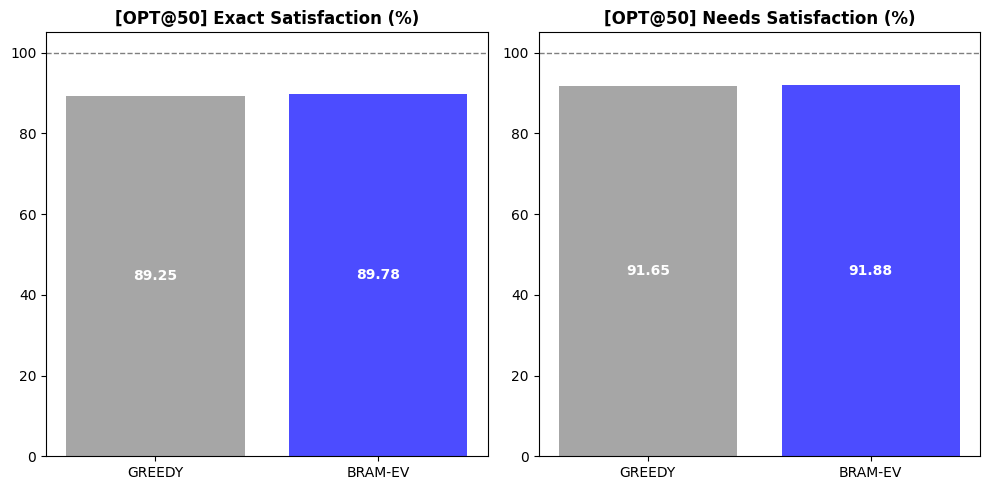

In [46]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

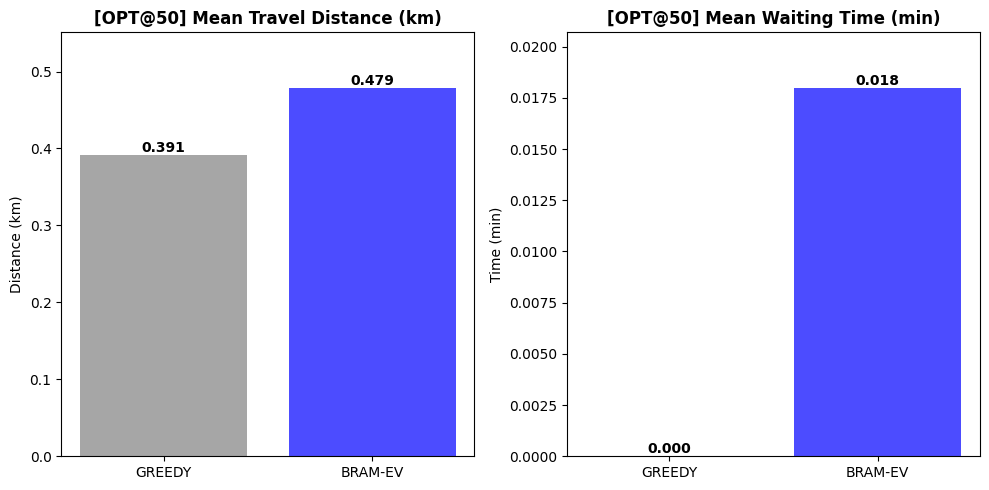

In [47]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

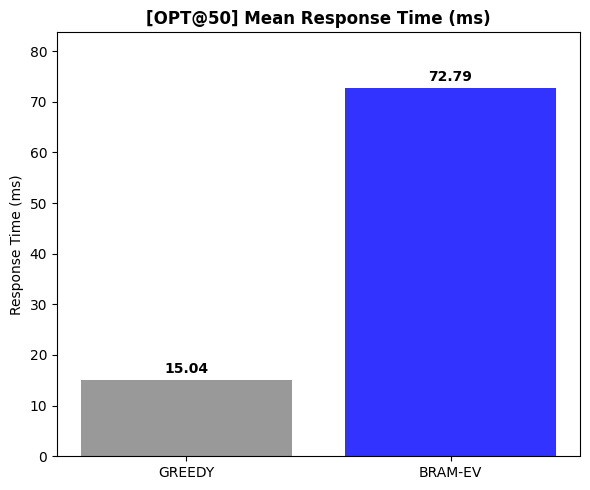

In [48]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@100cars**

#### **CONFIG**

In [49]:
nb_car = 100
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [ ]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/100cars


##### *Initialisation*

In [51]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [52]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:22:56.681 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-13 23:22:56.904 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-13 23:22:57.021 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-13 23:22:57.195 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-13 23:22:57.369 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-13 23:22:57.508 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-13 23:22:57.771 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-13 23:22:57.849 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-13 23:22:57.934 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-13 23:22:58.068 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-13 23:22:58.143 | IN

##### *Metrics*

In [53]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 11.26 kWh
  Station 1: 9.52 kWh
  Station 2: 11.90 kWh
  Station 3: 39.42 kWh
  Station 4: 0.00 kWh
  Station 5: 6.35 kWh
  Station 6: 3.54 kWh
  Station 7: 62.40 kWh
  Station 8: 24.14 kWh
  Station 9: 5.67 kWh
  Station 10: 0.00 kWh
  Station 11: 145.76 kWh
  Station 12: 8.27 kWh
  Station 13: 2.93 kWh
  Station 14: 161.12 kWh
  Station 15: 10.45 kWh
  Station 16: 4.87 kWh
  Station 17: 41.02 kWh
  Station 18: 7.82 kWh
  Station 19: 25.68 kWh
  Station 20: 15.78 kWh
  Station 21: 5.37 kWh
  Station 22: 29.63 kWh
  Station 23: 1.87 kWh
  Station 24: 8.01 kWh
  Station 25: 13.62 kWh
  Station 26: 53.83 kWh
  Station 27: 0.00 kWh
  Station 28: 18.59 kWh
  Station 29: 139.24 kWh
  Station 30: 1.57 kWh
  Station 31: 151.20 kWh
  Station 32: 11.98 kWh
  Station 33: 27.48 kWh
  Station 34: 1.88 kWh
  Station 35: 3.95 kWh
  Station 36: 39.32 kWh
  Station 37: 7.11 kWh
  Station 38: 1.93 kWh
  Station 39: 2.25 kWh

--

In [54]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

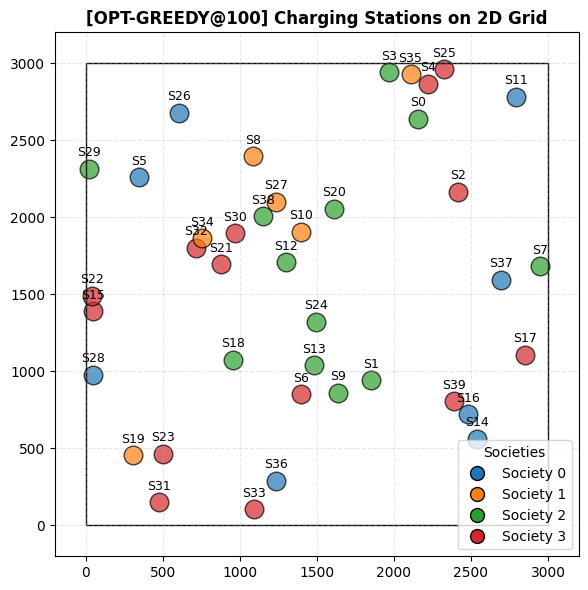

In [55]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

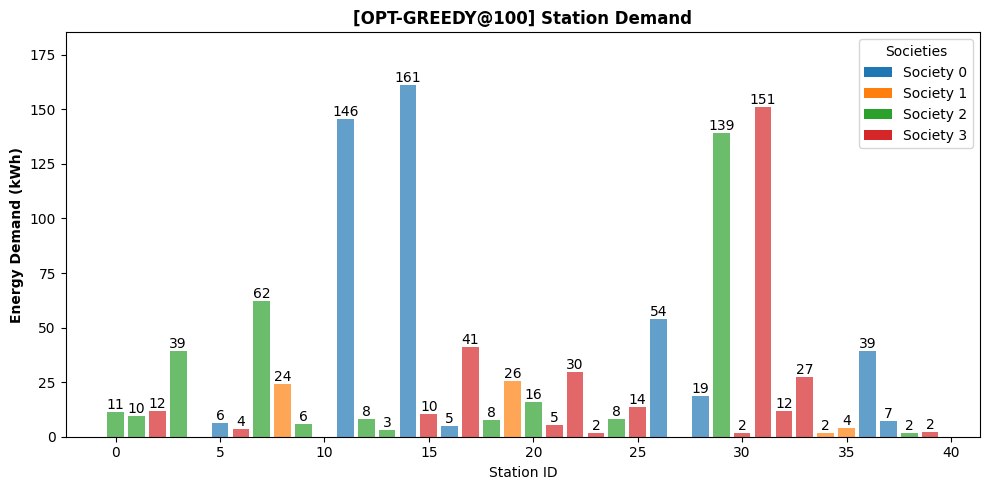

In [56]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

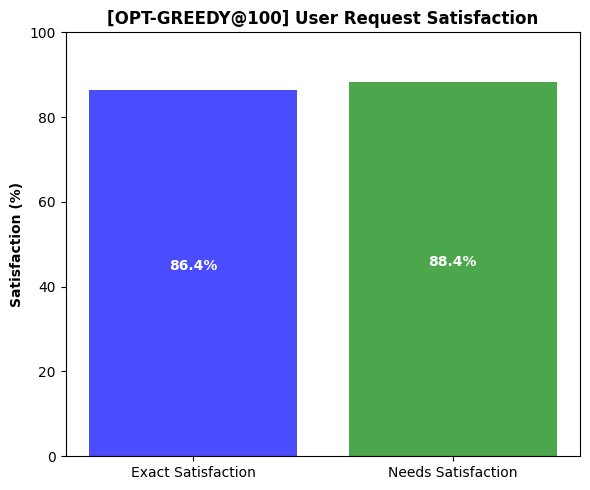

In [57]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

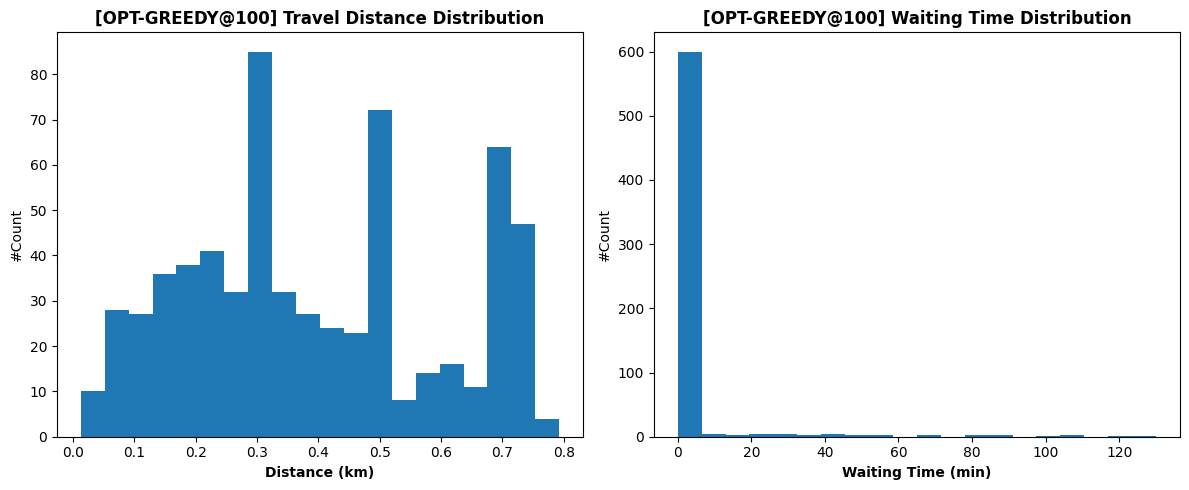

In [58]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

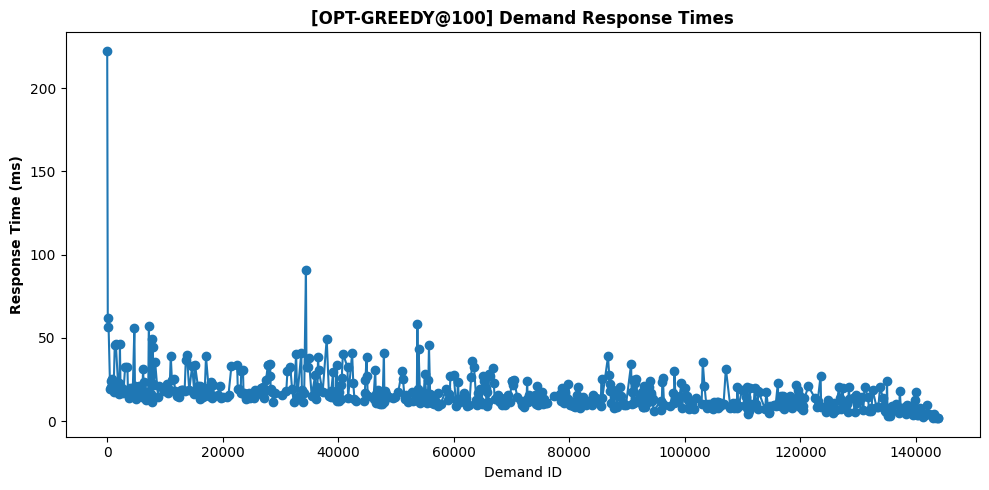

In [59]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

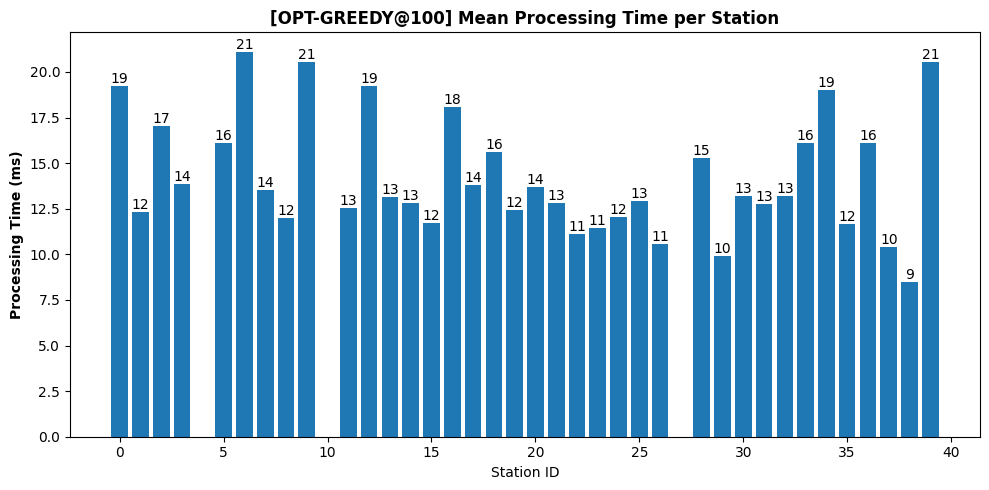

In [60]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [61]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           5  0.083333  0.000000  0.000000  0.000000  0.000000   
1            0          11  0.617361  0.623611  0.232639  0.228472  0.439583   
2            0          14  0.686111  0.617361  0.284028  0.316667  0.466667   
3            0          16  0.071528  0.000000  0.000000  0.000000  0.000000   
4            0          26  0.408333  0.248611  0.022917  0.076389       NaN   
5            0          28  0.231944  0.036111  0.000000  0.000000  0.000000   
6            0          36  0.335417  0.150694  0.000000  0.000000  0.000000   
7            0          37  0.091667  0.000000  0.000000  0.000000       NaN   
8            1           8  0.250694  0.121528  0.000000  0.000000       NaN   
9            1          10  0.000000  0.000000  0.000000  0.000000  0.000000   
10           1          19  0.268750  0.070139  0.021528  0.029167       NaN   
11           1          27  0.000000  0.

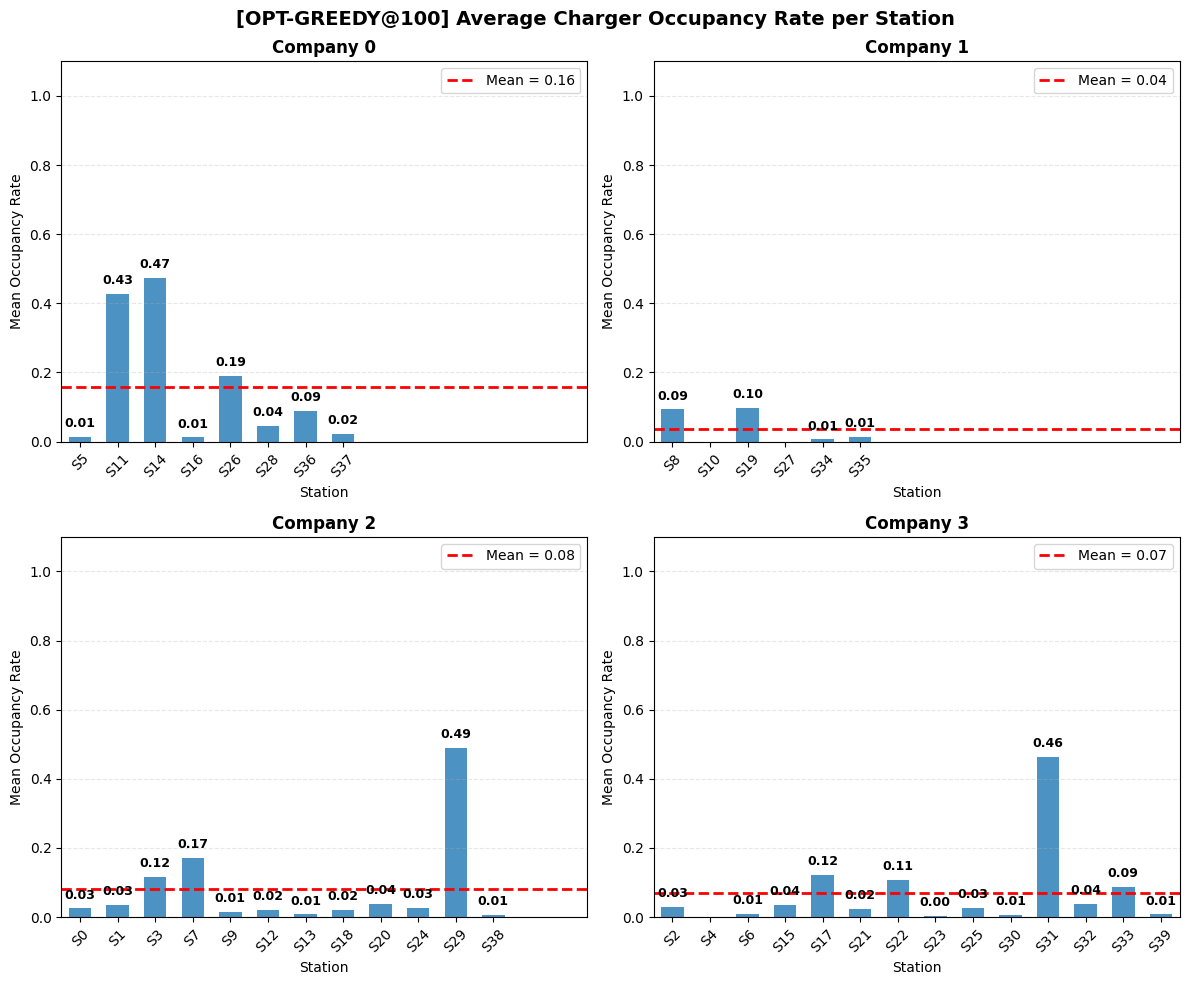

In [62]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

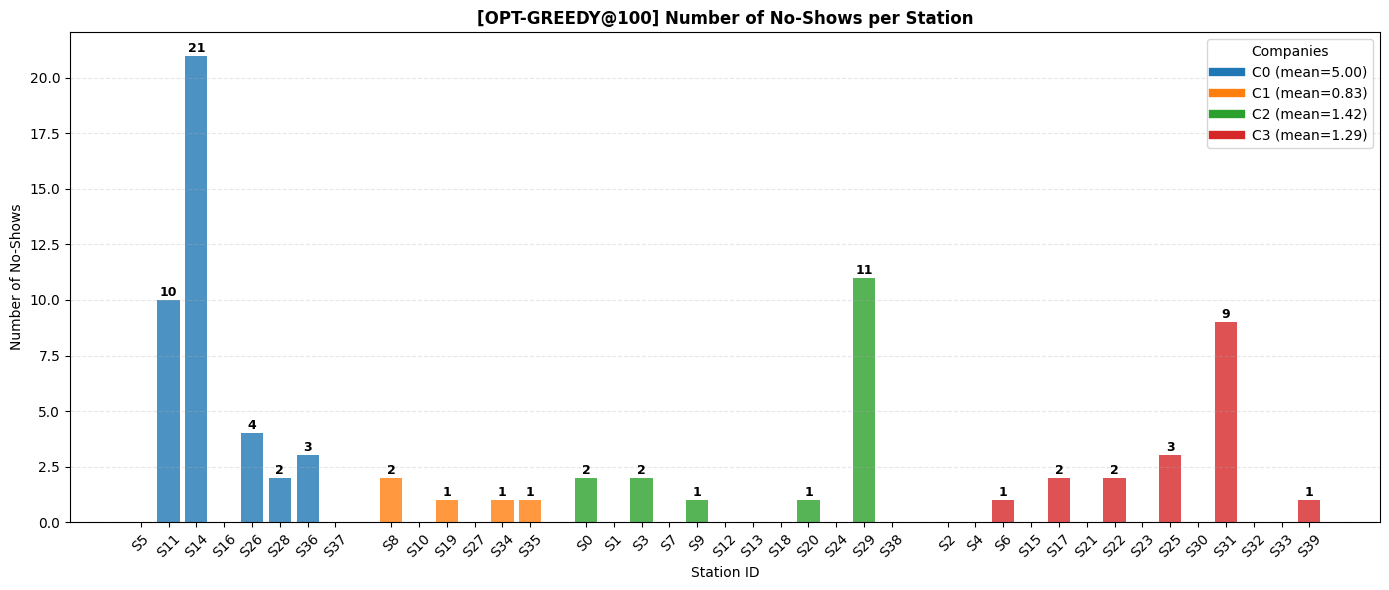

In [63]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [64]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,5,4,4,0,0,0,1.000000,0.000000,0.0,0.0
1,0,11,95,83,10,0,0,0.873684,0.105263,0.0,0.0
2,0,14,113,91,21,0,0,0.805310,0.185841,0.0,0.0
3,0,16,3,3,0,0,0,1.000000,0.000000,0.0,0.0
4,0,26,36,31,4,0,0,0.861111,0.111111,0.0,0.0
5,0,28,14,11,2,0,0,0.785714,0.142857,0.0,0.0
6,0,36,26,23,3,0,0,0.884615,0.115385,0.0,0.0
7,0,37,4,4,0,0,0,1.000000,0.000000,0.0,0.0
8,1,8,15,13,2,0,0,0.866667,0.133333,0.0,0.0
9,1,10,0,0,0,0,0,NaN,NaN,NaN,NaN


#### **BRAM-EV**

##### *Params*

In [65]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [66]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [67]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:23:09.056 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 23:23:09.630 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 23:23:09.921 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 23:23:10.725 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 23:23:11.862 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 23:23:12.553 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 23:23:13.233 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 23:23:14.080 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 23:23:15.331 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 23:23:16.207 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 23:23:17.210 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [68]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 42.52 kWh
  Station 1: 7.93 kWh
  Station 2: 39.28 kWh
  Station 3: 22.02 kWh
  Station 4: 1.87 kWh
  Station 5: 0.00 kWh
  Station 6: 0.00 kWh
  Station 7: 37.64 kWh
  Station 8: 0.00 kWh
  Station 9: 59.77 kWh
  Station 10: 34.55 kWh
  Station 11: 153.84 kWh
  Station 12: 38.00 kWh
  Station 13: 1.13 kWh
  Station 14: 9.61 kWh
  Station 15: 10.67 kWh
  Station 16: 41.59 kWh
  Station 17: 15.65 kWh
  Station 18: 27.45 kWh
  Station 19: 33.88 kWh
  Station 20: 4.45 kWh
  Station 21: 127.47 kWh
  Station 22: 0.00 kWh
  Station 23: 3.27 kWh
  Station 24: 3.23 kWh
  Station 25: 14.22 kWh
  Station 26: 3.17 kWh
  Station 27: 8.45 kWh
  Station 28: 50.58 kWh
  Station 29: 12.11 kWh
  Station 30: 4.01 kWh
  Station 31: 10.43 kWh
  Station 32: 136.07 kWh
  Station 33: 12.49 kWh
  Station 34: 3.45 kWh
  Station 35: 3.98 kWh
  Station 36: 7.08 kWh
  Station 37: 0.00 kWh
  Station 38: 111.41 kWh
  Station 39: 16.47 kWh



In [69]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

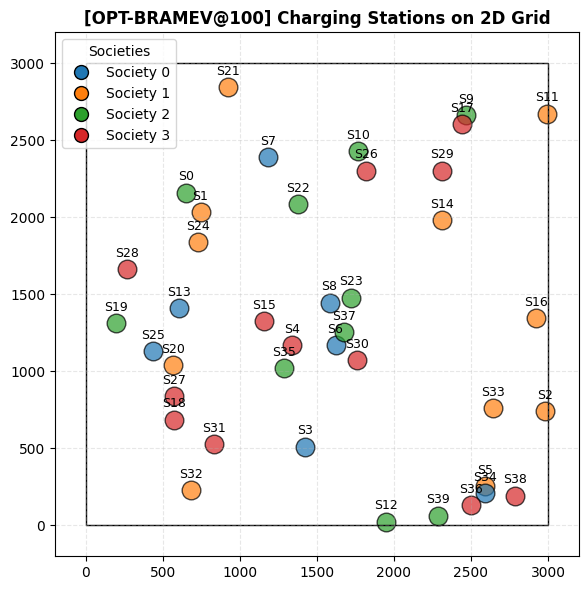

In [70]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

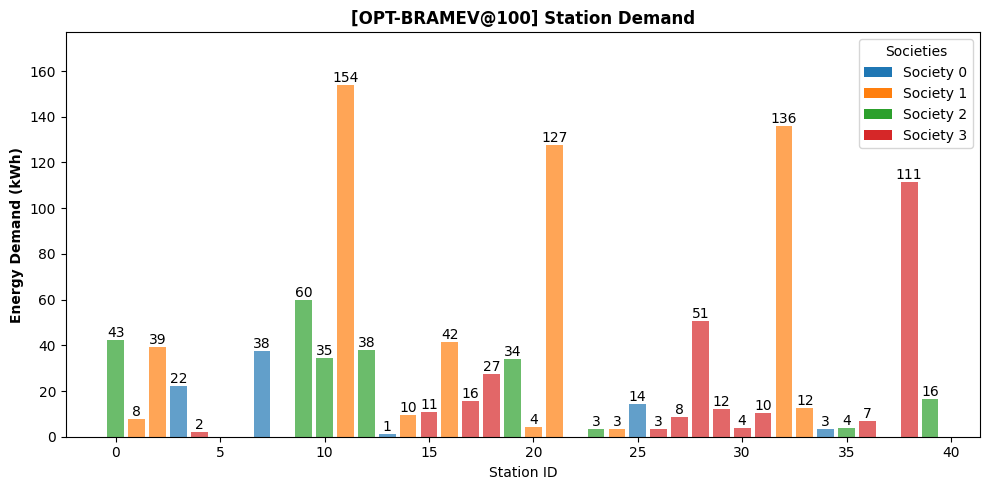

In [71]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

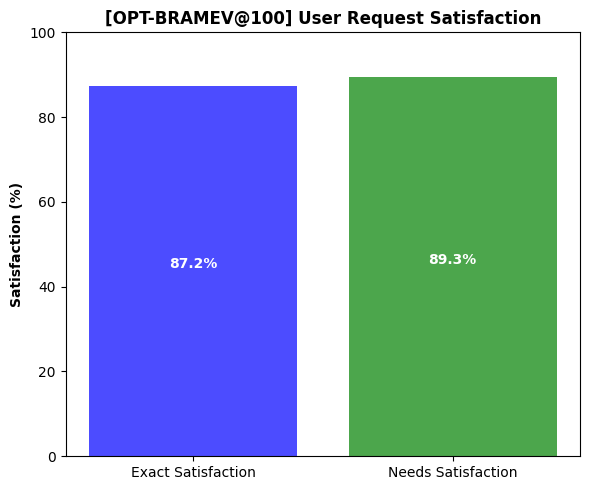

In [72]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

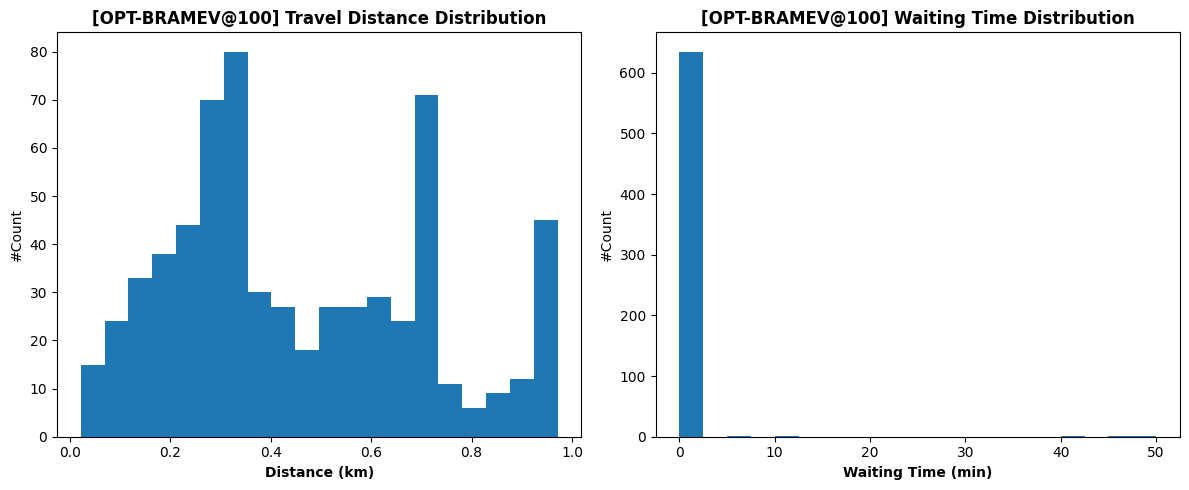

In [73]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

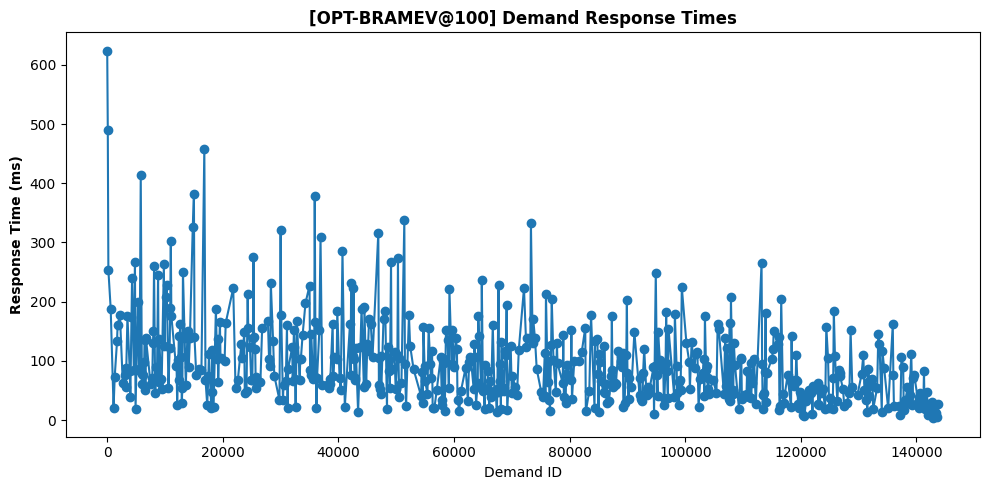

In [74]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

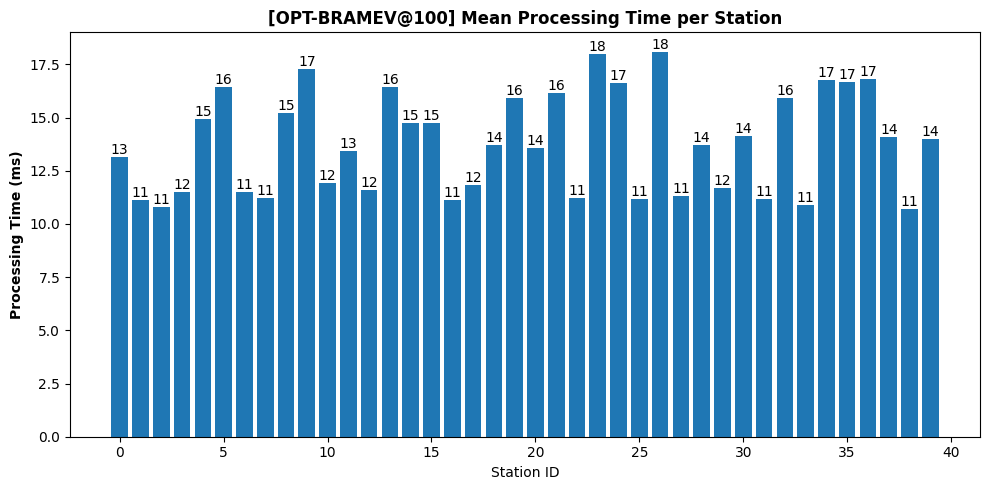

In [75]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

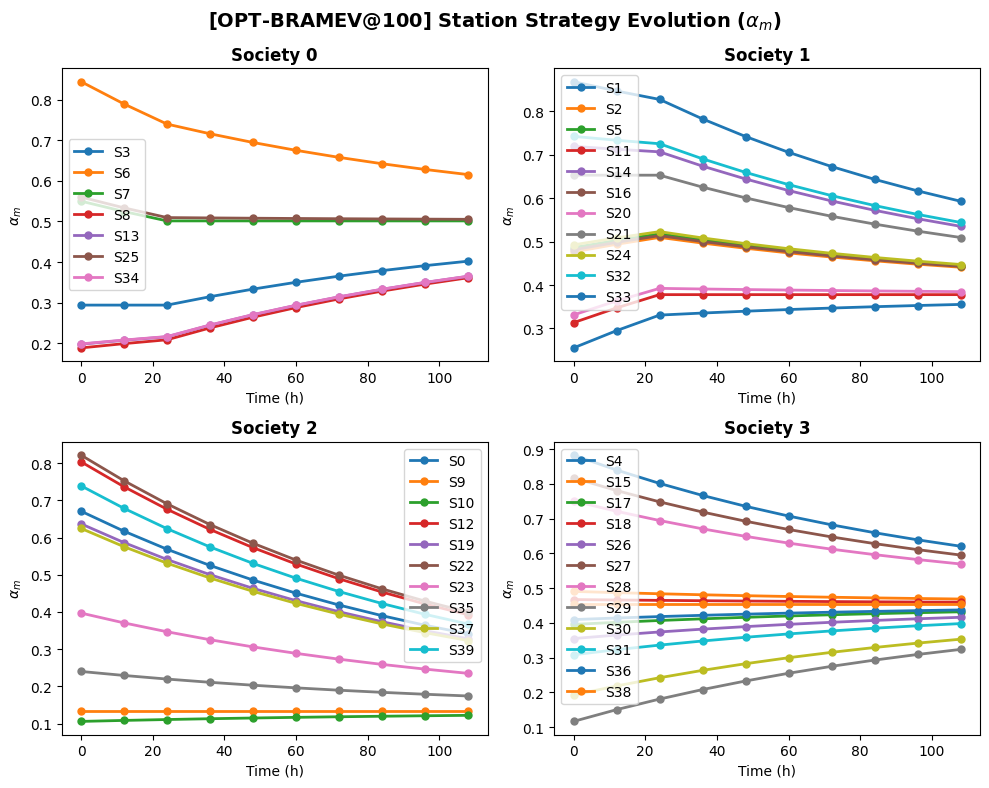

In [76]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [77]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           3  0.259028  0.066667  0.000000  0.000000       NaN   
1            0           6  0.000000  0.000000  0.000000  0.000000       NaN   
2            0           7  0.340278  0.170833  0.000000  0.031944       NaN   
3            0           8  0.000000  0.000000  0.000000  0.000000  0.000000   
4            0          13  0.011806  0.000000  0.000000  0.000000  0.000000   
5            0          25  0.195139  0.000000  0.000000  0.000000       NaN   
6            0          34  0.061806  0.000000  0.000000  0.000000  0.000000   
7            1           1  0.080556  0.031250  0.000000  0.000000       NaN   
8            1           2  0.348611  0.163889  0.022917  0.000000       NaN   
9            1           5  0.000000  0.000000  0.000000  0.000000  0.000000   
10           1          11  0.754167  0.595833  0.325000  0.282639  0.364583   
11           1          14  0.107639  0.

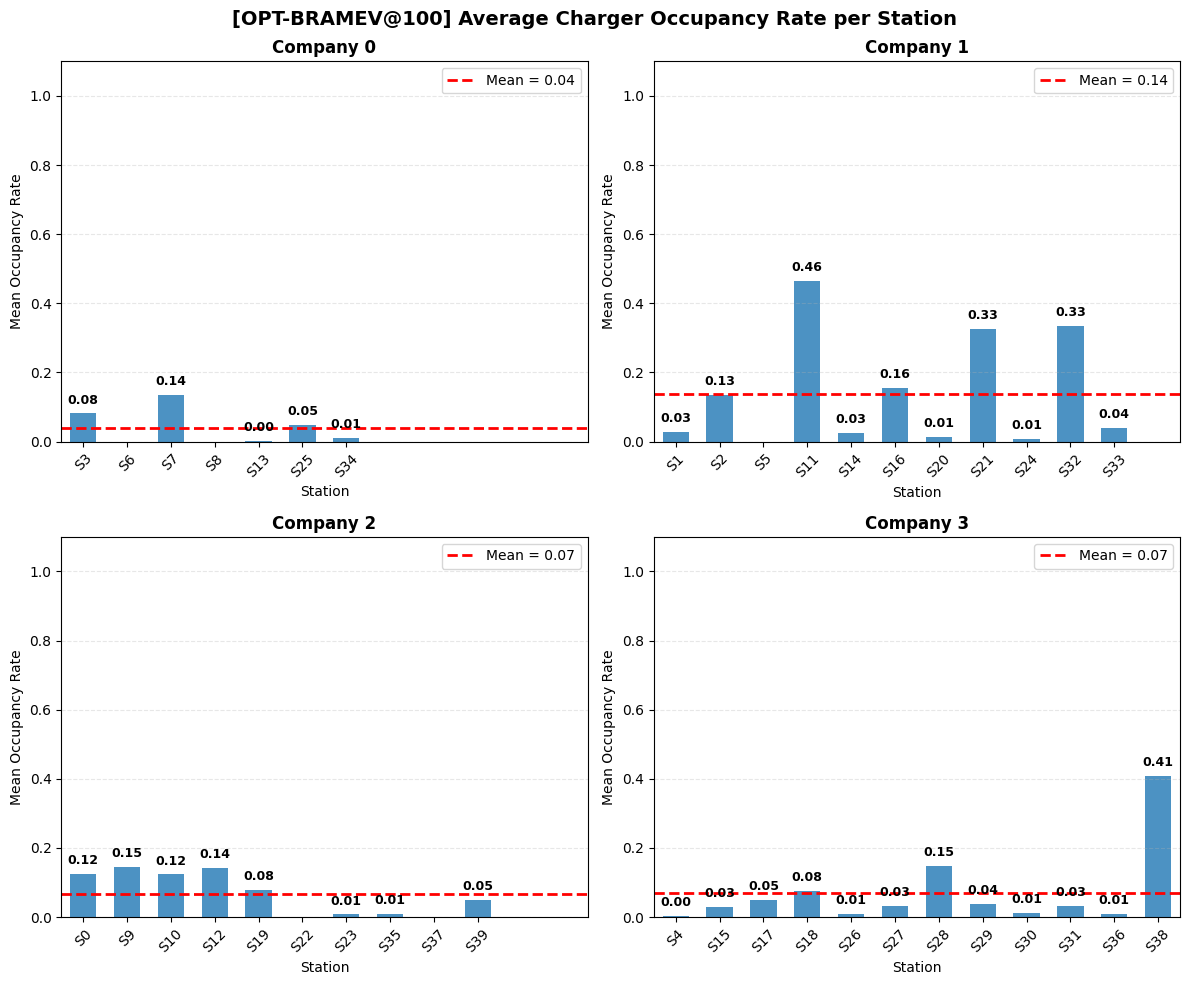

In [78]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

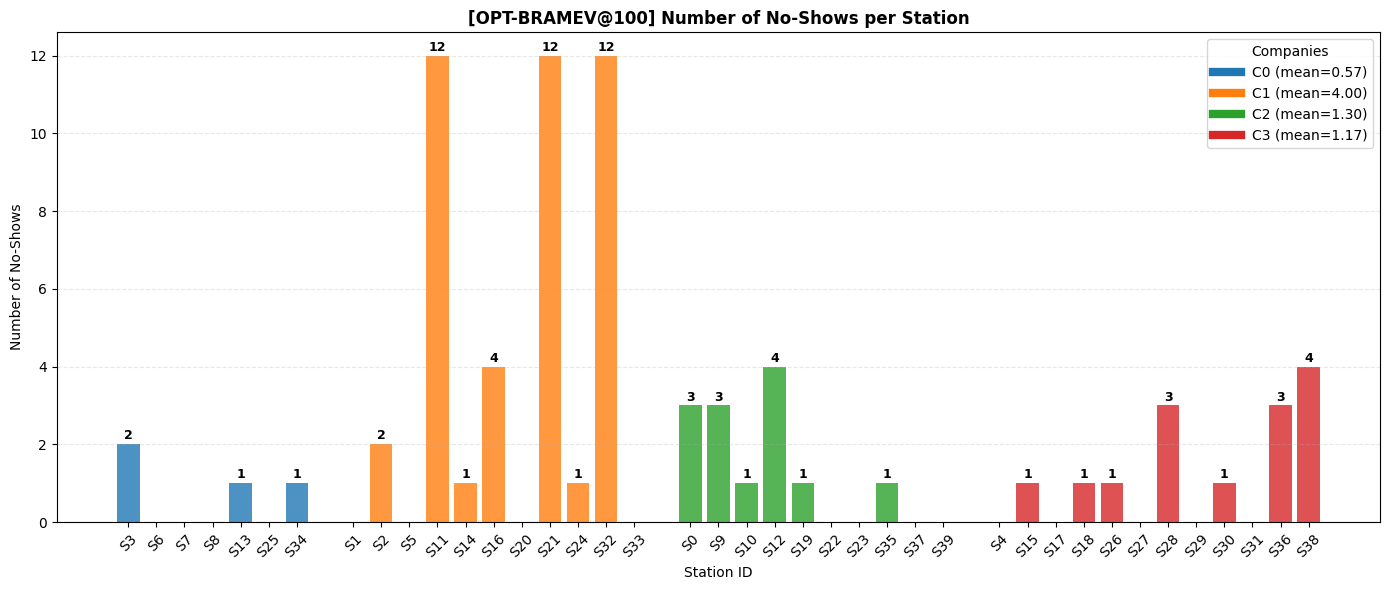

In [79]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [80]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,3,15,13,2,0,0,0.866667,0.133333,0.0,0.0
1,0,6,0,0,0,0,0,NaN,NaN,NaN,NaN
2,0,7,20,20,0,0,0,1.000000,0.000000,0.0,0.0
3,0,8,0,0,0,0,0,NaN,NaN,NaN,NaN
4,0,13,2,1,1,0,0,0.500000,0.500000,0.0,0.0
5,0,25,8,8,0,0,0,1.000000,0.000000,0.0,0.0
6,0,34,4,3,1,0,0,0.750000,0.250000,0.0,0.0
7,1,1,4,4,0,0,0,1.000000,0.000000,0.0,0.0
8,1,2,25,23,2,0,0,0.920000,0.080000,0.0,0.0
9,1,5,0,0,0,0,0,NaN,NaN,NaN,NaN


#### **COMPARISON**

##### *Params*

In [81]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

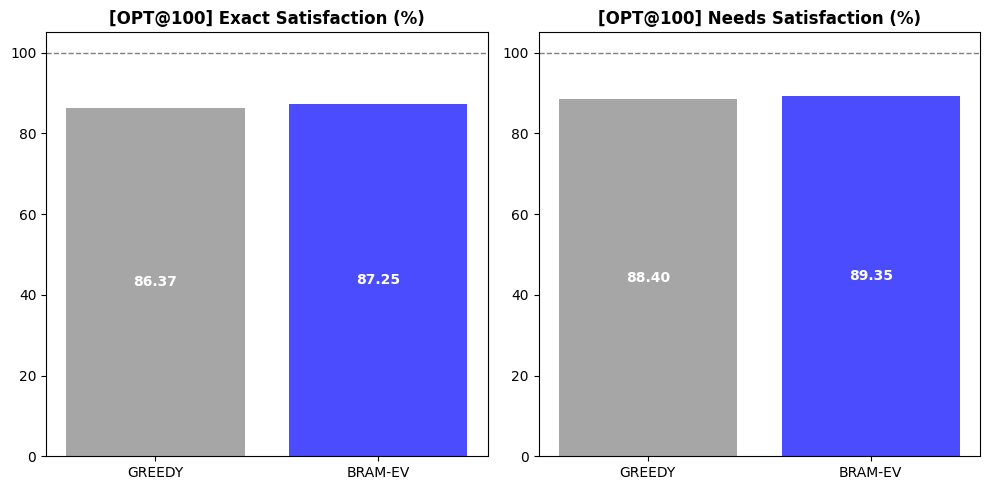

In [82]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

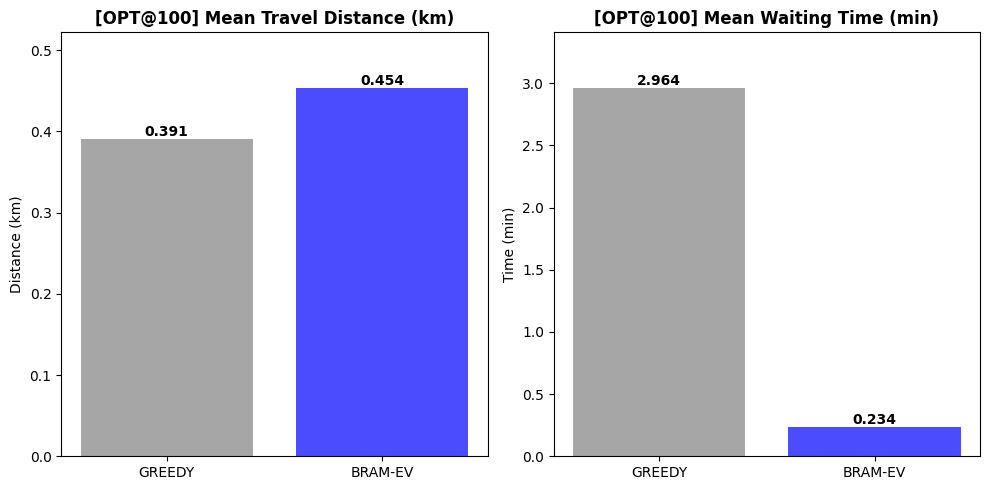

In [83]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

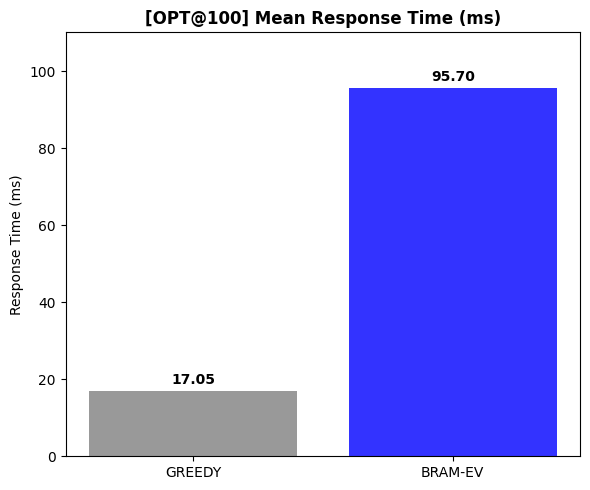

In [84]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@150cars**

#### **CONFIG**

In [85]:
nb_car = 150
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [ ]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/150cars


##### *Initialisation*

In [87]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [88]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:24:07.876 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-13 23:24:08.051 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-13 23:24:08.249 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-13 23:24:08.412 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-13 23:24:08.695 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-13 23:24:08.895 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-13 23:24:09.161 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-13 23:24:09.463 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-13 23:24:09.658 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-13 23:24:09.873 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-13 23:24:10.154 | IN

##### *Metrics*

In [89]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 7.96 kWh
  Station 1: 2.99 kWh
  Station 2: 8.42 kWh
  Station 3: 132.02 kWh
  Station 4: 252.78 kWh
  Station 5: 8.94 kWh
  Station 6: 12.07 kWh
  Station 7: 7.30 kWh
  Station 8: 7.43 kWh
  Station 9: 52.46 kWh
  Station 10: 76.67 kWh
  Station 11: 10.97 kWh
  Station 12: 1.40 kWh
  Station 13: 29.03 kWh
  Station 14: 87.87 kWh
  Station 15: 6.00 kWh
  Station 16: 56.73 kWh
  Station 17: 7.14 kWh
  Station 18: 9.63 kWh
  Station 19: 154.52 kWh
  Station 20: 36.11 kWh
  Station 21: 7.12 kWh
  Station 22: 3.50 kWh
  Station 23: 6.94 kWh
  Station 24: 11.03 kWh
  Station 25: 0.00 kWh
  Station 26: 37.50 kWh
  Station 27: 5.21 kWh
  Station 28: 1.80 kWh
  Station 29: 7.61 kWh
  Station 30: 156.22 kWh
  Station 31: 48.82 kWh
  Station 32: 60.88 kWh
  Station 33: 8.42 kWh
  Station 34: 4.30 kWh
  Station 35: 44.31 kWh
  Station 36: 5.65 kWh
  Station 37: 5.78 kWh
  Station 38: 240.26 kWh
  Station 39: 6.46 kWh

---

In [90]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

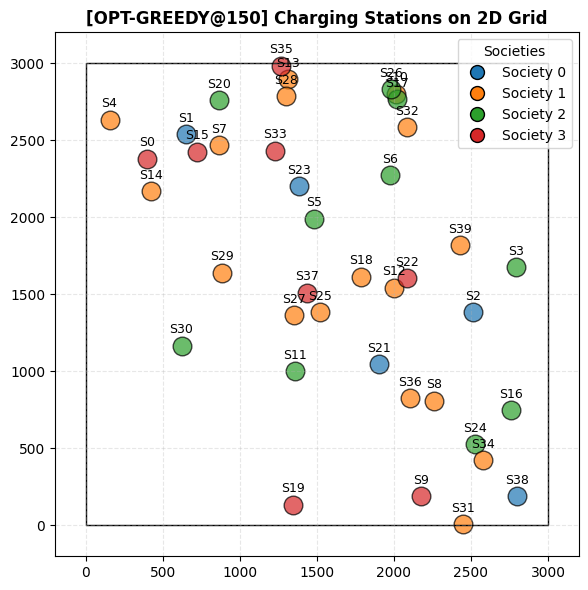

In [91]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

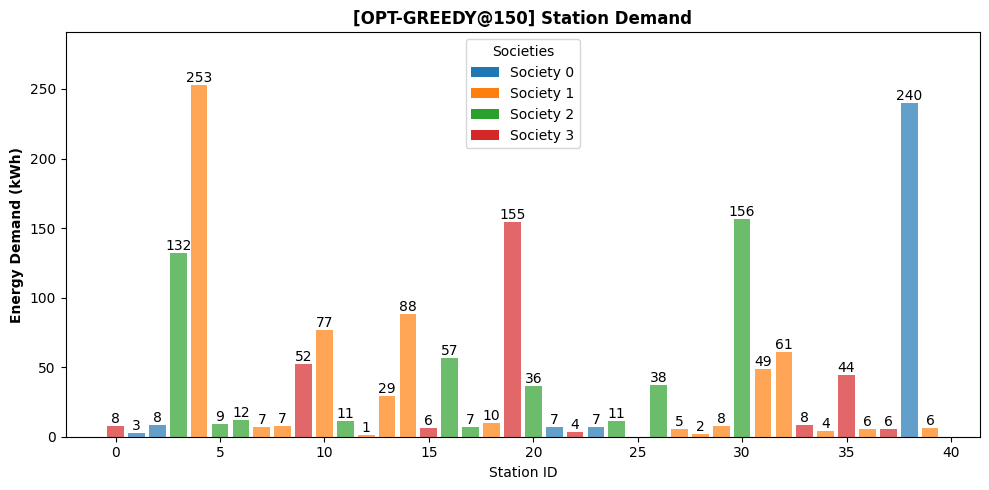

In [92]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

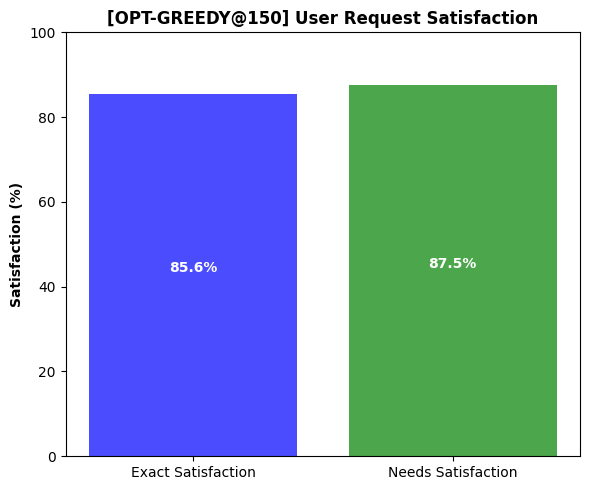

In [93]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

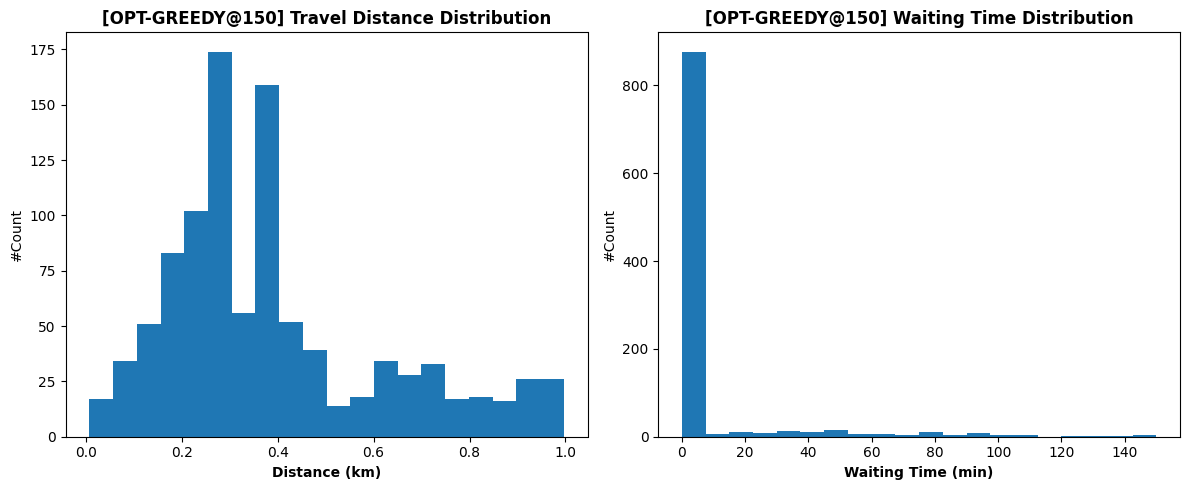

In [94]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

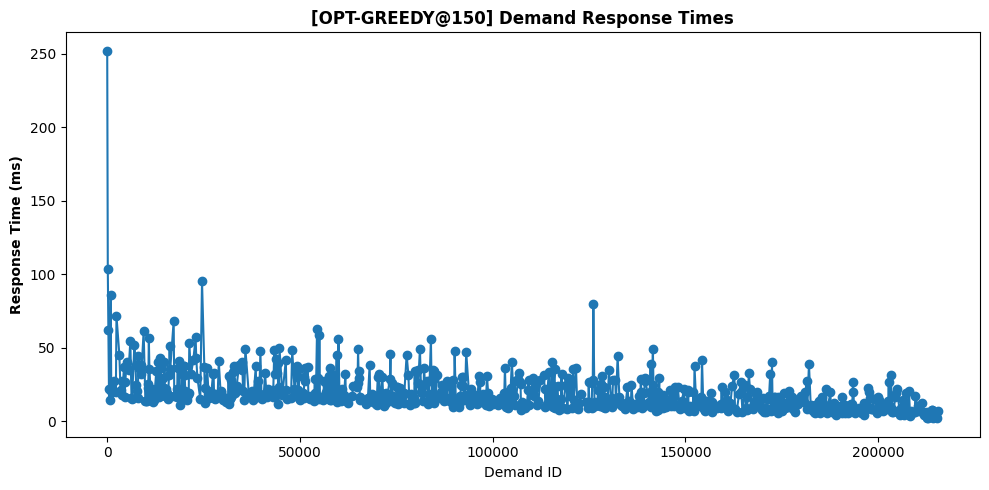

In [95]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

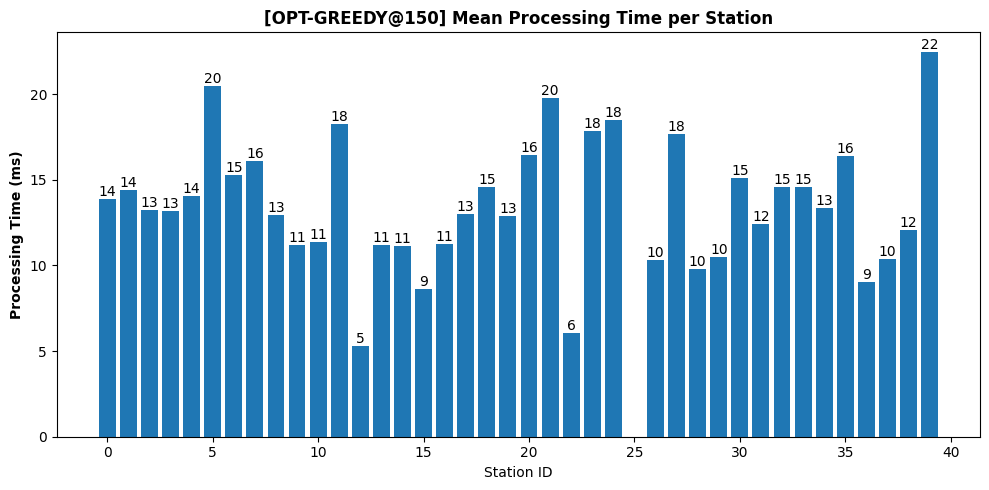

In [96]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [97]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.038194  0.000000  0.000000  0.000000  0.000000   
1            0           2  0.107639  0.000000  0.000000  0.000000  0.000000   
2            0          21  0.058333  0.020833  0.000000  0.000000  0.000000   
3            0          23  0.080556  0.025694  0.000000  0.000000  0.000000   
4            0          38  0.647917  0.736111  0.709028  0.579861  0.715972   
5            1           4  0.688194  0.738889  0.602778  0.595139  0.522222   
6            1           7  0.099306  0.000000  0.000000  0.000000  0.000000   
7            1           8  0.128472  0.000000  0.000000  0.000000       NaN   
8            1          10  0.538194  0.365972  0.123611  0.169444       NaN   
9            1          12  0.014583  0.000000  0.000000  0.000000       NaN   
10           1          13  0.258333  0.139583  0.018750  0.038194       NaN   
11           1          14  0.634028  0.

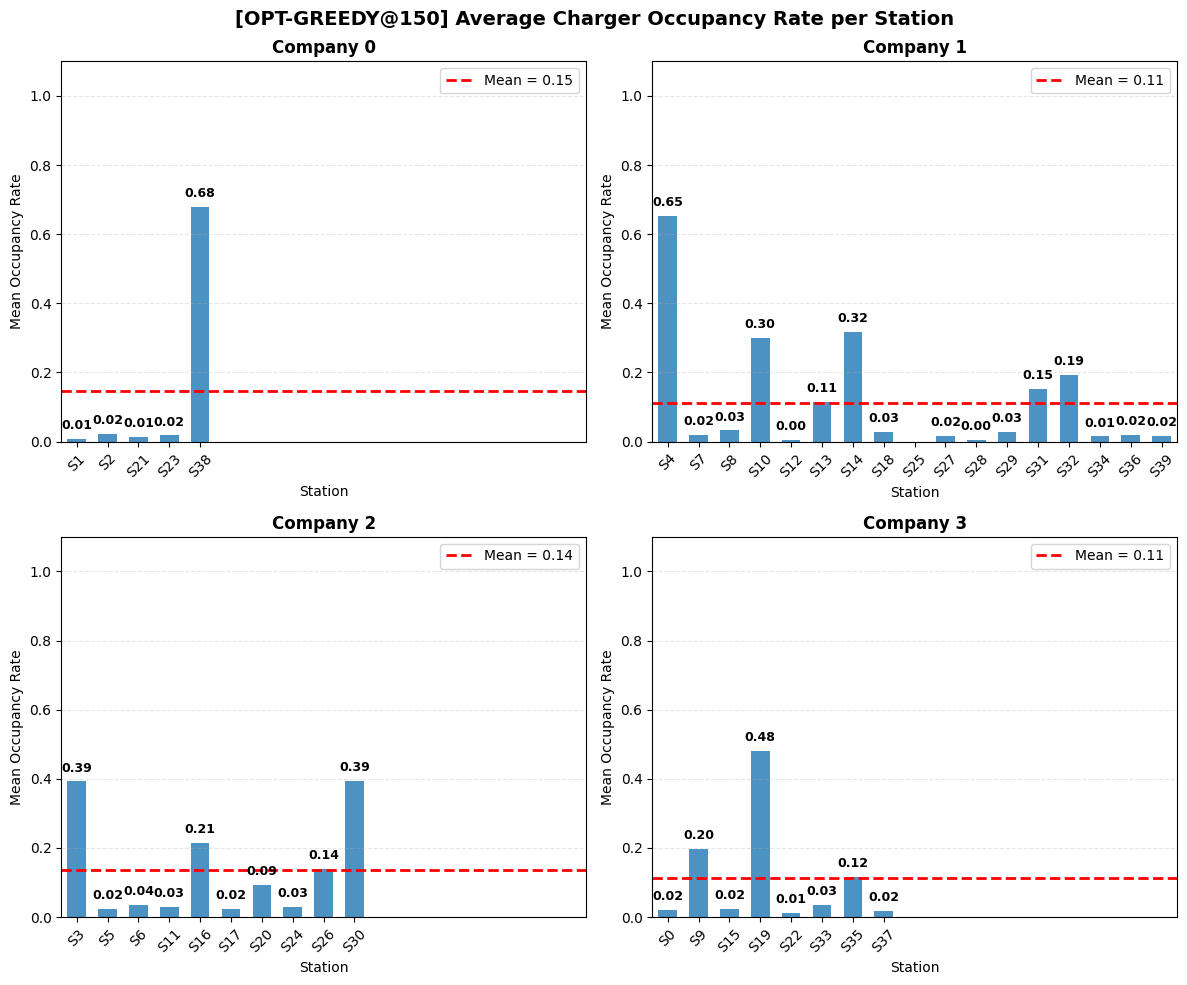

In [98]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

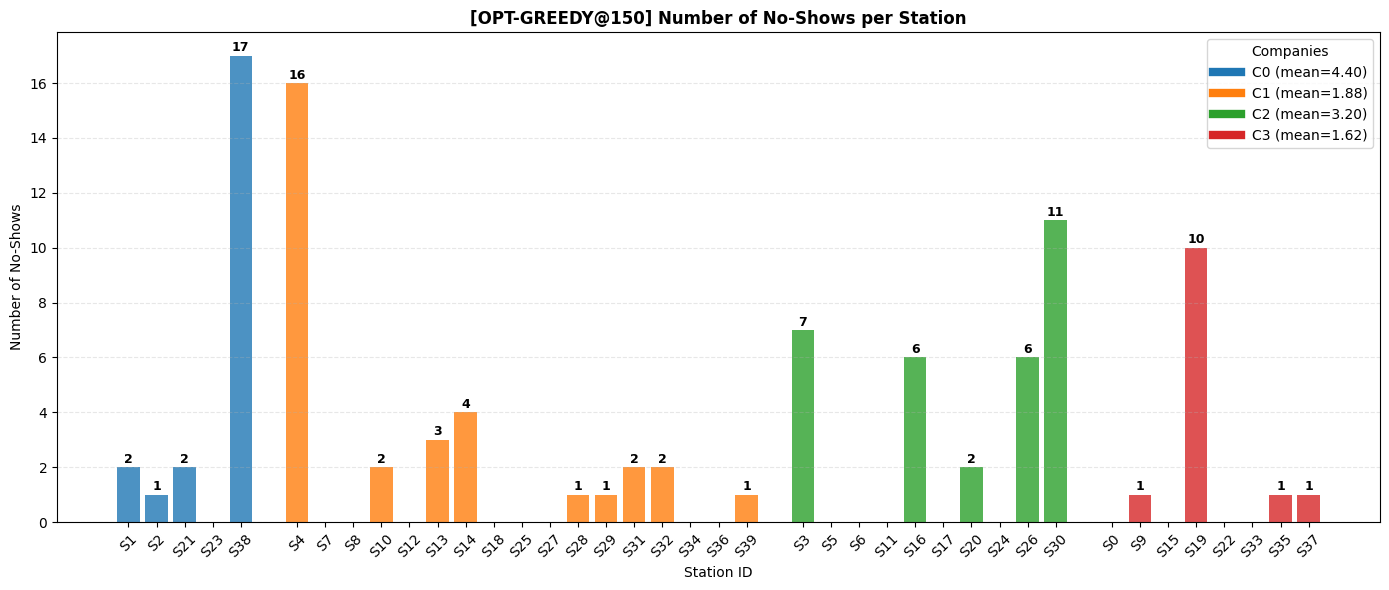

In [99]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [100]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,4,2,2,0,0,0.500000,0.500000,0.0,0.0
1,0,2,6,5,1,0,0,0.833333,0.166667,0.0,0.0
2,0,21,6,4,2,0,0,0.666667,0.333333,0.0,0.0
3,0,23,4,4,0,0,0,1.000000,0.000000,0.0,0.0
4,0,38,171,153,17,0,0,0.894737,0.099415,0.0,0.0
5,1,4,179,163,16,0,0,0.910615,0.089385,0.0,0.0
6,1,7,4,4,0,0,0,1.000000,0.000000,0.0,0.0
7,1,8,4,4,0,0,0,1.000000,0.000000,0.0,0.0
8,1,10,46,44,2,0,0,0.956522,0.043478,0.0,0.0
9,1,12,1,1,0,0,0,1.000000,0.000000,0.0,0.0


#### **BRAM-EV**

##### *Params*

In [101]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [102]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [103]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:24:29.753 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 23:24:30.505 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 23:24:31.837 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 23:24:32.679 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 23:24:33.635 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 23:24:34.469 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 23:24:35.789 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 23:24:37.291 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 23:24:38.287 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 23:24:38.786 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 23:24:39.828 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [104]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 73.60 kWh
  Station 1: 0.00 kWh
  Station 2: 9.82 kWh
  Station 3: 221.09 kWh
  Station 4: 24.02 kWh
  Station 5: 20.88 kWh
  Station 6: 168.74 kWh
  Station 7: 5.52 kWh
  Station 8: 13.43 kWh
  Station 9: 53.25 kWh
  Station 10: 12.70 kWh
  Station 11: 1.37 kWh
  Station 12: 7.02 kWh
  Station 13: 8.85 kWh
  Station 14: 5.13 kWh
  Station 15: 8.85 kWh
  Station 16: 3.02 kWh
  Station 17: 47.82 kWh
  Station 18: 31.87 kWh
  Station 19: 99.23 kWh
  Station 20: 84.62 kWh
  Station 21: 157.84 kWh
  Station 22: 3.71 kWh
  Station 23: 4.72 kWh
  Station 24: 4.58 kWh
  Station 25: 203.88 kWh
  Station 26: 11.66 kWh
  Station 27: 19.68 kWh
  Station 28: 74.18 kWh
  Station 29: 2.65 kWh
  Station 30: 4.26 kWh
  Station 31: 9.00 kWh
  Station 32: 40.58 kWh
  Station 33: 74.47 kWh
  Station 34: 3.47 kWh
  Station 35: 61.27 kWh
  Station 36: 21.27 kWh
  Station 37: 0.00 kWh
  Station 38: 40.65 kWh
  Station 39: 16.23 kWh


In [105]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

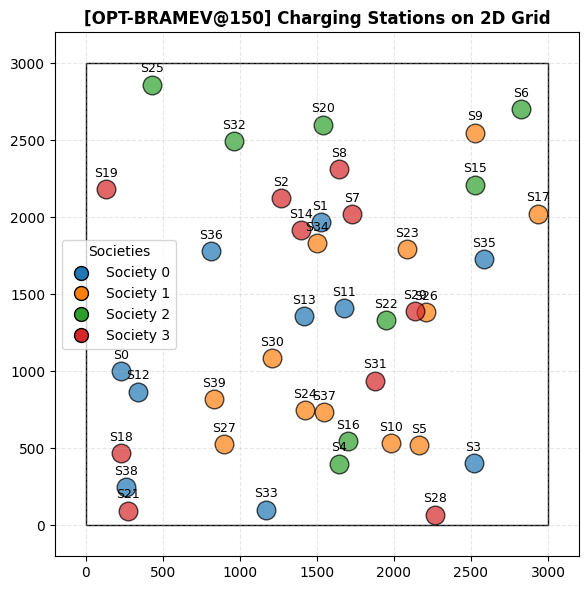

In [106]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

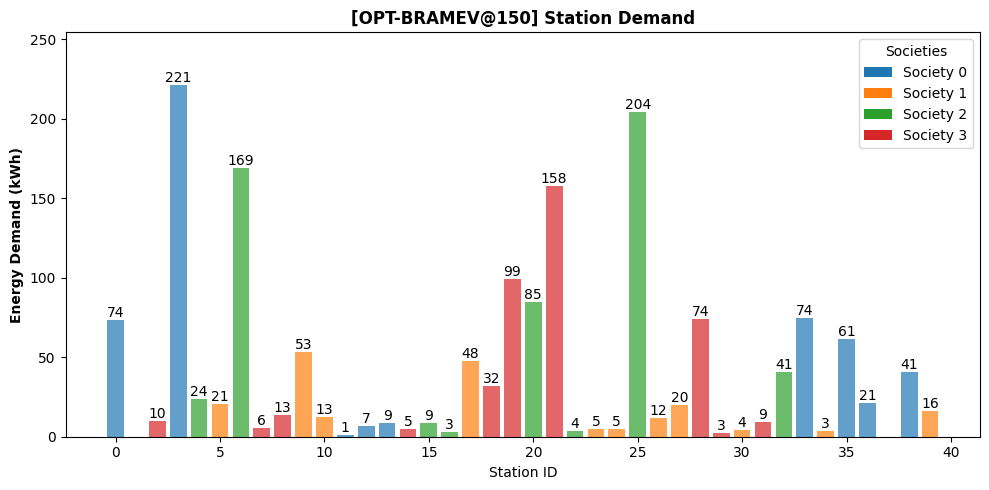

In [107]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

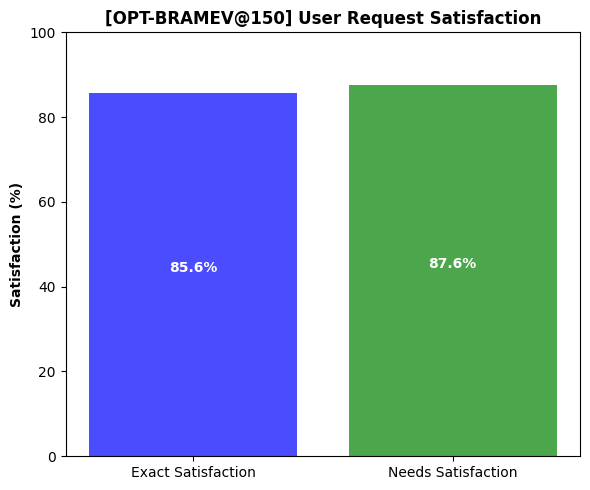

In [108]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

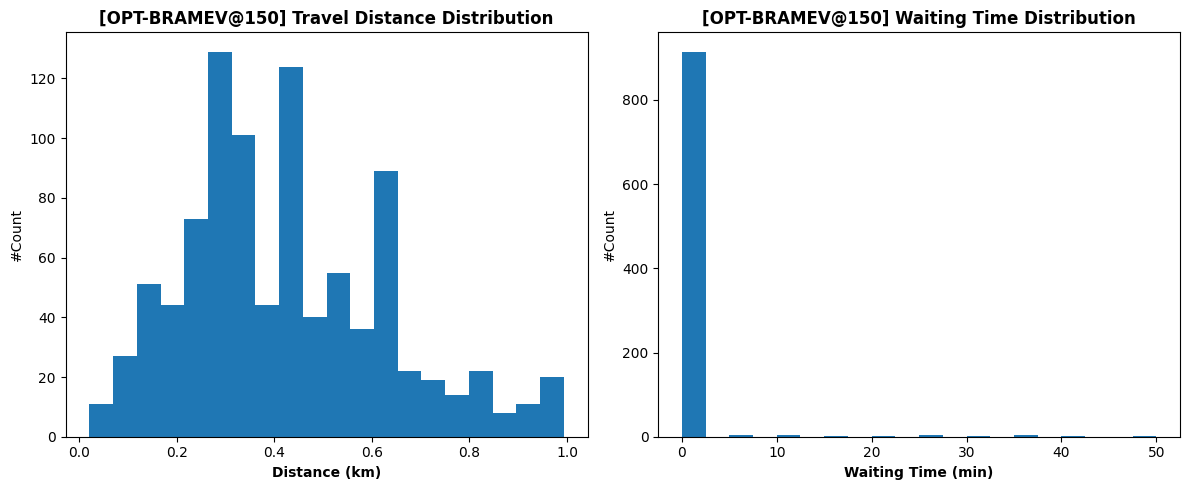

In [109]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

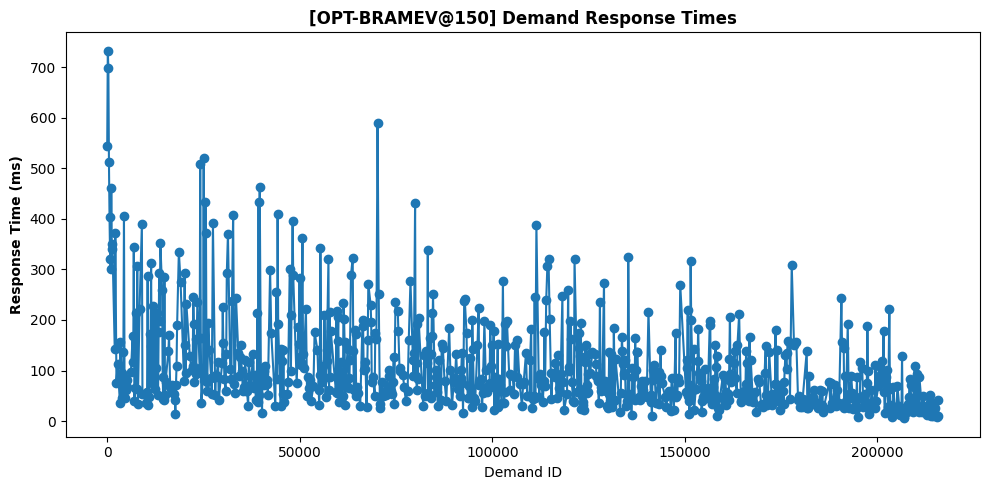

In [110]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

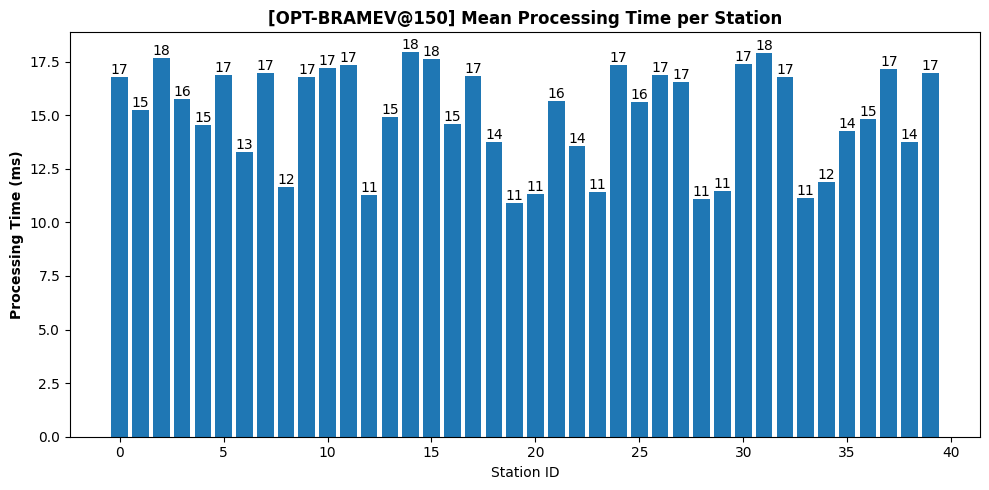

In [111]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

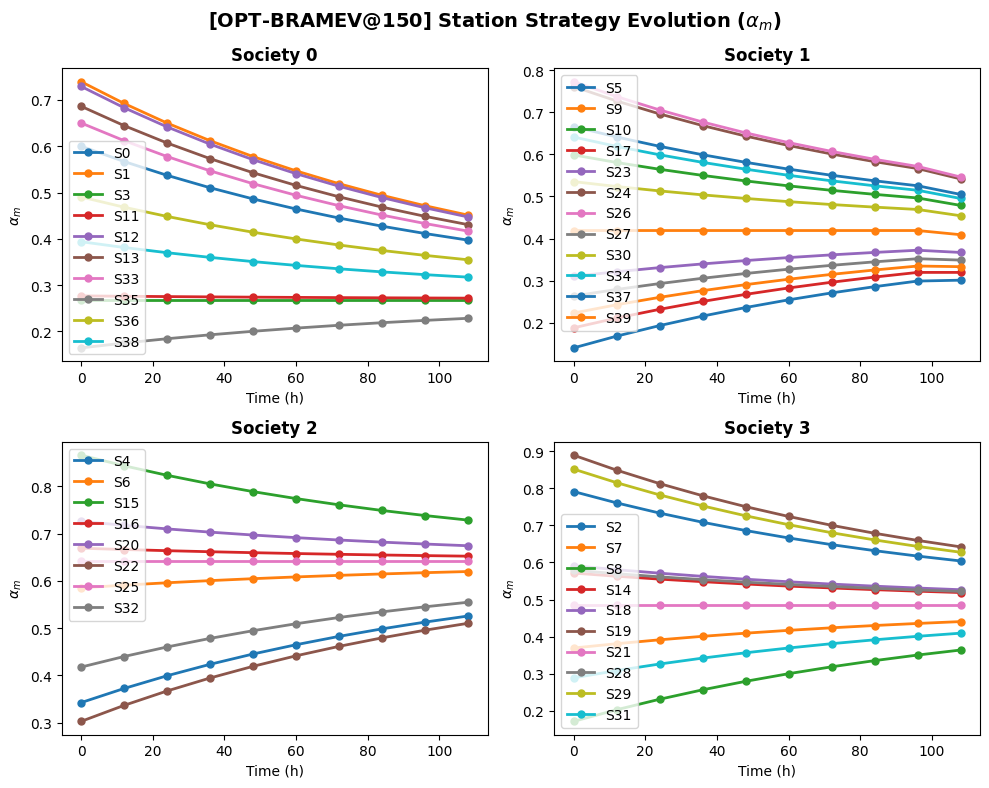

In [112]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [113]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           0  0.575000  0.340278  0.117361  0.000000  0.000000   
1            0           1  0.000000  0.000000  0.000000  0.000000  0.000000   
2            0           3  0.704167  0.675000  0.545833  0.354167  0.318750   
3            0          11  0.028472  0.000000  0.000000  0.000000  0.000000   
4            0          12  0.070139  0.015972  0.000000  0.000000       NaN   
5            0          13  0.114583  0.015972  0.000000  0.000000  0.000000   
6            0          33  0.481944  0.330556  0.097222  0.125000       NaN   
7            0          35  0.484028  0.311806  0.082639  0.000000  0.075694   
8            0          36  0.223611  0.081944  0.019444  0.000000  0.000000   
9            0          38  0.326389  0.197917  0.059722  0.000000  0.000000   
10           1           5  0.279861  0.058333  0.000000  0.000000  0.000000   
11           1           9  0.395833  0.

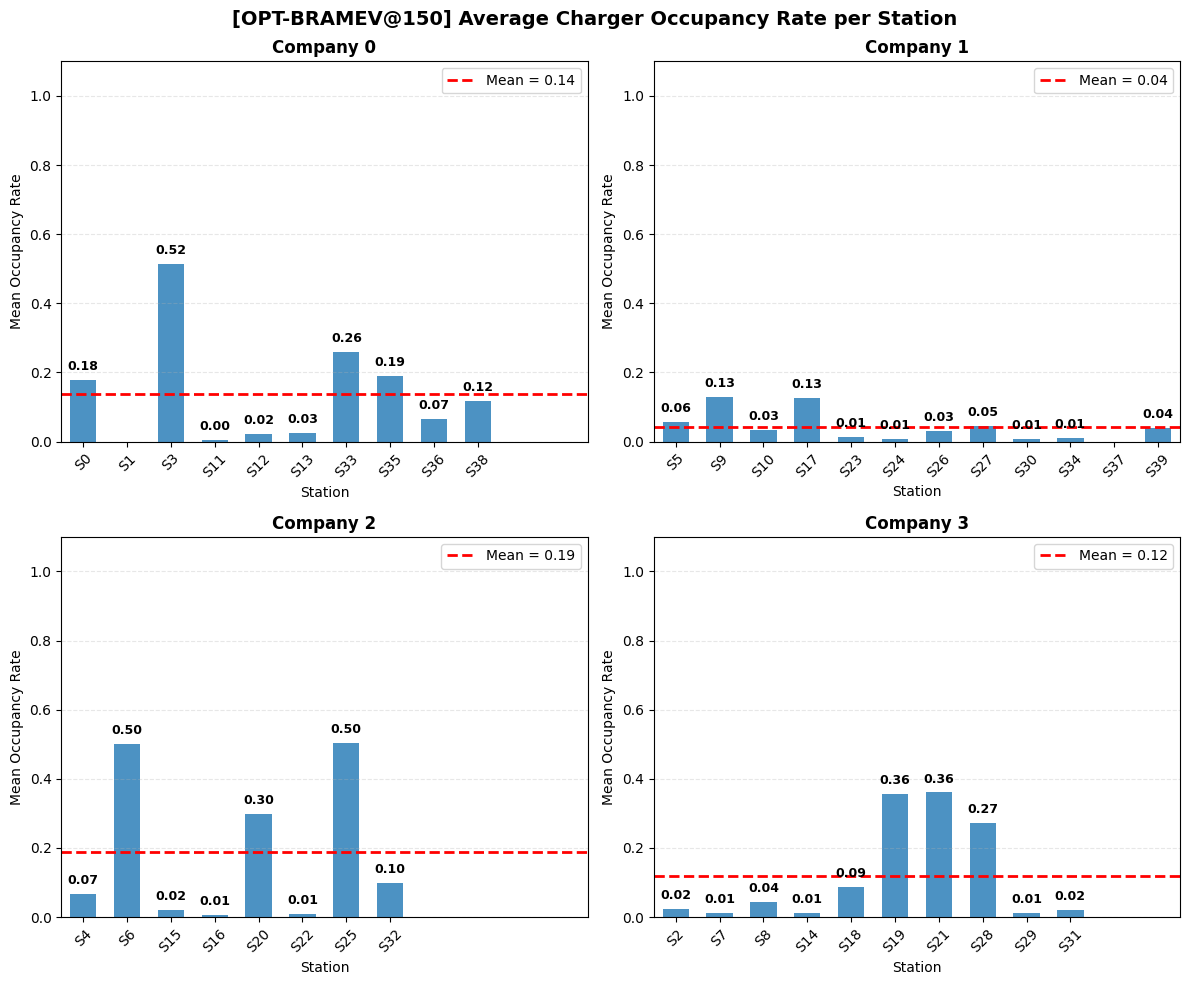

In [114]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

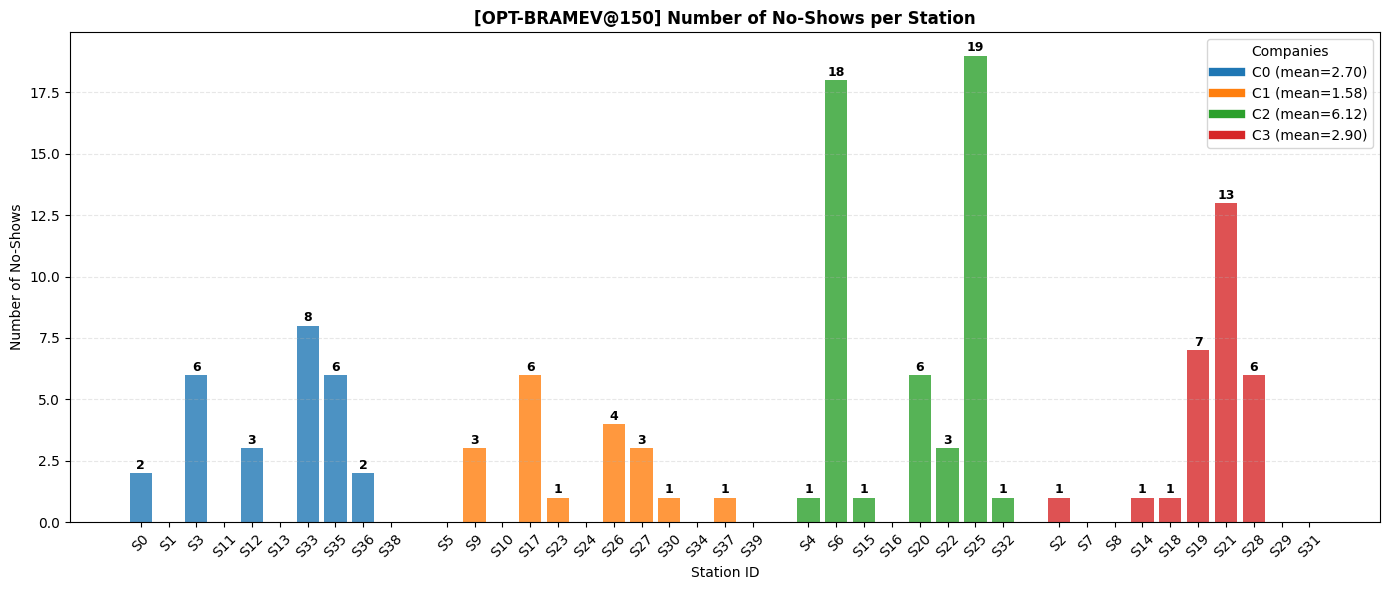

In [115]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [116]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,0,45,43,2,0,0,0.955556,0.044444,0.0,0.0
1,0,1,0,0,0,0,0,NaN,NaN,NaN,NaN
2,0,3,132,126,6,0,0,0.954545,0.045455,0.0,0.0
3,0,11,1,1,0,0,0,1.000000,0.000000,0.0,0.0
4,0,12,7,4,3,0,0,0.571429,0.428571,0.0,0.0
5,0,13,5,5,0,0,0,1.000000,0.000000,0.0,0.0
6,0,33,50,42,8,0,0,0.840000,0.160000,0.0,0.0
7,0,35,41,34,6,0,0,0.829268,0.146341,0.0,0.0
8,0,36,14,12,2,0,0,0.857143,0.142857,0.0,0.0
9,0,38,24,24,0,0,0,1.000000,0.000000,0.0,0.0


#### **COMPARISON**

##### *Params*

In [117]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

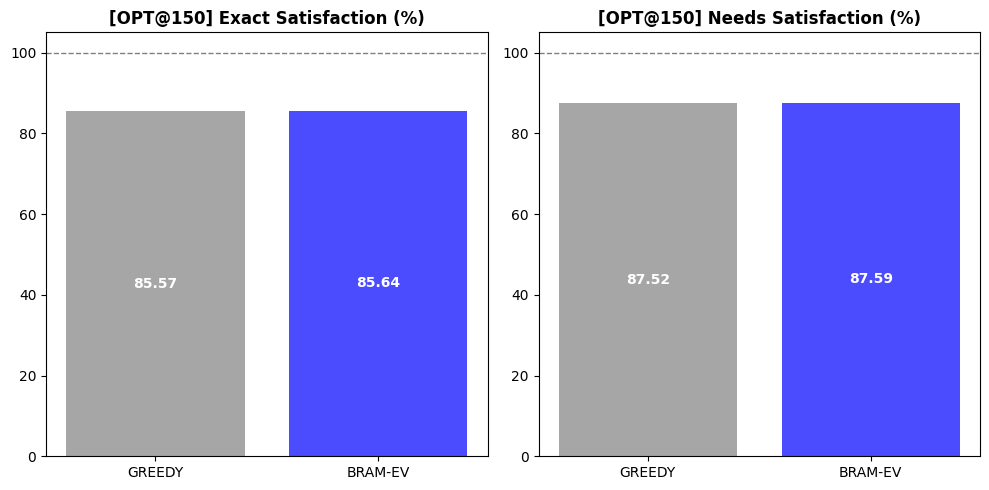

In [118]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

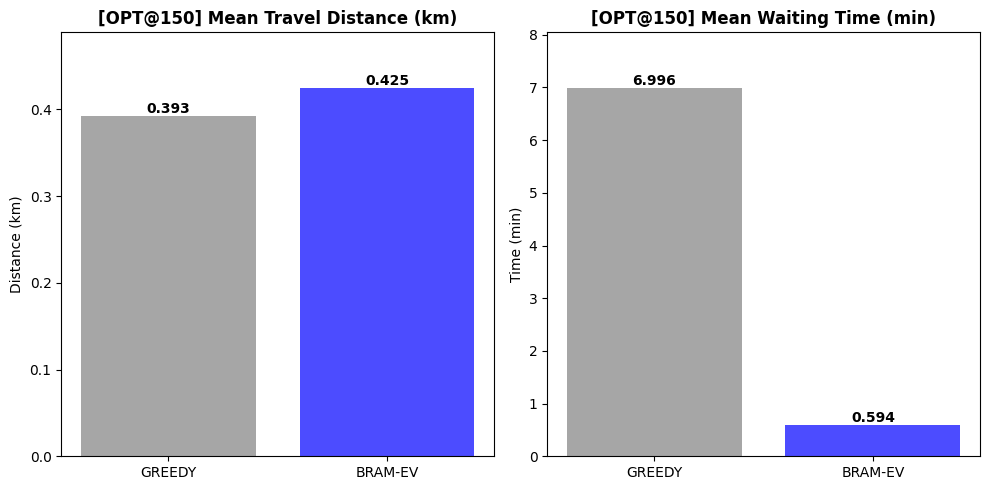

In [119]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

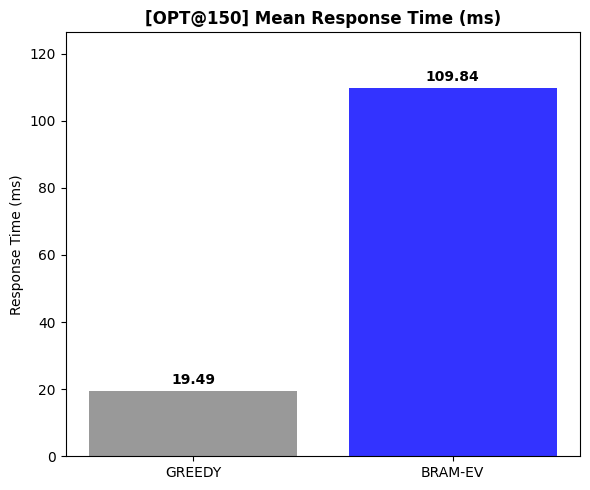

In [120]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@200cars**

#### **CONFIG**

In [121]:
nb_car = 200
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [ ]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/200cars


##### *Initialisation*

In [123]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [124]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:25:57.218 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-13 23:25:57.509 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-13 23:25:57.873 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-13 23:25:58.161 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-13 23:25:58.361 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-13 23:25:58.606 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-13 23:25:58.868 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-13 23:25:59.116 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-13 23:25:59.417 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-13 23:25:59.761 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-13 23:26:00.038 | IN

##### *Metrics*

In [125]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 92.87 kWh
  Station 1: 5.16 kWh
  Station 2: 7.53 kWh
  Station 3: 266.86 kWh
  Station 4: 216.19 kWh
  Station 5: 6.78 kWh
  Station 6: 14.54 kWh
  Station 7: 96.18 kWh
  Station 8: 0.00 kWh
  Station 9: 77.05 kWh
  Station 10: 5.52 kWh
  Station 11: 8.69 kWh
  Station 12: 103.69 kWh
  Station 13: 72.63 kWh
  Station 14: 47.98 kWh
  Station 15: 0.00 kWh
  Station 16: 45.01 kWh
  Station 17: 5.58 kWh
  Station 18: 30.48 kWh
  Station 19: 24.48 kWh
  Station 20: 1.65 kWh
  Station 21: 59.94 kWh
  Station 22: 45.62 kWh
  Station 23: 17.67 kWh
  Station 24: 1.87 kWh
  Station 25: 10.92 kWh
  Station 26: 14.64 kWh
  Station 27: 286.96 kWh
  Station 28: 8.90 kWh
  Station 29: 111.80 kWh
  Station 30: 9.24 kWh
  Station 31: 49.42 kWh
  Station 32: 1.87 kWh
  Station 33: 68.08 kWh
  Station 34: 233.82 kWh
  Station 35: 1.20 kWh
  Station 36: 1.77 kWh
  Station 37: 55.17 kWh
  Station 38: 7.30 kWh
  Station 39: 48.19 k

In [126]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

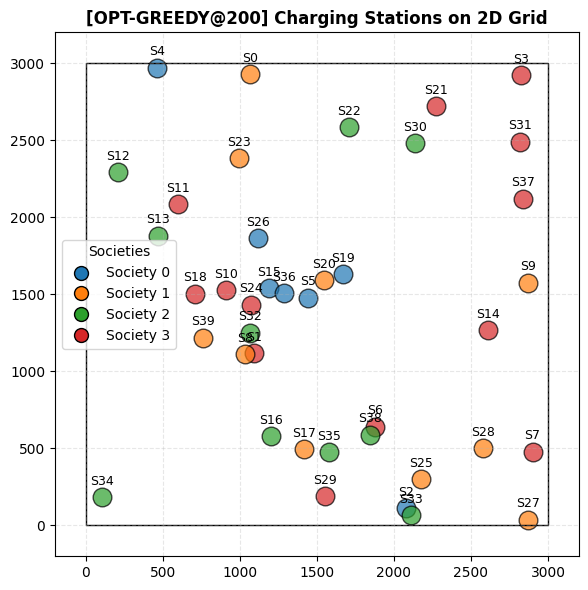

In [127]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

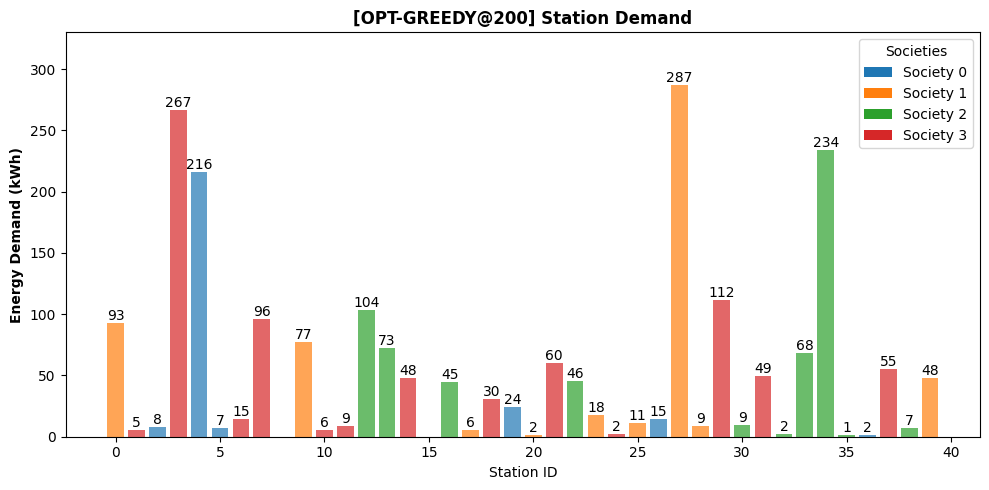

In [128]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

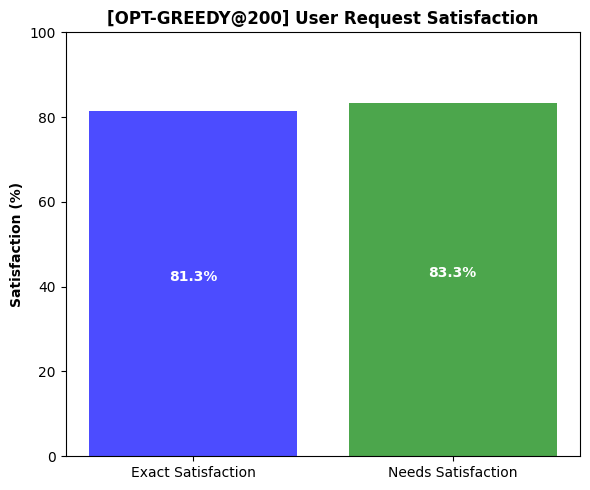

In [129]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

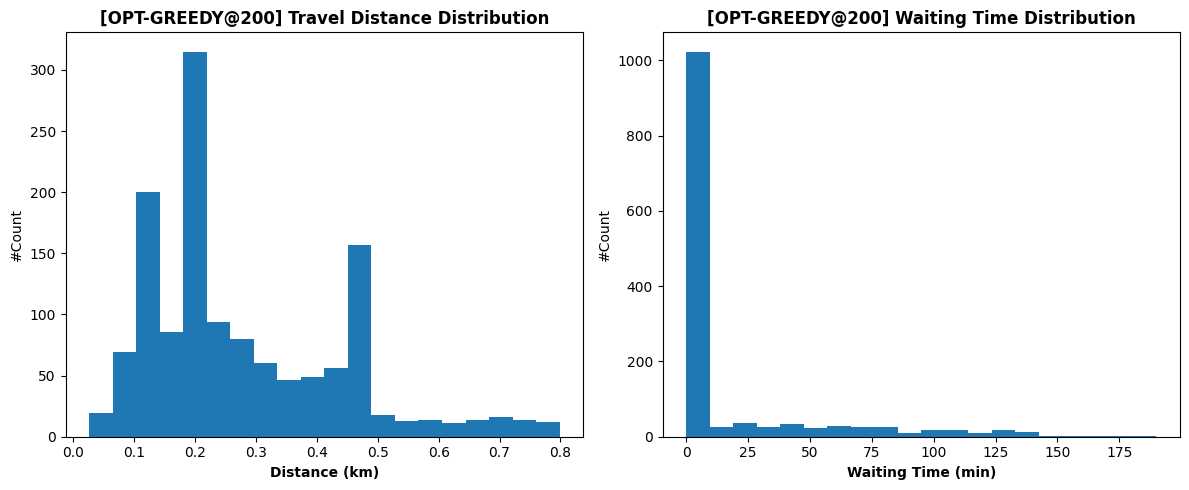

In [130]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

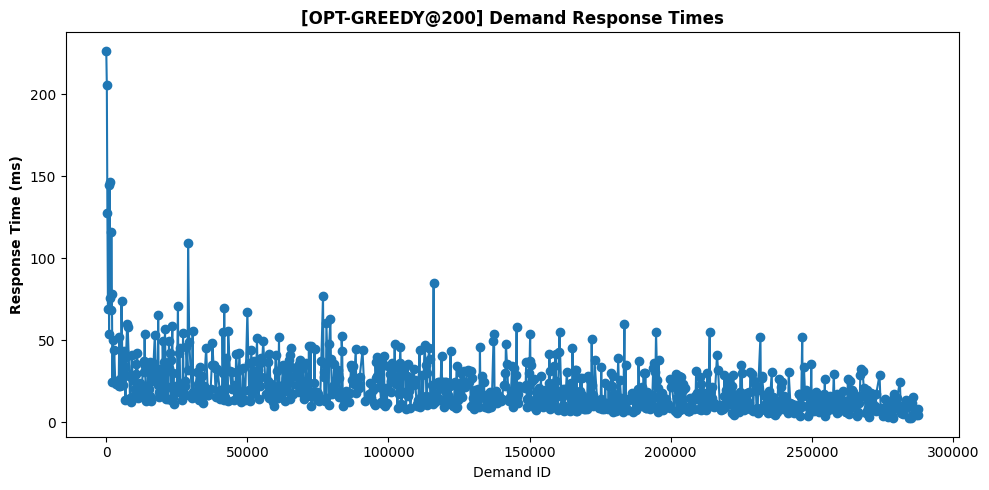

In [131]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

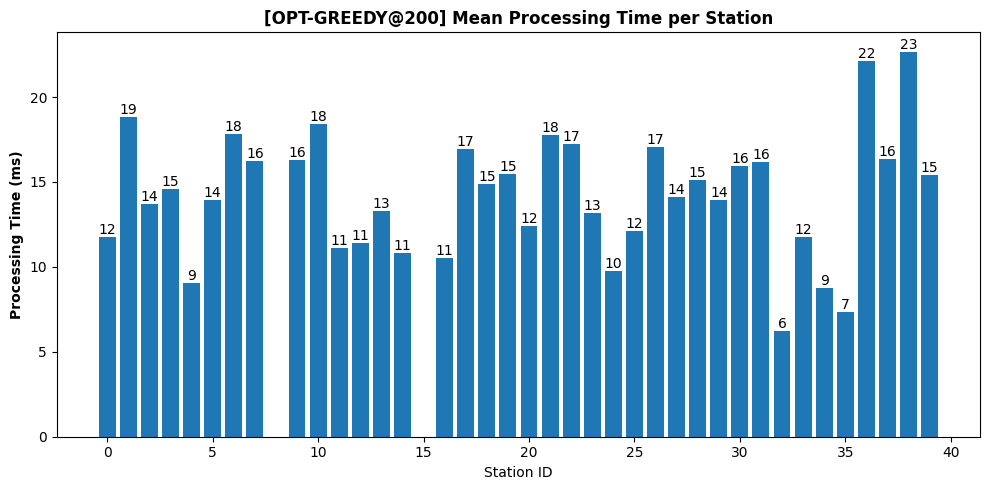

In [132]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [133]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           2  0.076389  0.010417  0.000000  0.000000  0.000000   
1            0           4  0.804167  0.713889  0.722917  0.815278       NaN   
2            0           5  0.104861  0.000000  0.000000  0.000000  0.000000   
3            0          15  0.000000  0.000000  0.000000  0.000000  0.000000   
4            0          19  0.222917  0.046528  0.000000  0.000000  0.000000   
5            0          26  0.247917  0.000000  0.000000  0.000000  0.000000   
6            0          36  0.036806  0.000000  0.000000  0.000000  0.000000   
7            1           0  0.534028  0.476389  0.095833  0.180556       NaN   
8            1           8  0.000000  0.000000  0.000000  0.000000  0.000000   
9            1           9  0.484722  0.345833  0.070139  0.000000  0.036111   
10           1          17  0.073611  0.000000  0.000000  0.000000  0.000000   
11           1          20  0.022917  0.

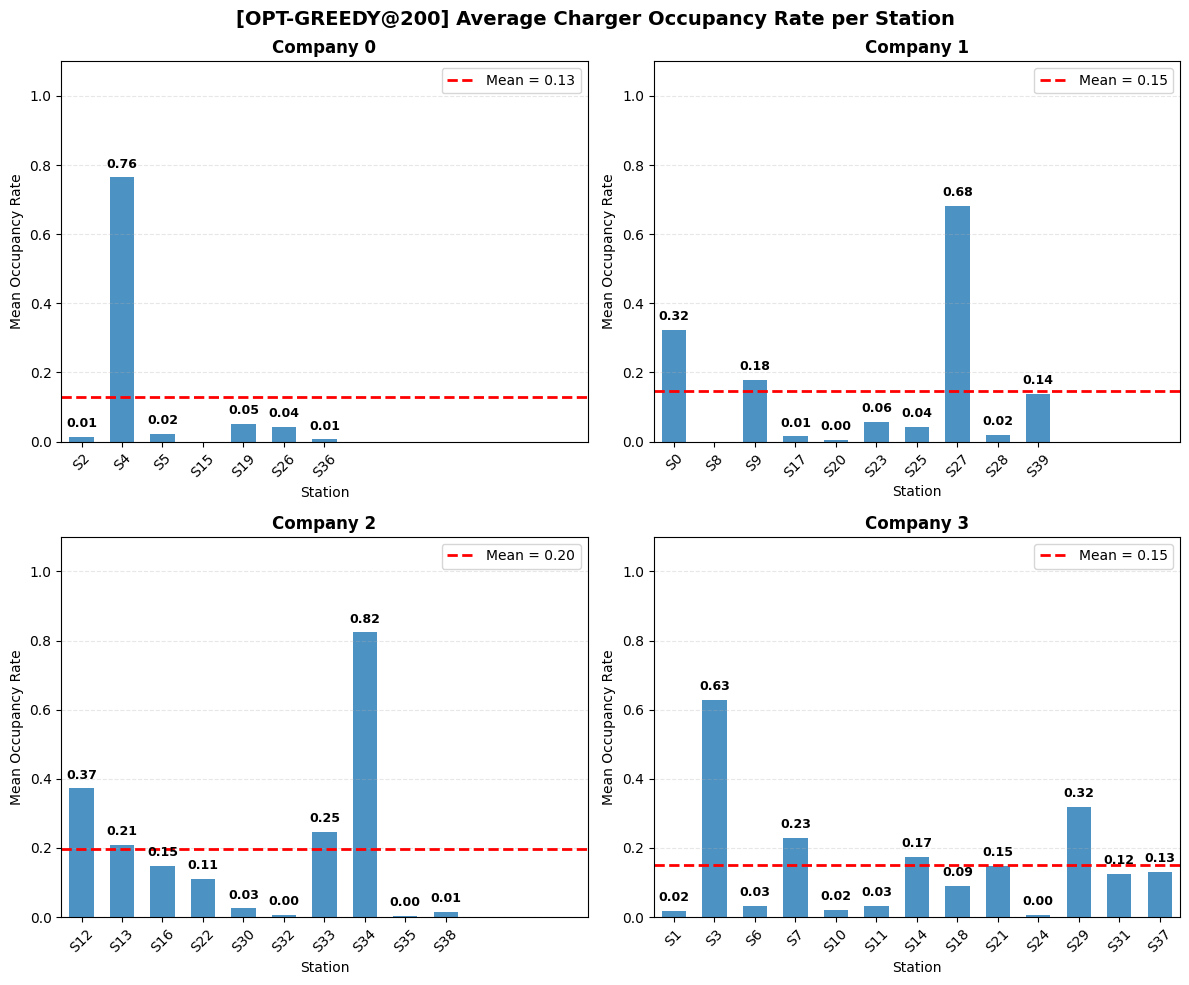

In [134]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

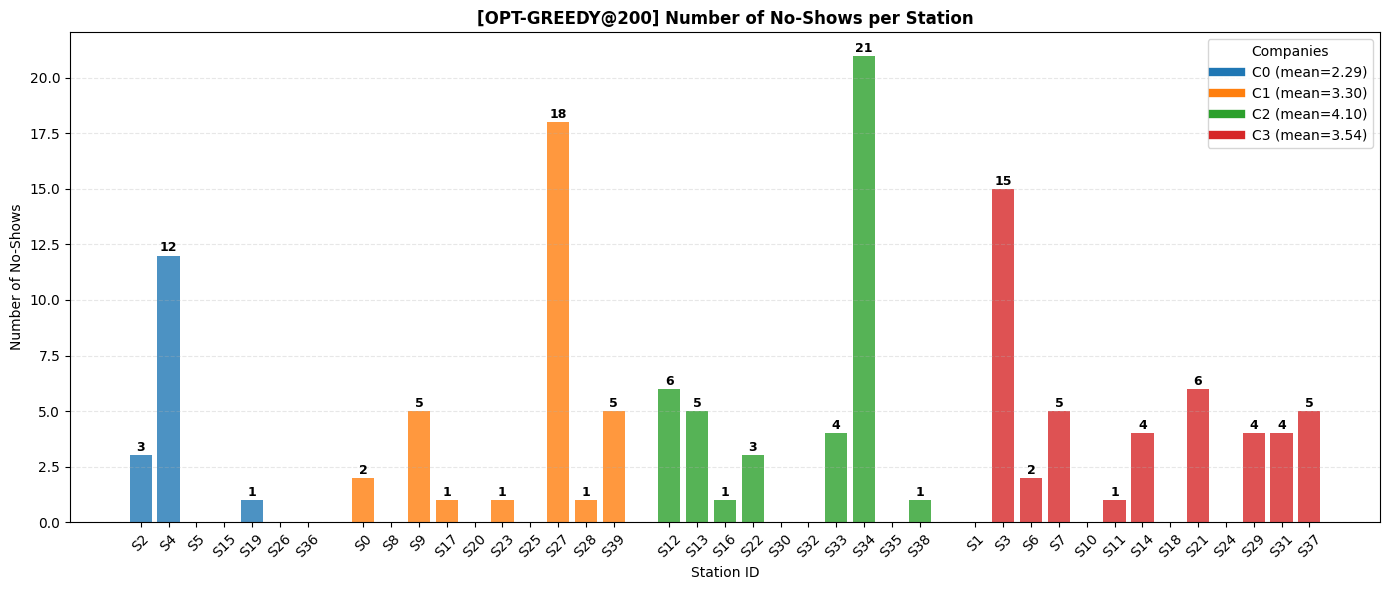

In [135]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [136]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,2,9,5,3,0,0,0.555556,0.333333,0.000000,0.000000
1,0,4,183,167,12,4,0,0.912568,0.065574,0.021858,0.000000
2,0,5,4,4,0,0,0,1.000000,0.000000,0.000000,0.000000
3,0,15,0,0,0,0,0,NaN,NaN,NaN,NaN
4,0,19,14,13,1,0,0,0.928571,0.071429,0.000000,0.000000
5,0,26,8,8,0,0,0,1.000000,0.000000,0.000000,0.000000
6,0,36,1,1,0,0,0,1.000000,0.000000,0.000000,0.000000
7,1,0,55,53,2,0,0,0.963636,0.036364,0.000000,0.000000
8,1,8,0,0,0,0,0,NaN,NaN,NaN,NaN
9,1,9,49,44,5,0,0,0.897959,0.102041,0.000000,0.000000


#### **BRAM-EV**

##### *Params*

In [137]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [138]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [139]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:26:24.050 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 23:26:25.205 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 23:26:27.204 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 23:26:28.453 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 23:26:29.886 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 23:26:30.426 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 23:26:31.731 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 23:26:33.140 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 23:26:35.593 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 23:26:36.230 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 23:26:36.869 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [140]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 63.22 kWh
  Station 1: 41.08 kWh
  Station 2: 12.79 kWh
  Station 3: 97.84 kWh
  Station 4: 6.24 kWh
  Station 5: 36.54 kWh
  Station 6: 58.06 kWh
  Station 7: 56.14 kWh
  Station 8: 6.56 kWh
  Station 9: 3.77 kWh
  Station 10: 12.73 kWh
  Station 11: 15.93 kWh
  Station 12: 82.47 kWh
  Station 13: 7.30 kWh
  Station 14: 129.38 kWh
  Station 15: 253.80 kWh
  Station 16: 3.21 kWh
  Station 17: 96.30 kWh
  Station 18: 45.96 kWh
  Station 19: 272.44 kWh
  Station 20: 7.16 kWh
  Station 21: 51.16 kWh
  Station 22: 19.19 kWh
  Station 23: 16.16 kWh
  Station 24: 191.31 kWh
  Station 25: 30.23 kWh
  Station 26: 4.98 kWh
  Station 27: 1.27 kWh
  Station 28: 26.44 kWh
  Station 29: 66.77 kWh
  Station 30: 23.58 kWh
  Station 31: 9.97 kWh
  Station 32: 75.10 kWh
  Station 33: 90.79 kWh
  Station 34: 6.39 kWh
  Station 35: 5.85 kWh
  Station 36: 8.20 kWh
  Station 37: 9.69 kWh
  Station 38: 240.34 kWh
  Station 39: 7.24 

In [141]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

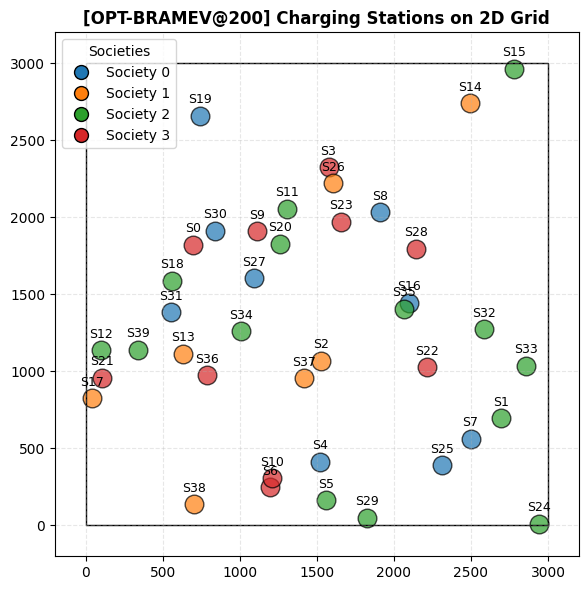

In [142]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

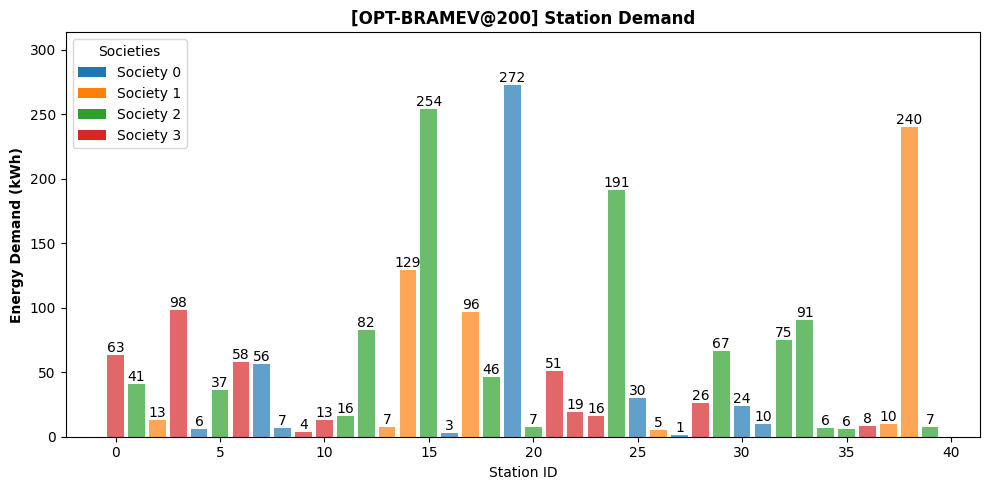

In [143]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

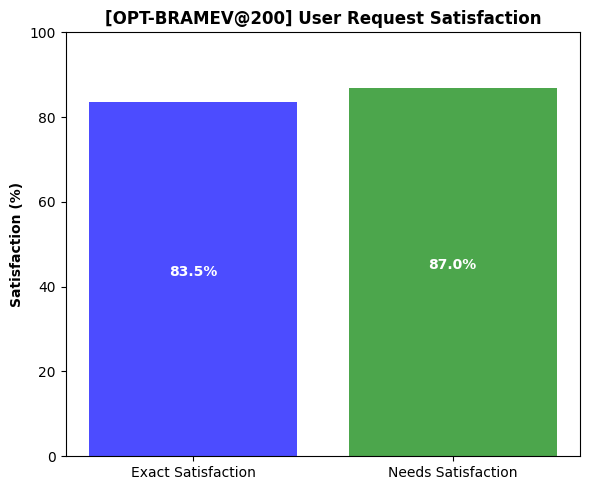

In [144]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

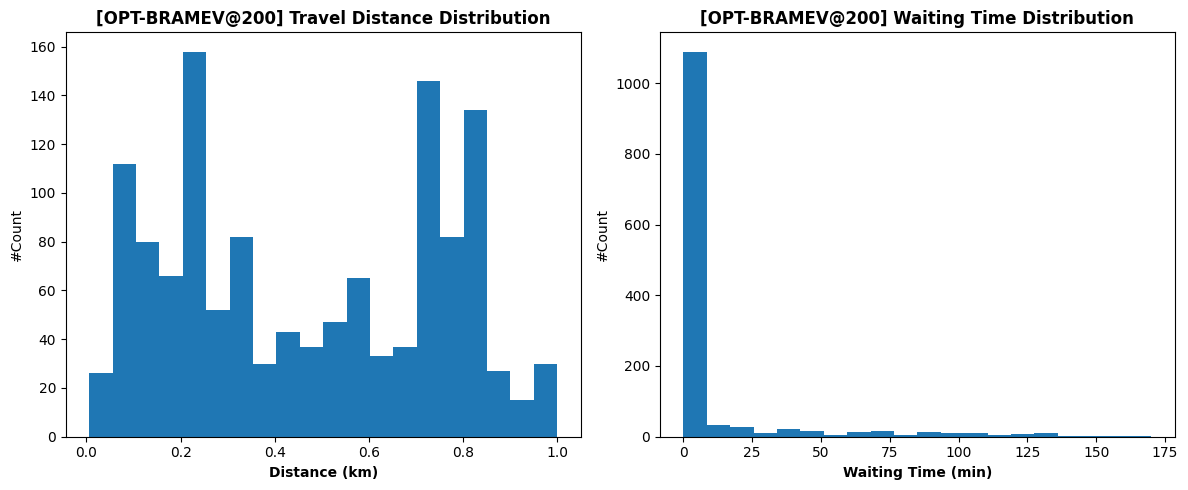

In [145]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

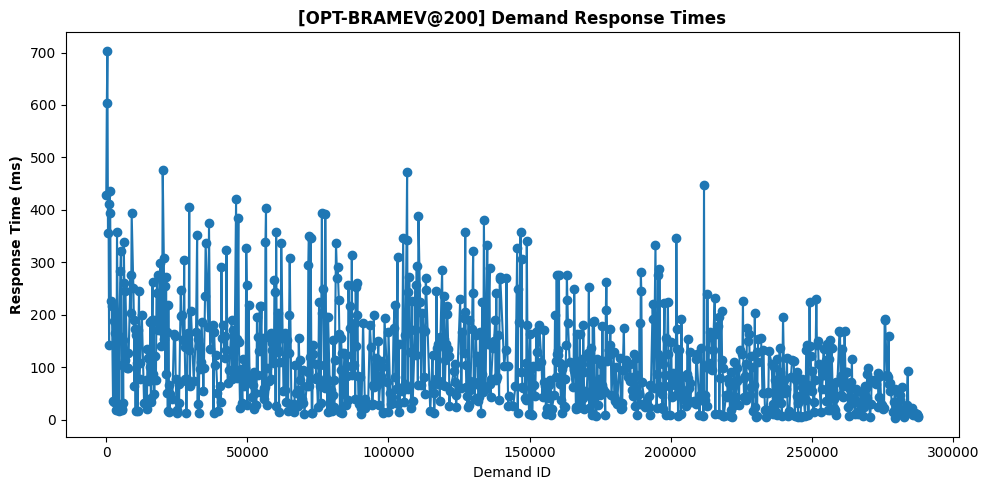

In [146]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

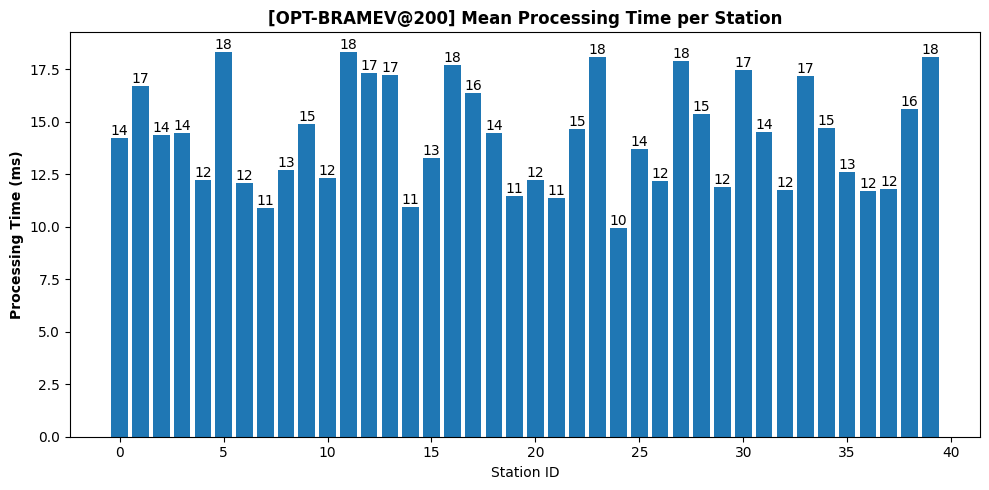

In [147]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

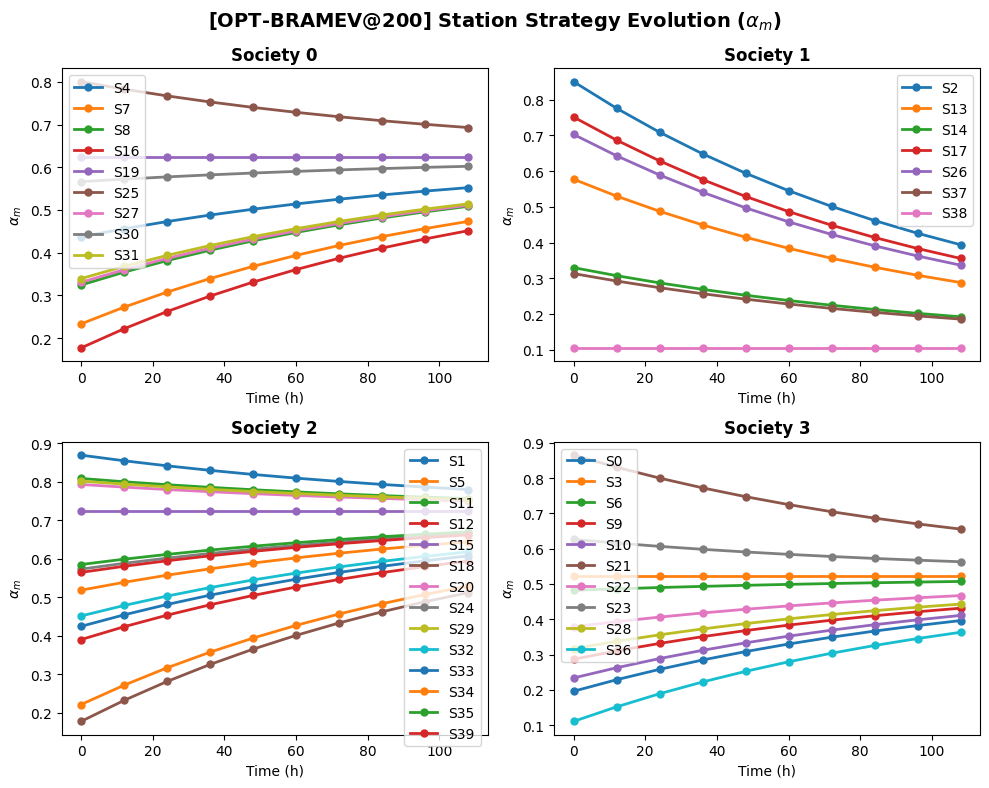

In [148]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [149]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           4  0.082639  0.000000  0.000000  0.000000       NaN   
1            0           7  0.372222  0.205556  0.095833  0.148611       NaN   
2            0           8  0.065278  0.013194  0.000000  0.000000       NaN   
3            0          16  0.053472  0.000000  0.000000  0.000000  0.000000   
4            0          19  0.850000  0.767361  0.806250  0.752083  0.764583   
5            0          25  0.315972  0.147917  0.000000  0.000000  0.000000   
6            0          27  0.013194  0.000000  0.000000  0.000000  0.000000   
7            0          30  0.250000  0.116667  0.000000  0.000000  0.000000   
8            0          31  0.160417  0.000000  0.000000  0.000000  0.000000   
9            1           2  0.135417  0.026389  0.000000  0.000000  0.000000   
10           1          13  0.112500  0.000000  0.000000  0.000000  0.000000   
11           1          14  0.670833  0.

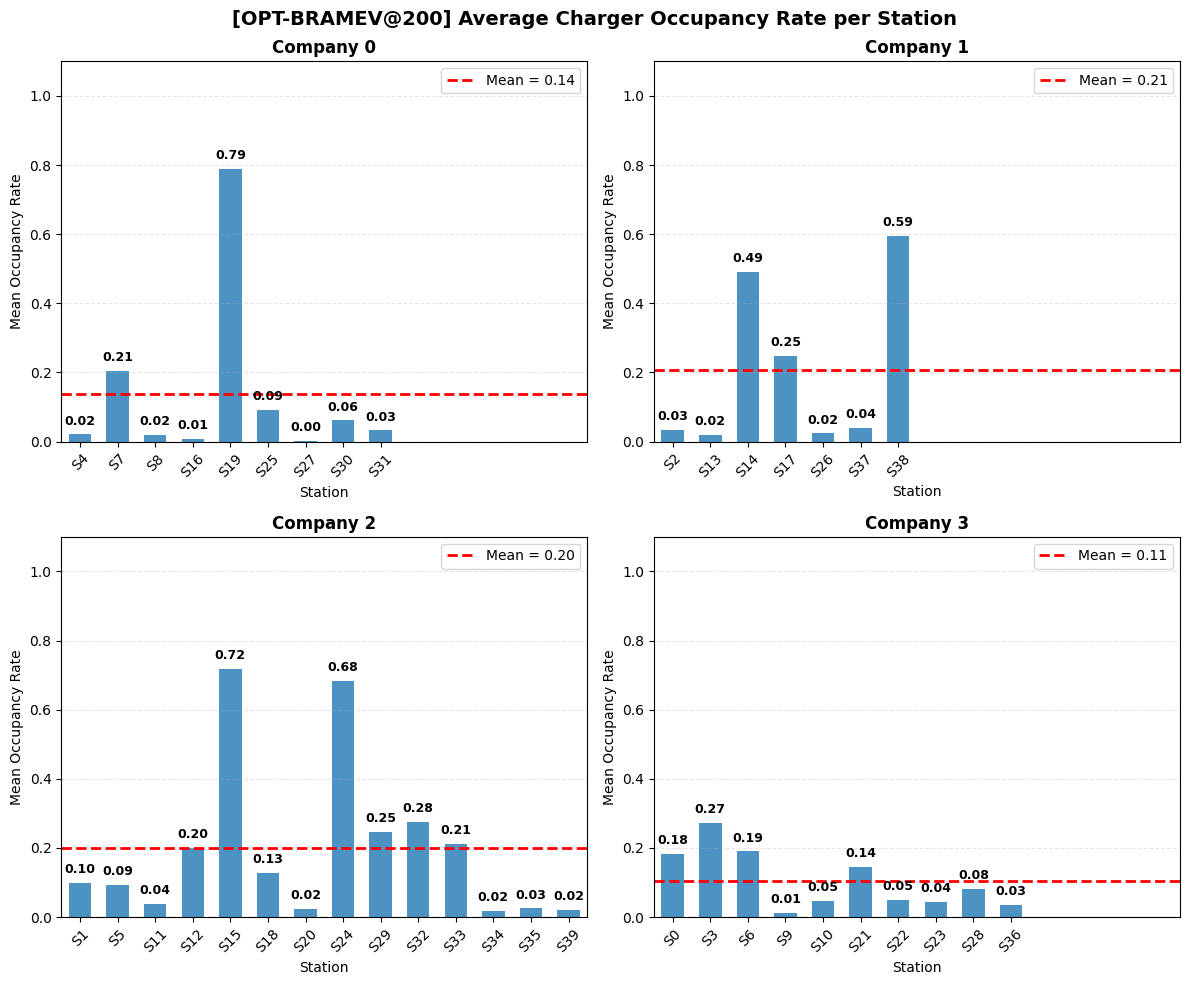

In [150]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

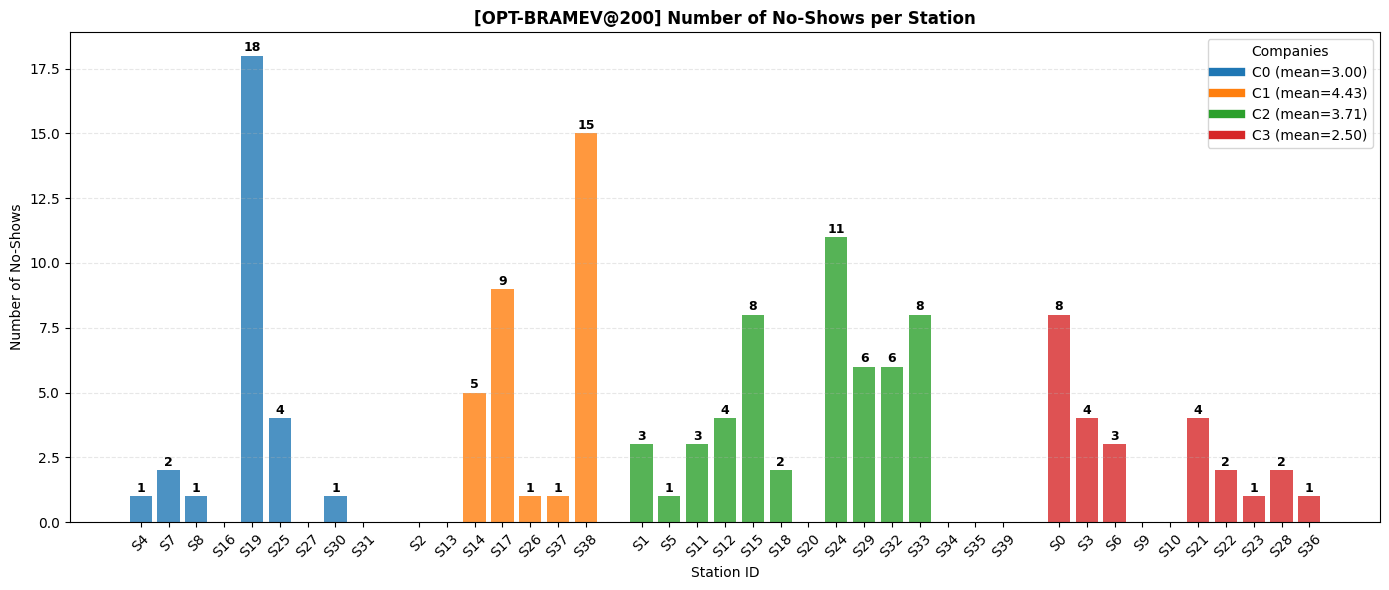

In [151]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [152]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,4,4,3,1,0,0,0.750000,0.250000,0.000000,0.000000
1,0,7,36,33,2,0,0,0.916667,0.055556,0.000000,0.000000
2,0,8,5,4,1,0,0,0.800000,0.200000,0.000000,0.000000
3,0,16,2,2,0,0,0,1.000000,0.000000,0.000000,0.000000
4,0,19,214,191,18,2,1,0.892523,0.084112,0.009346,0.004673
5,0,25,22,18,4,0,0,0.818182,0.181818,0.000000,0.000000
6,0,27,1,1,0,0,0,1.000000,0.000000,0.000000,0.000000
7,0,30,14,13,1,0,0,0.928571,0.071429,0.000000,0.000000
8,0,31,7,7,0,0,0,1.000000,0.000000,0.000000,0.000000
9,1,2,8,8,0,0,0,1.000000,0.000000,0.000000,0.000000


#### **COMPARISON**

##### *Params*

In [153]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

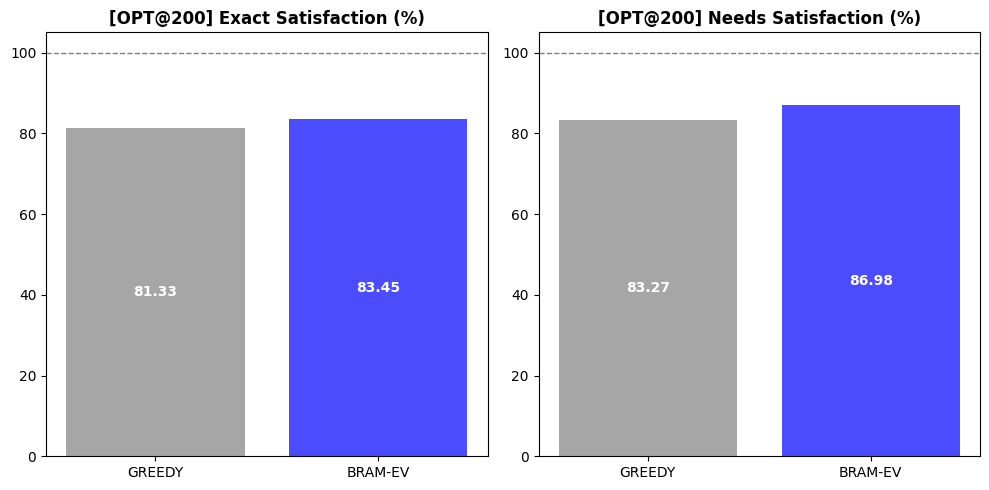

In [154]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

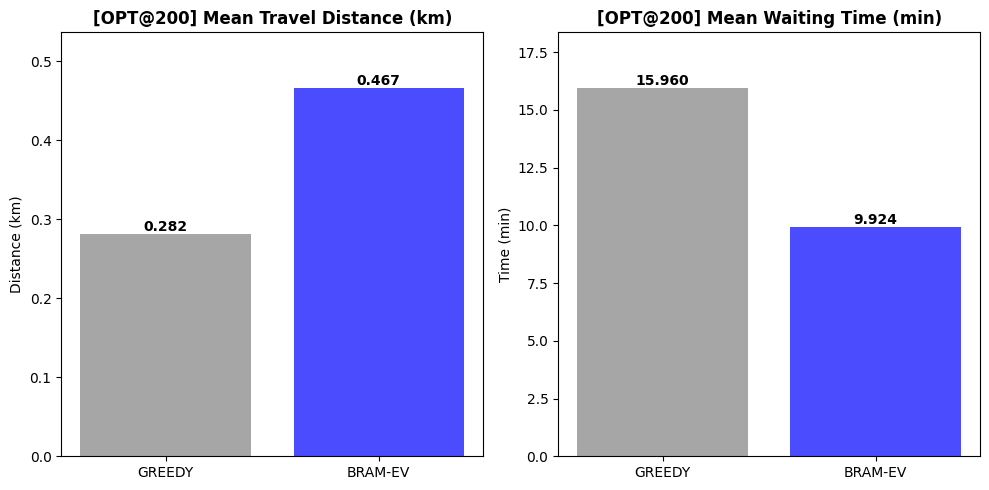

In [155]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

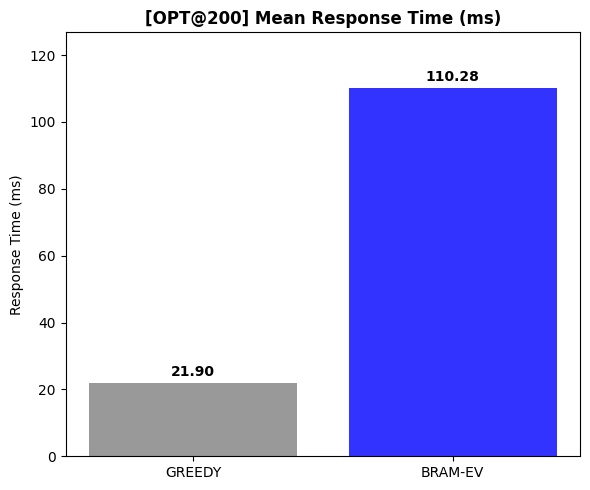

In [156]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@250cars**

#### **CONFIG**

In [157]:
nb_car = 250
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [ ]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/250cars


##### *Initialisation*

In [159]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [160]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:28:09.706 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-13 23:28:10.143 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-13 23:28:10.496 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-13 23:28:10.948 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-13 23:28:11.345 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-13 23:28:11.662 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-13 23:28:11.867 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-13 23:28:12.128 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-13 23:28:12.564 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-13 23:28:12.982 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-13 23:28:13.437 | IN

##### *Metrics*

In [161]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 93.12 kWh
  Station 1: 18.48 kWh
  Station 2: 221.97 kWh
  Station 3: 10.03 kWh
  Station 4: 8.82 kWh
  Station 5: 17.14 kWh
  Station 6: 12.97 kWh
  Station 7: 16.83 kWh
  Station 8: 129.57 kWh
  Station 9: 8.25 kWh
  Station 10: 9.80 kWh
  Station 11: 19.86 kWh
  Station 12: 11.18 kWh
  Station 13: 63.80 kWh
  Station 14: 16.72 kWh
  Station 15: 56.12 kWh
  Station 16: 9.41 kWh
  Station 17: 173.46 kWh
  Station 18: 18.28 kWh
  Station 19: 2.08 kWh
  Station 20: 85.21 kWh
  Station 21: 13.71 kWh
  Station 22: 128.91 kWh
  Station 23: 21.57 kWh
  Station 24: 19.95 kWh
  Station 25: 134.64 kWh
  Station 26: 3.97 kWh
  Station 27: 249.74 kWh
  Station 28: 32.35 kWh
  Station 29: 280.95 kWh
  Station 30: 11.50 kWh
  Station 31: 3.58 kWh
  Station 32: 92.12 kWh
  Station 33: 16.68 kWh
  Station 34: 64.83 kWh
  Station 35: 98.31 kWh
  Station 36: 34.87 kWh
  Station 37: 110.38 kWh
  Station 38: 14.75 kWh
  Station 

In [162]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

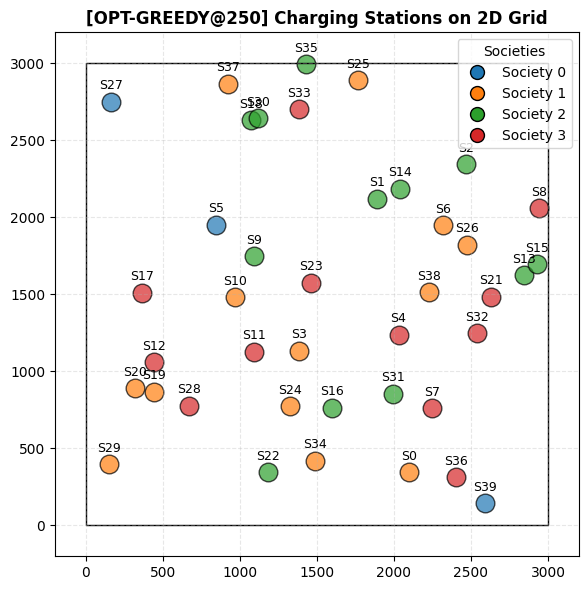

In [163]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

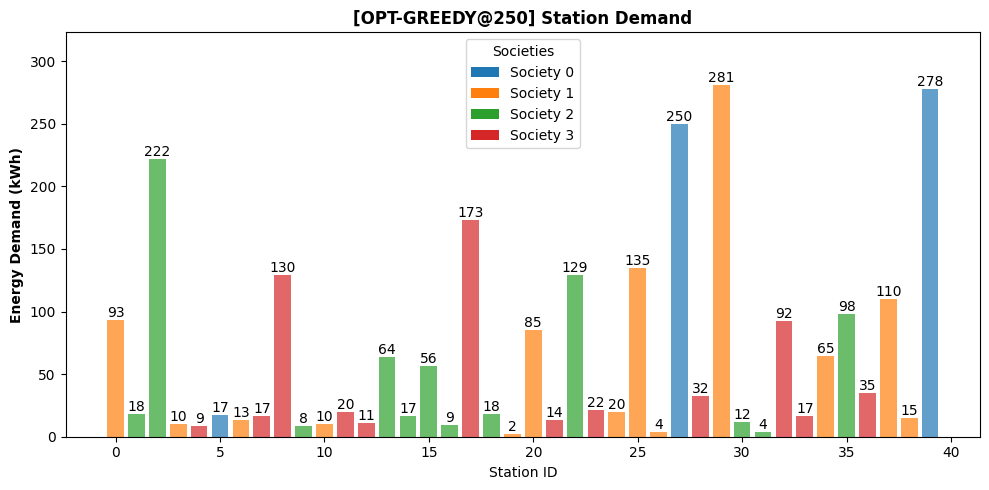

In [164]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

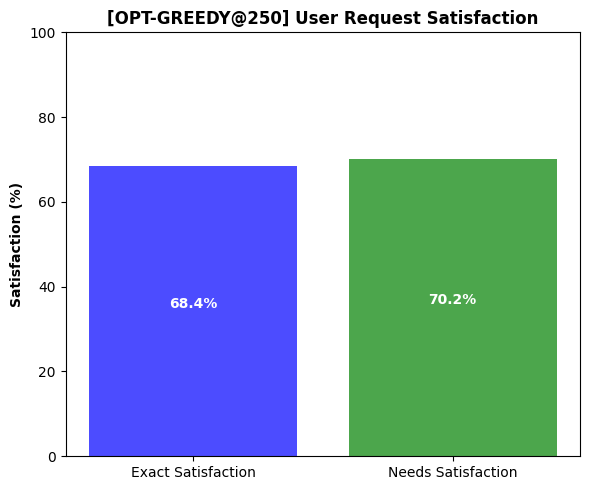

In [165]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

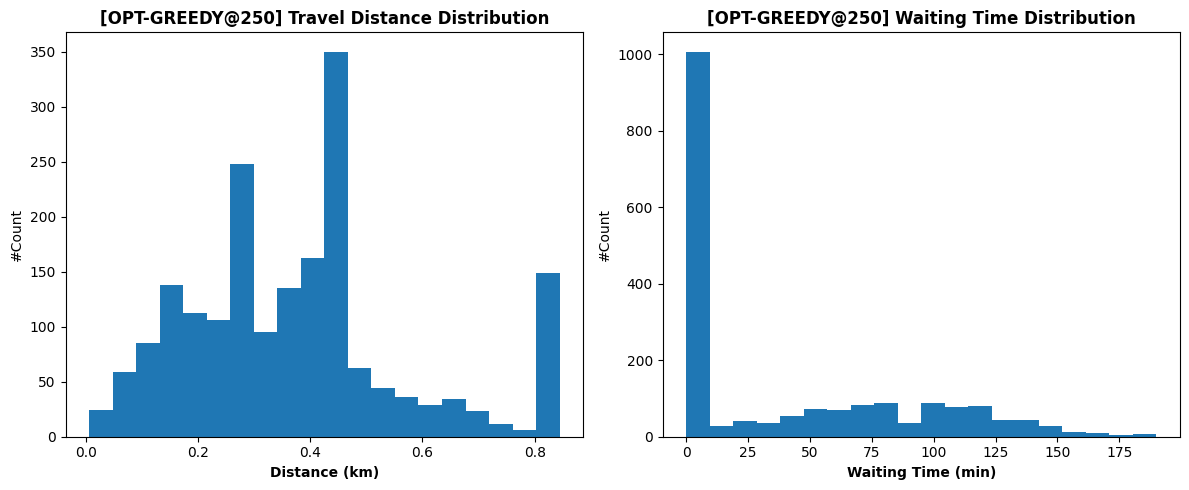

In [166]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

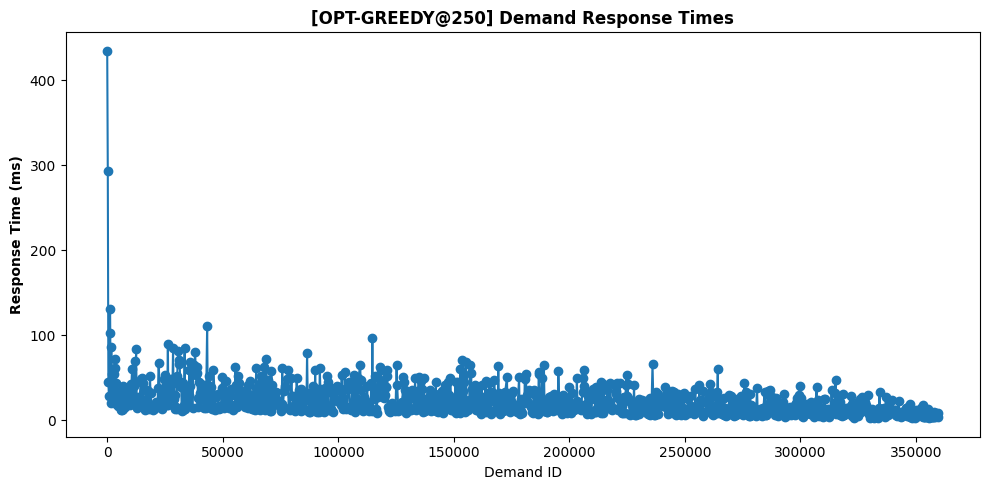

In [167]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

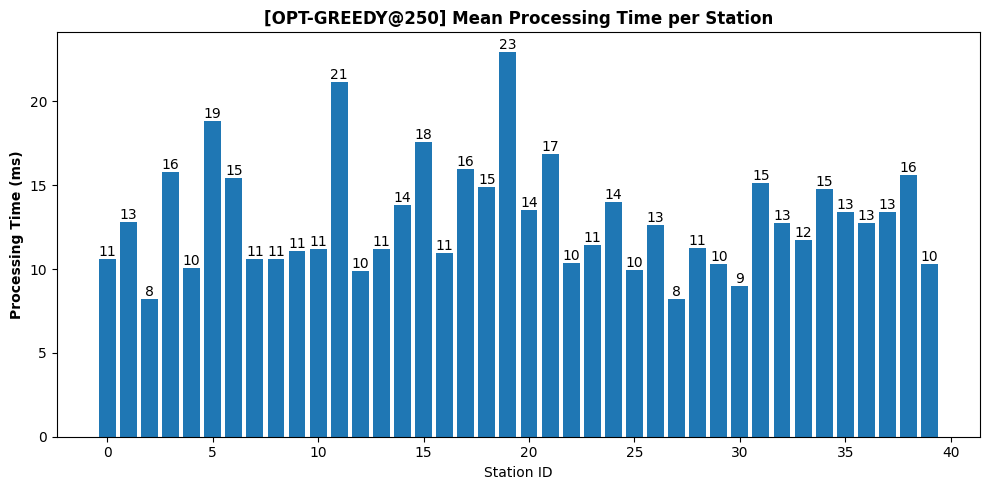

In [168]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [169]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           5  0.219444  0.054167  0.000000  0.000000  0.000000   
1            0          27  0.894444  0.938194  0.828472  0.903472       NaN   
2            0          39  0.841667  0.851389  0.837500  0.884722  0.768750   
3            1           0  0.565972  0.438889  0.180556  0.155556       NaN   
4            1           3  0.147222  0.000000  0.000000  0.000000  0.000000   
5            1           6  0.190972  0.043750  0.000000  0.000000  0.000000   
6            1          10  0.119444  0.016667  0.000000  0.000000       NaN   
7            1          19  0.034722  0.000000  0.000000  0.000000  0.000000   
8            1          20  0.634722  0.306250  0.061806  0.098611  0.147917   
9            1          24  0.213889  0.055556  0.000000  0.000000  0.000000   
10           1          25  0.700000  0.486806  0.315278  0.391667       NaN   
11           1          26  0.047917  0.

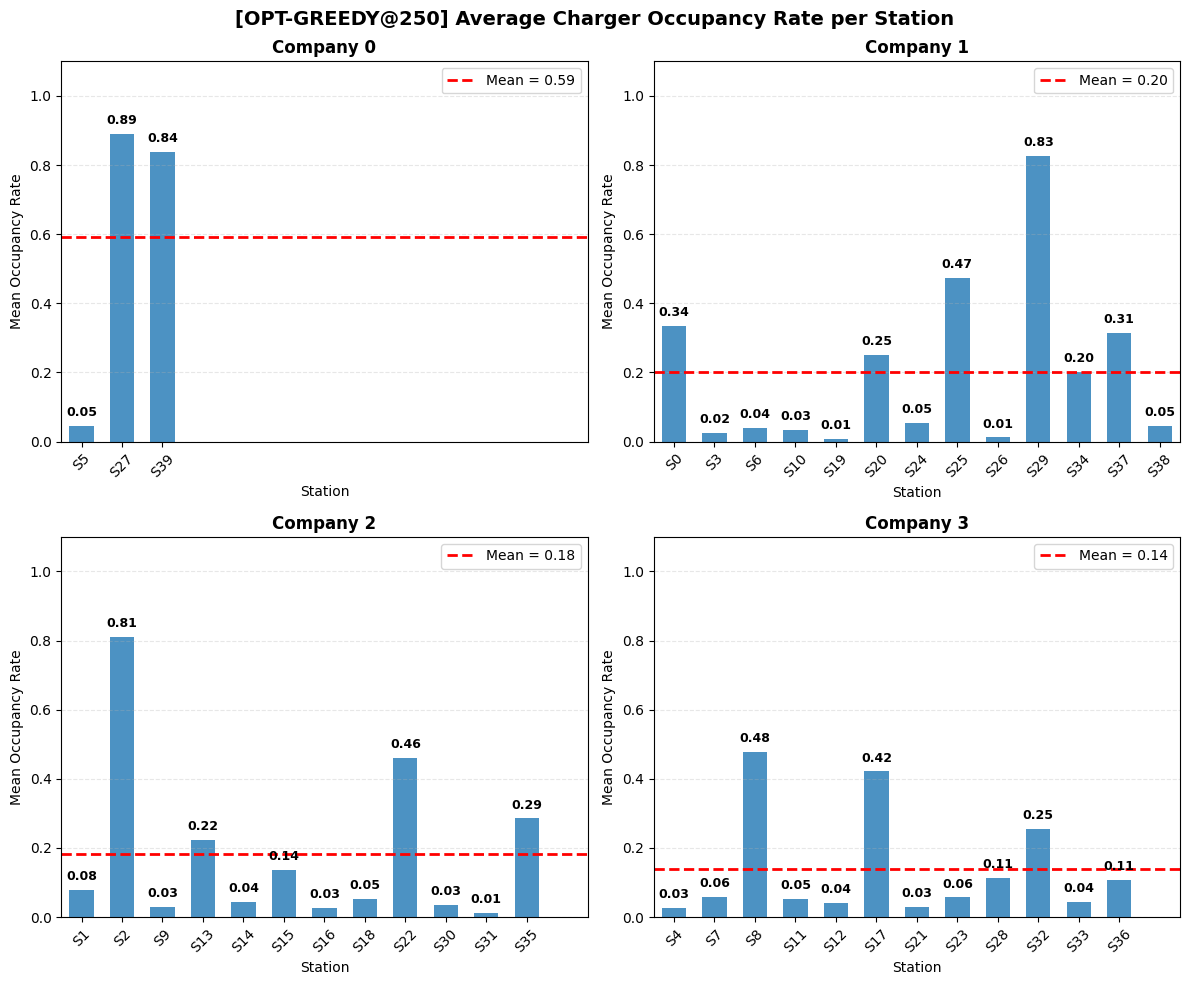

In [170]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

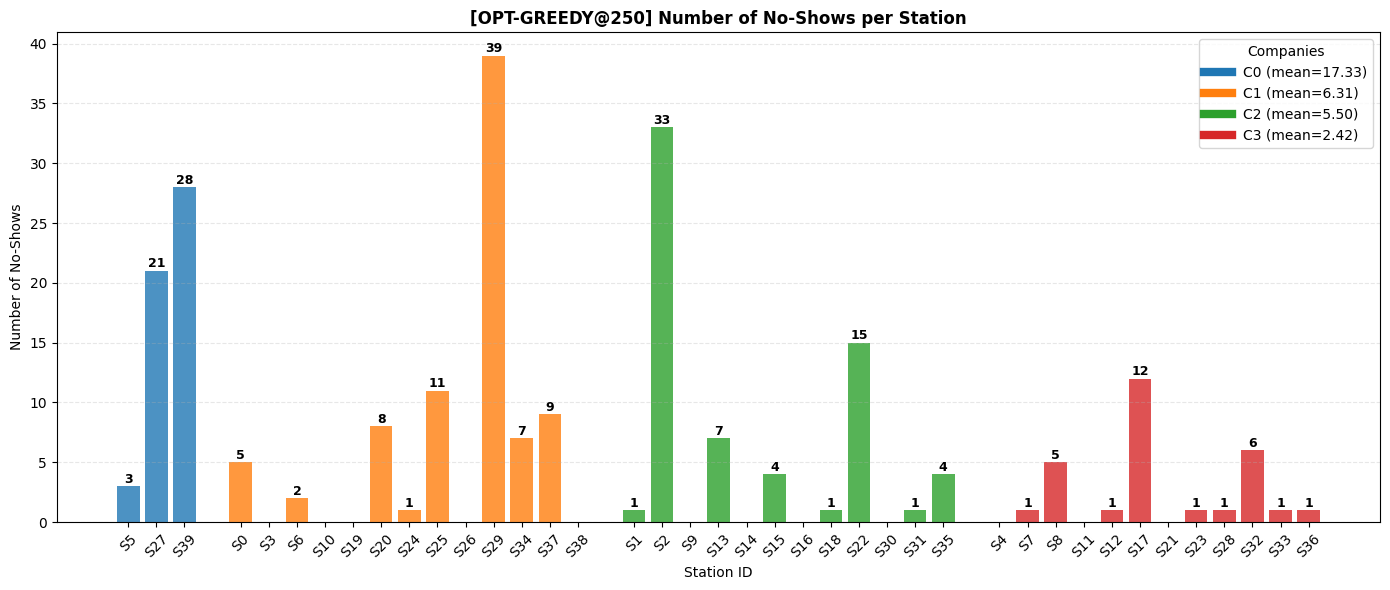

In [171]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [172]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,5,13,10,3,0,0,0.769231,0.230769,0.000000,0.000000
1,0,27,268,234,21,7,5,0.873134,0.078358,0.026119,0.018657
2,0,39,282,243,28,7,3,0.861702,0.099291,0.024823,0.010638
3,1,0,62,57,5,0,0,0.919355,0.080645,0.000000,0.000000
4,1,3,6,6,0,0,0,1.000000,0.000000,0.000000,0.000000
5,1,6,10,8,2,0,0,0.800000,0.200000,0.000000,0.000000
6,1,10,6,6,0,0,0,1.000000,0.000000,0.000000,0.000000
7,1,19,1,1,0,0,0,1.000000,0.000000,0.000000,0.000000
8,1,20,60,52,8,0,0,0.866667,0.133333,0.000000,0.000000
9,1,24,12,11,1,0,0,0.916667,0.083333,0.000000,0.000000


#### **BRAM-EV**

##### *Params*

In [173]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [174]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [175]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:28:49.772 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 23:28:57.252 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 23:28:59.971 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 23:29:01.390 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 23:29:03.270 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 23:29:05.336 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 23:29:07.131 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 23:29:09.260 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 23:29:12.660 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 23:29:14.998 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 23:29:16.389 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [176]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 232.00 kWh
  Station 1: 10.99 kWh
  Station 2: 246.72 kWh
  Station 3: 271.90 kWh
  Station 4: 73.11 kWh
  Station 5: 96.40 kWh
  Station 6: 45.08 kWh
  Station 7: 108.41 kWh
  Station 8: 77.64 kWh
  Station 9: 4.55 kWh
  Station 10: 96.74 kWh
  Station 11: 70.03 kWh
  Station 12: 83.39 kWh
  Station 13: 57.03 kWh
  Station 14: 83.72 kWh
  Station 15: 18.71 kWh
  Station 16: 82.58 kWh
  Station 17: 245.88 kWh
  Station 18: 79.10 kWh
  Station 19: 1.93 kWh
  Station 20: 116.02 kWh
  Station 21: 140.64 kWh
  Station 22: 30.78 kWh
  Station 23: 3.88 kWh
  Station 24: 16.13 kWh
  Station 25: 18.93 kWh
  Station 26: 13.83 kWh
  Station 27: 27.76 kWh
  Station 28: 88.46 kWh
  Station 29: 13.10 kWh
  Station 30: 21.32 kWh
  Station 31: 42.47 kWh
  Station 32: 15.38 kWh
  Station 33: 13.72 kWh
  Station 34: 21.38 kWh
  Station 35: 22.12 kWh
  Station 36: 35.62 kWh
  Station 37: 70.62 kWh
  Station 38: 21.75 kWh
  Stati

In [177]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

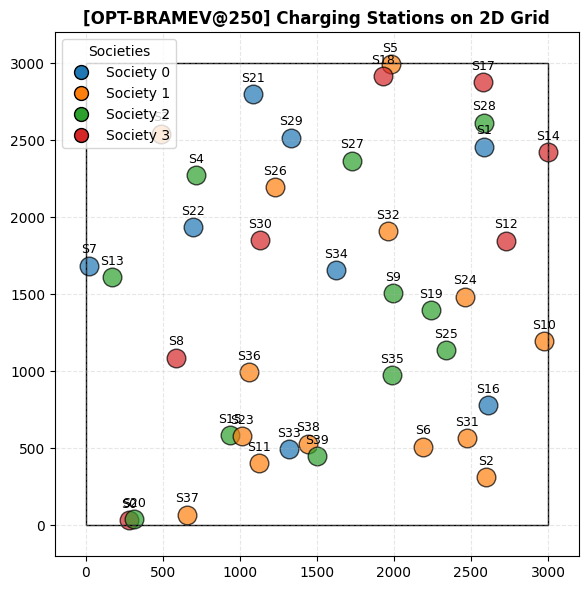

In [178]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

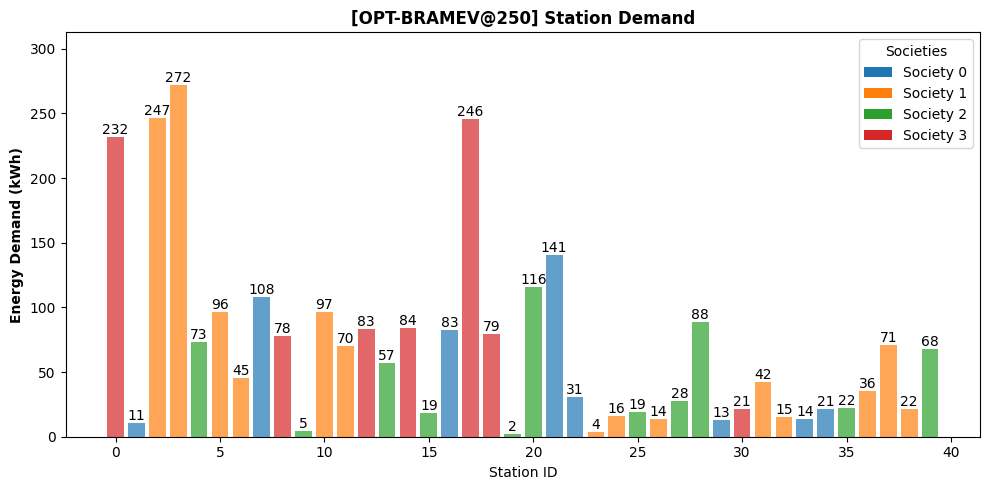

In [179]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

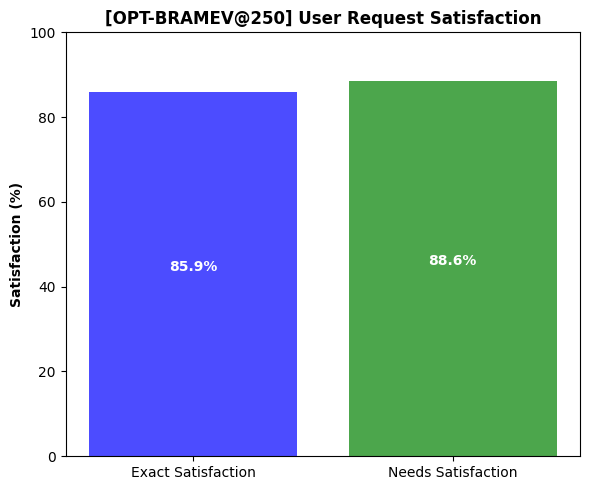

In [180]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

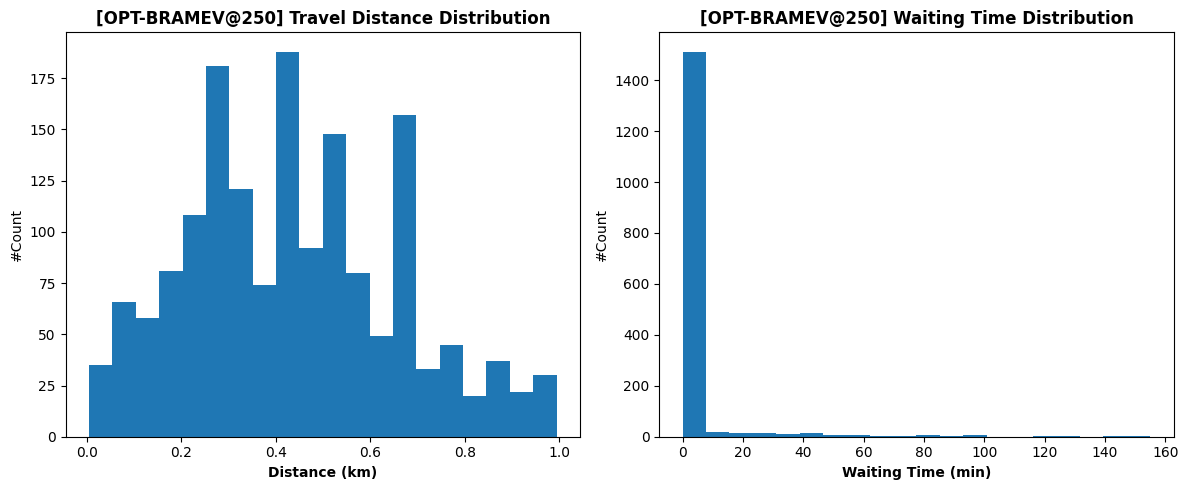

In [181]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

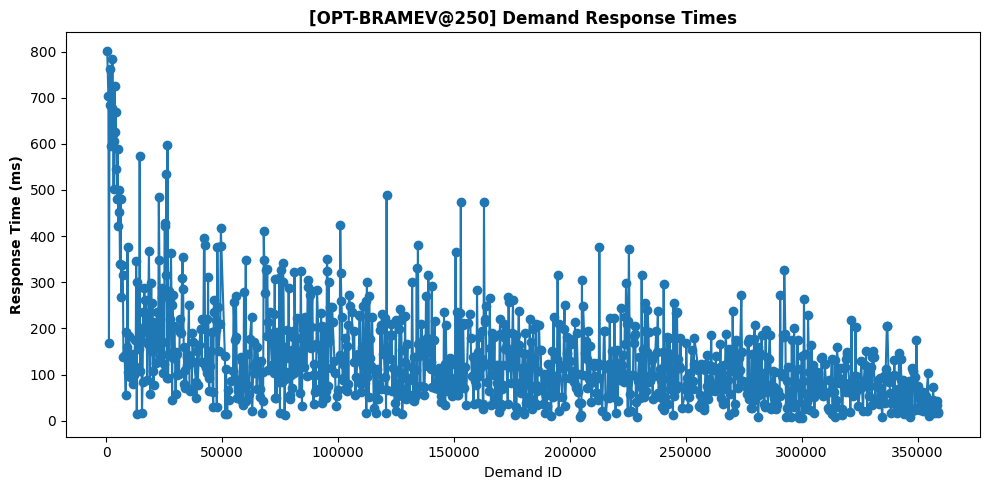

In [182]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

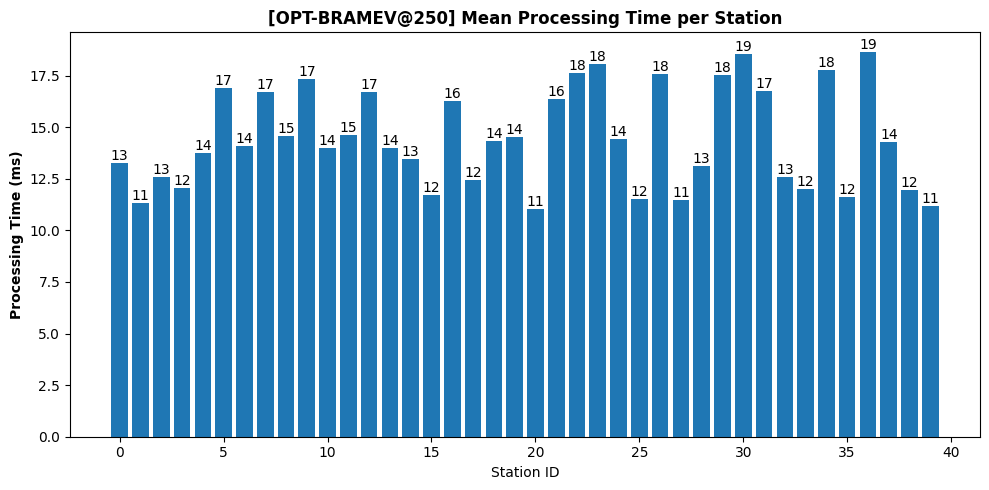

In [183]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

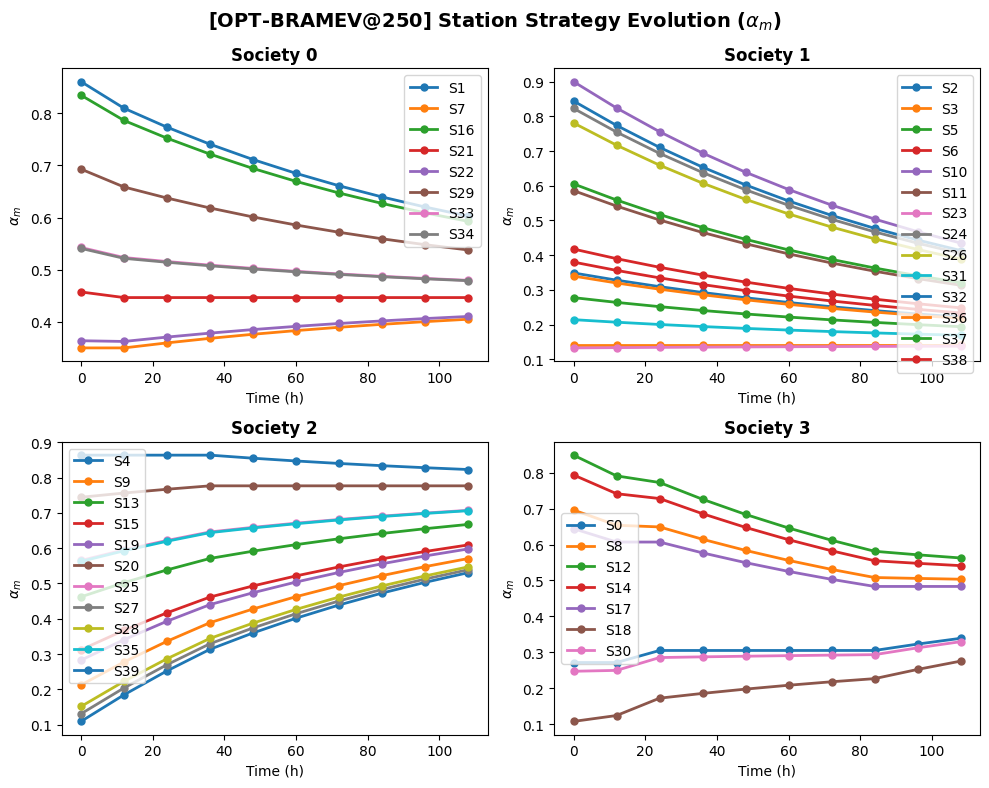

In [184]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [185]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.118750  0.036111  0.000000  0.000000       NaN   
1            0           7  0.611806  0.425000  0.129861  0.029167  0.089583   
2            0          16  0.608333  0.303472  0.074306  0.000000  0.046528   
3            0          21  0.706944  0.508333  0.274306  0.079167  0.138889   
4            0          22  0.276389  0.146528  0.000000  0.000000  0.000000   
5            0          29  0.155556  0.043750  0.000000  0.000000  0.000000   
6            0          33  0.158333  0.040278  0.000000  0.000000       NaN   
7            0          34  0.244444  0.071528  0.000000  0.000000  0.000000   
8            1           2  0.784028  0.766667  0.663889  0.608333  0.618056   
9            1           3  0.879167  0.765972  0.708333  0.770833  0.618750   
10           1           5  0.589583  0.428472  0.157639  0.046528  0.037500   
11           1           6  0.326389  0.

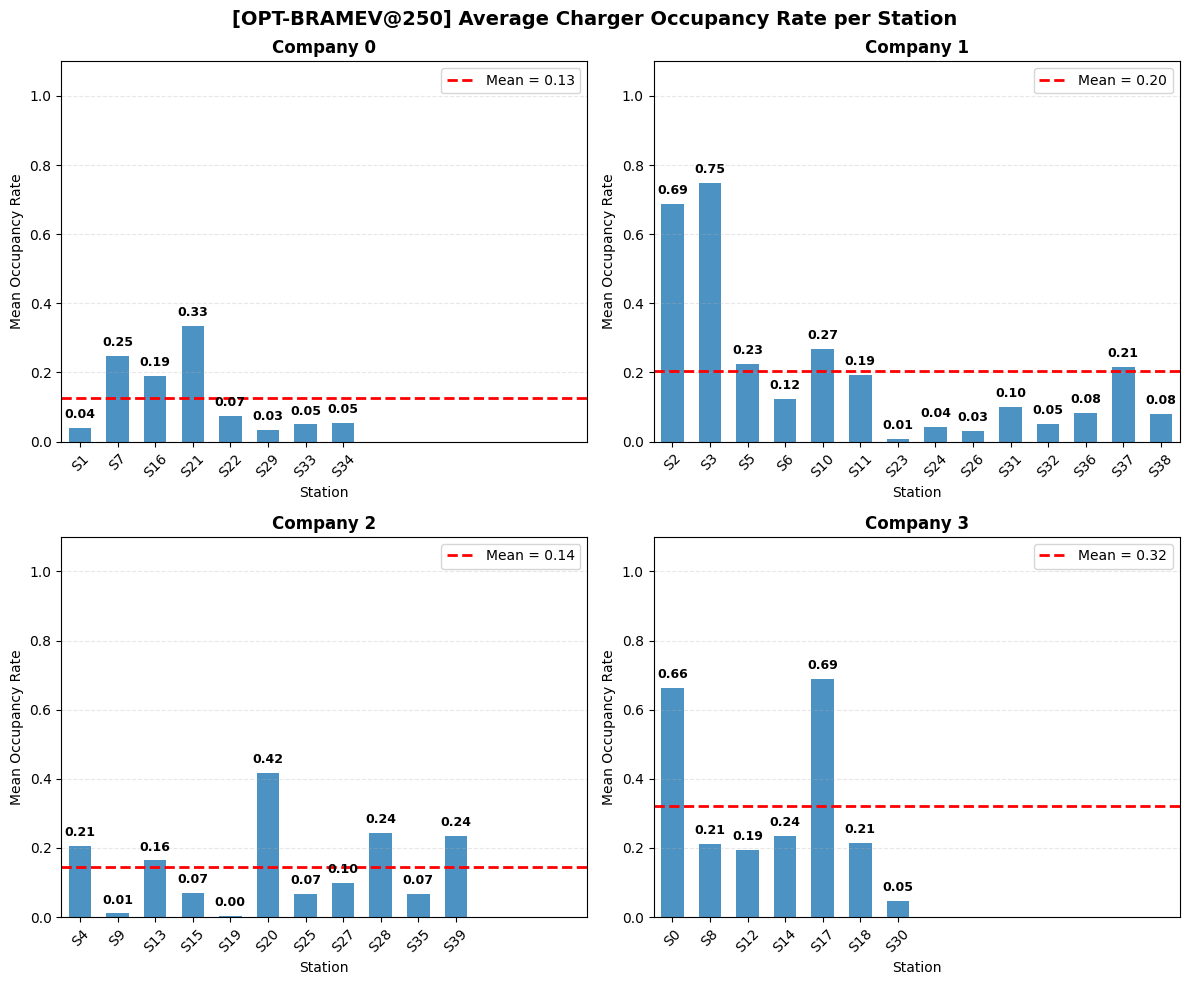

In [186]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

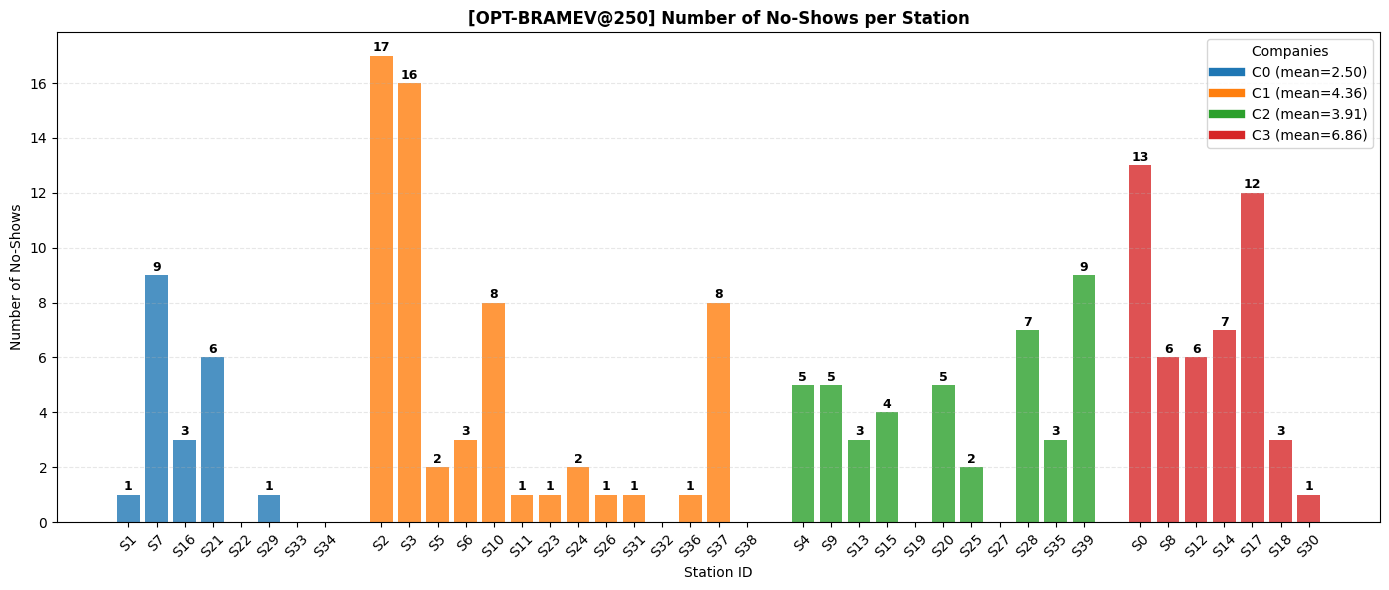

In [187]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [188]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,7,6,1,0,0,0.857143,0.142857,0.000000,0.000000
1,0,7,73,63,9,0,0,0.863014,0.123288,0.000000,0.000000
2,0,16,51,48,3,0,0,0.941176,0.058824,0.000000,0.000000
3,0,21,89,83,6,0,0,0.932584,0.067416,0.000000,0.000000
4,0,22,17,17,0,0,0,1.000000,0.000000,0.000000,0.000000
5,0,29,9,8,1,0,0,0.888889,0.111111,0.000000,0.000000
6,0,33,9,8,0,0,0,0.888889,0.000000,0.000000,0.000000
7,0,34,11,11,0,0,0,1.000000,0.000000,0.000000,0.000000
8,1,2,161,144,17,0,0,0.894410,0.105590,0.000000,0.000000
9,1,3,183,165,16,1,1,0.901639,0.087432,0.005464,0.005464


#### **COMPARISON**

##### *Params*

In [189]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

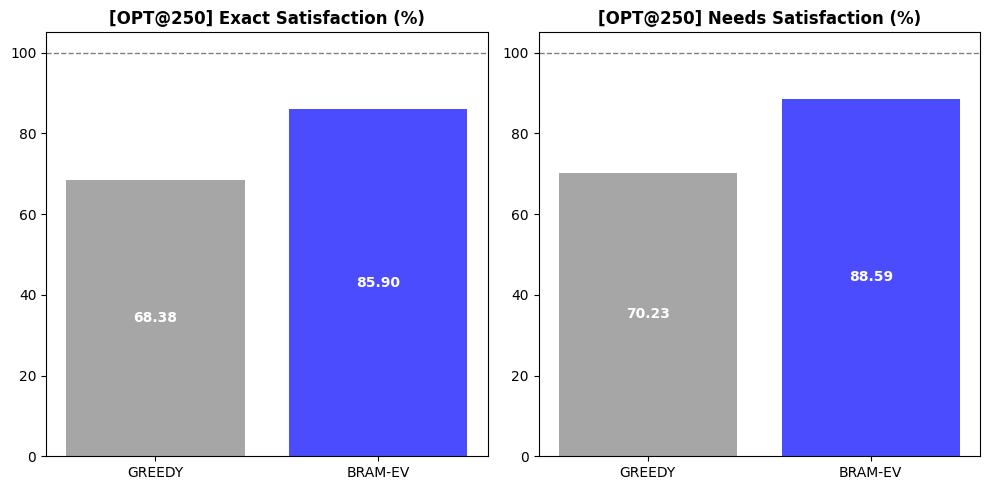

In [190]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

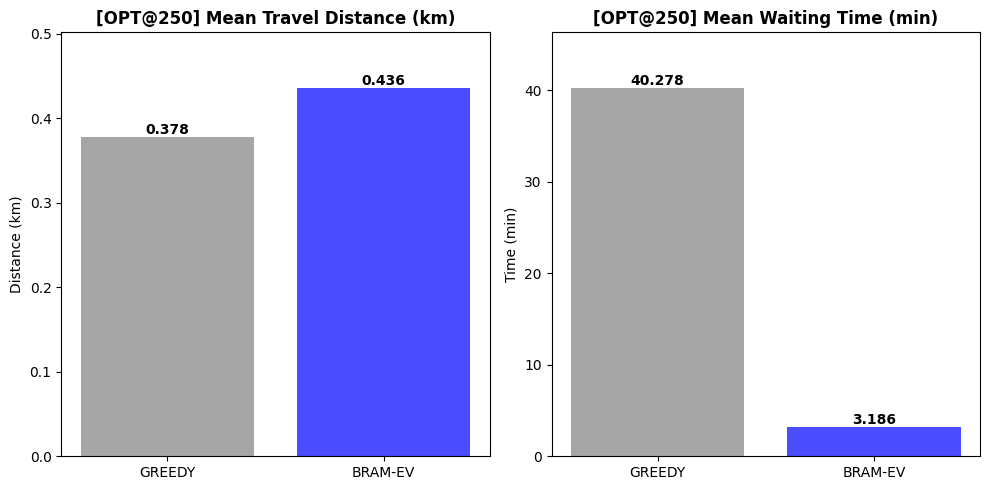

In [191]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

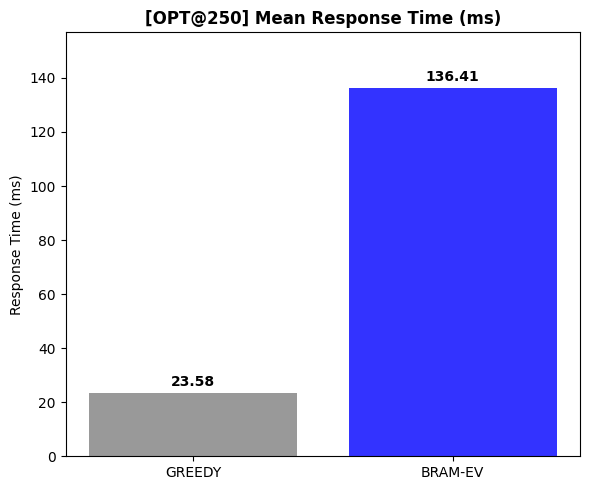

In [192]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

## **COMPARISON**

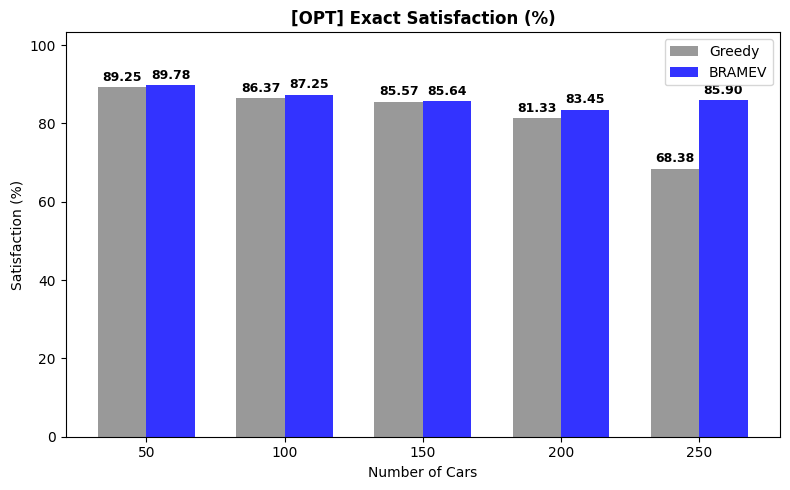

In [193]:
plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

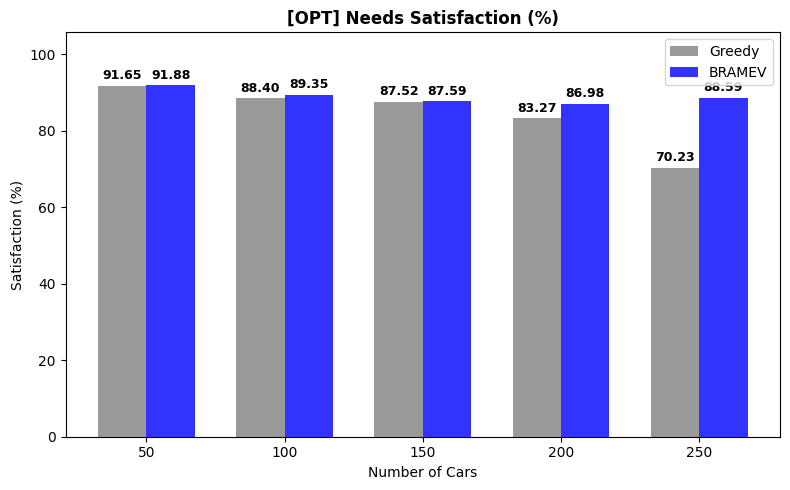

In [194]:
plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

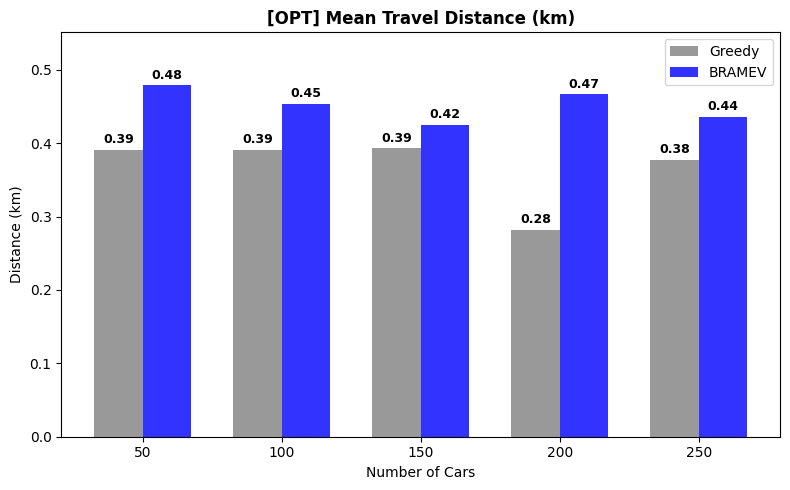

In [195]:
plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


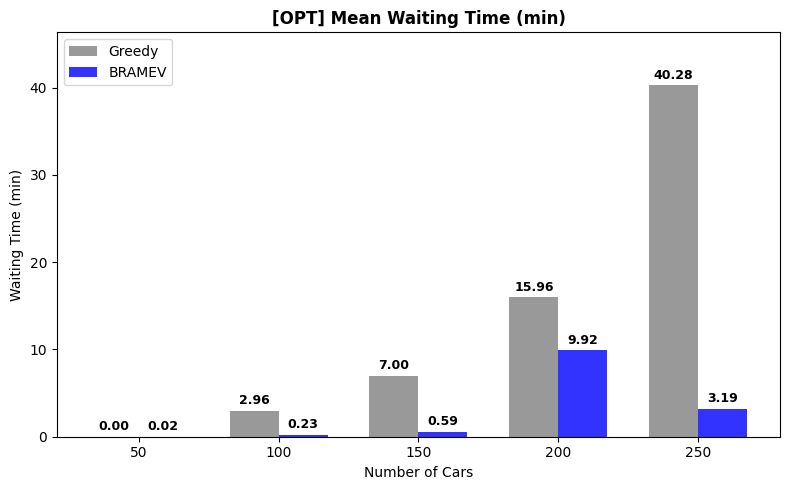

In [196]:
plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


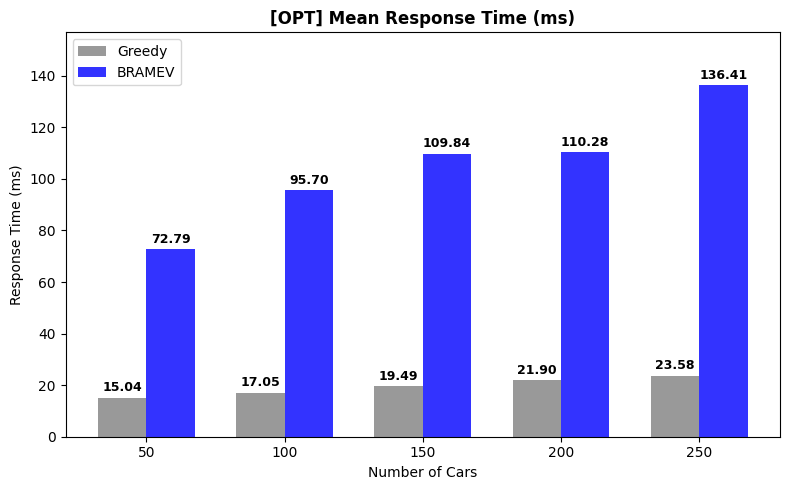

In [197]:
plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)
